# Mean Reversion amb Pairs Trading

Exemple pràctic d'una estratègia de **pairs trading** basada en mean reversion.

Construirem dos actius relacionats, estimarem dinàmicament la seva relació i farem un backtest long/short amb costos i control de risc.

## 1. Preparació

Llibreries utilitzades per simulació, tractament de dades i visualització.

In [79]:
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Simulació del mercat

Simularem dos actius relacionats mitjançant:

\[
\log(A_t) = \alpha + \beta_t \log(B_t) + S_t
\]

on:

- \(\beta_t\) pot canviar amb el temps;
- \(S_t\) és un spread que normalment fa mean reversion;
- la relació pot patir períodes de ruptura;
- l'equilibri del spread també pot canviar.

Aquestes variables són conegudes pel simulador, però **no per l'algoritme de trading**, que només observarà els preus.

In [81]:
# ==========================================
# PARÀMETRES GENERALS
# ==========================================

seed = 42
rng = np.random.default_rng(seed)

n_passos = 15_000


# ==========================================
# FACTOR COMÚ DE MERCAT
# ==========================================

mu_mercat = 0.0003
sigma_mercat = 0.01


# ==========================================
# SPREAD
# ==========================================

kappa_max = 0.08

sigma_spread_min = 0.015
sigma_spread_max = 0.025


# ==========================================
# CANVIS D'EQUILIBRI
# ==========================================

prob_canvi_equilibri = 0.002
sigma_canvi_equilibri = 0.05


# ==========================================
# DETERIORAMENT DE LA RELACIÓ
# ==========================================

persistencia_deteriorament = 0.97
sigma_deteriorament = 0.01

prob_xoc_relacio = 0.003

xoc_relacio_min = 0.20
xoc_relacio_max = 0.60


# ==========================================
# BETA DINÀMIC
# ==========================================

beta_inicial = 1.0

sigma_canvi_beta = 0.0015

prob_salt_beta = 0.0015
sigma_salt_beta = 0.08

beta_min = 0.6
beta_max = 1.4

### 2.1. Deteriorament de la relació

Definim una variable \(D_t \in [0,1]\):

- \(D_t \approx 0\): relació estable.
- \(D_t \approx 1\): relació molt deteriorada.

Normalment el deteriorament tendeix a desaparèixer, però ocasionalment hi ha xocs que el fan augmentar.

In [82]:
# ==========================================
# DETERIORAMENT DE LA RELACIÓ
# ==========================================

deteriorament = np.zeros(n_passos)

for t in range(1, n_passos):

    # Evolució gradual
    deteriorament[t] = (
        persistencia_deteriorament * deteriorament[t - 1]
        + rng.normal(0, sigma_deteriorament)
    )

    # Xoc ocasional que deteriora la relació
    if rng.random() < prob_xoc_relacio:

        deteriorament[t] += rng.uniform(
            xoc_relacio_min,
            xoc_relacio_max
        )

    # El deteriorament sempre queda entre 0 i 1
    deteriorament[t] = np.clip(
        deteriorament[t],
        0,
        1
    )

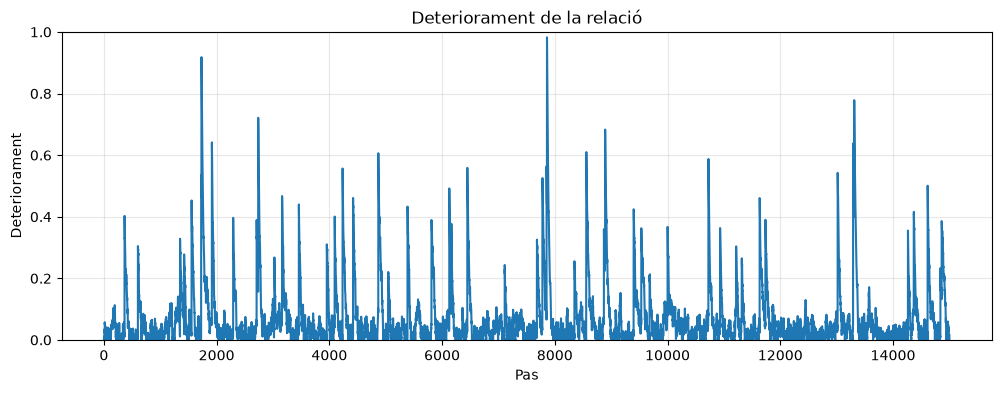

In [83]:
plt.figure(figsize=(12, 4))

plt.plot(deteriorament)

plt.title("Deteriorament de la relació")
plt.xlabel("Pas")
plt.ylabel("Deteriorament")

plt.ylim(0, 1)

plt.grid(alpha=0.3)

plt.show()

### 2.2. Mean reversion i volatilitat variables

El deteriorament de la relació modifica dues coses:

\[
\kappa_t = \kappa_{max}(1-D_t)
\]

\[
\sigma_t =
\sigma_{min}
+
D_t(\sigma_{max}-\sigma_{min})
\]

Quan la relació es deteriora:

- la mean reversion es debilita;
- el spread es torna més volàtil.

In [84]:
# ==========================================
# KAPPA I VOLATILITAT DINÀMICS
# ==========================================

kappa_dinamic = (
    kappa_max
    * (1 - deteriorament)
)

sigma_spread_dinamic = (
    sigma_spread_min
    + deteriorament
    * (
        sigma_spread_max
        - sigma_spread_min
    )
)

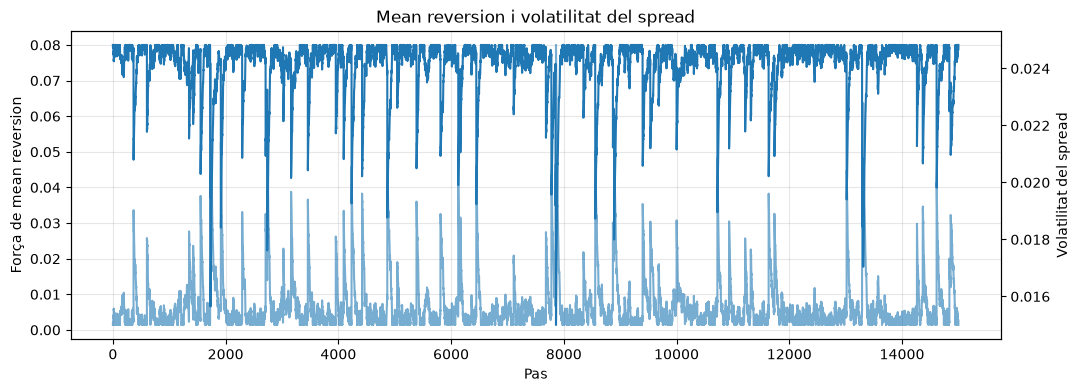

In [85]:
fig, ax1 = plt.subplots(
    figsize=(12, 4)
)

ax1.plot(
    kappa_dinamic,
    label="Kappa"
)

ax1.set_xlabel("Pas")
ax1.set_ylabel("Força de mean reversion")

ax2 = ax1.twinx()

ax2.plot(
    sigma_spread_dinamic,
    alpha=0.6,
    label="Sigma"
)

ax2.set_ylabel("Volatilitat del spread")

plt.title(
    "Mean reversion i volatilitat del spread"
)

ax1.grid(alpha=0.3)

plt.show()

### 2.3. Equilibri canviant del spread

El nivell d'equilibri del spread no ha de ser constant per sempre.

De tant en tant permetrem petits canvis estructurals en aquest nivell.

In [86]:
# ==========================================
# EQUILIBRI DINÀMIC DEL SPREAD
# ==========================================

equilibri_spread = np.zeros(n_passos)

equilibri_actual = 0.0

for t in range(1, n_passos):

    # Ocasionalment canvia el nivell d'equilibri
    if rng.random() < prob_canvi_equilibri:

        equilibri_actual += rng.normal(
            0,
            sigma_canvi_equilibri
        )

    equilibri_spread[t] = equilibri_actual

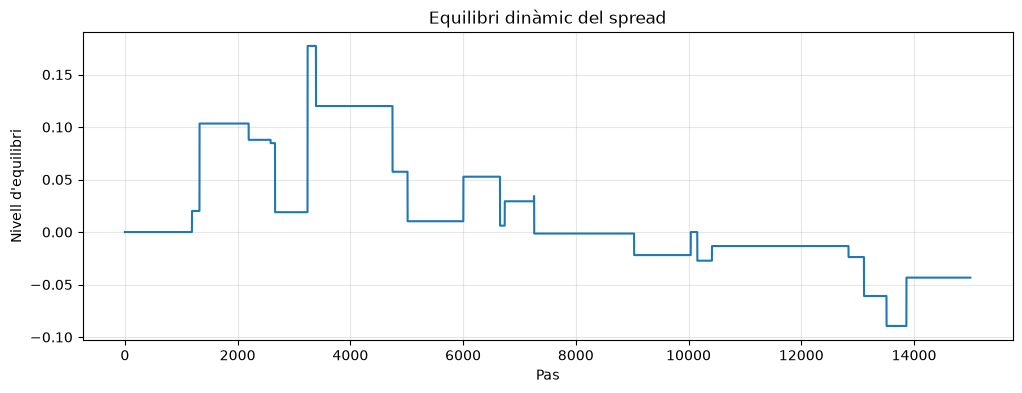

In [87]:
plt.figure(figsize=(12, 4))

plt.plot(equilibri_spread)

plt.title("Equilibri dinàmic del spread")
plt.xlabel("Pas")
plt.ylabel("Nivell d'equilibri")

plt.grid(alpha=0.3)

plt.show()

### 2.4. Spread real

El spread evoluciona al voltant d'un equilibri que pot canviar amb el temps:

$$
S_t = S_{t-1} + \kappa_t(\mu_t - S_{t-1}) + \varepsilon_t
$$

Quan la relació es deteriora, la mean reversion és més feble i el spread és més volàtil.

In [88]:
# ==========================================
# SPREAD REAL
# ==========================================

spread_real = np.zeros(n_passos)

spread_real[0] = equilibri_spread[0]

for t in range(1, n_passos):

    spread_real[t] = (
        spread_real[t - 1]
        + kappa_dinamic[t]
        * (
            equilibri_spread[t]
            - spread_real[t - 1]
        )
        + rng.normal(
            0,
            sigma_spread_dinamic[t]
        )
    )

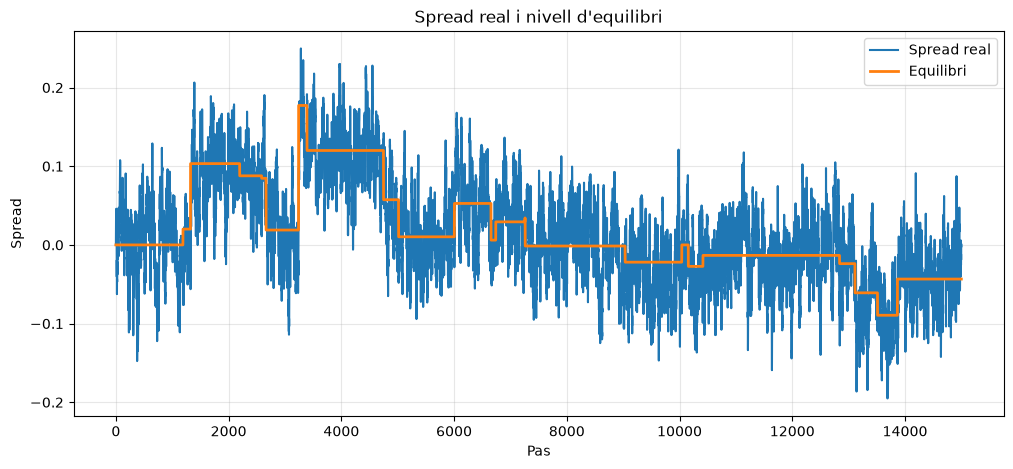

In [89]:
plt.figure(figsize=(12, 5))

plt.plot(
    spread_real,
    label="Spread real"
)

plt.plot(
    equilibri_spread,
    label="Equilibri",
    linewidth=2
)

plt.title("Spread real i nivell d'equilibri")
plt.xlabel("Pas")
plt.ylabel("Spread")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 2.5. Xocs ocasionals en el spread

A més del soroll habitual, permetem moviments extrems ocasionals.

Aquests xocs representen esdeveniments específics d'una empresa que poden separar temporalment els dos actius.

In [90]:
# ==========================================
# SPREAD REAL AMB XOCS OCASIONALS
# ==========================================

prob_salt_spread = 0.001
sigma_salt_spread = 0.08

spread_real = np.zeros(n_passos)
spread_real[0] = equilibri_spread[0]

salts_spread = np.zeros(n_passos)

for t in range(1, n_passos):

    # Soroll habitual
    soroll = rng.normal(
        0,
        sigma_spread_dinamic[t]
    )

    # Xoc excepcional
    salt = 0.0

    if rng.random() < prob_salt_spread:

        salt = rng.normal(
            0,
            sigma_salt_spread
        )

    salts_spread[t] = salt

    # Evolució del spread
    spread_real[t] = (
        spread_real[t - 1]
        + kappa_dinamic[t]
        * (
            equilibri_spread[t]
            - spread_real[t - 1]
        )
        + soroll
        + salt
    )

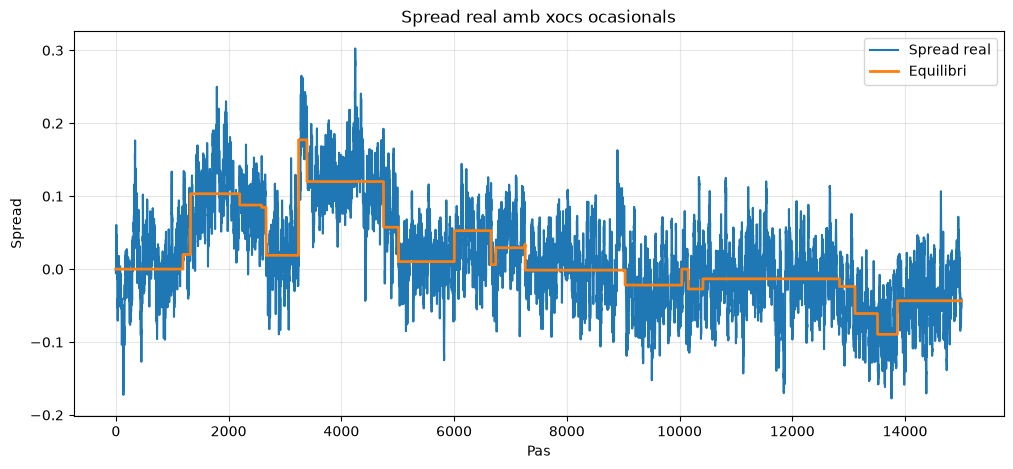

In [91]:
plt.figure(figsize=(12, 5))

plt.plot(
    spread_real,
    label="Spread real"
)

plt.plot(
    equilibri_spread,
    label="Equilibri",
    linewidth=2
)

plt.title("Spread real amb xocs ocasionals")
plt.xlabel("Pas")
plt.ylabel("Spread")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 2.6. Beta dinàmic

La relació entre els dos actius no és constant.

El beta evoluciona gradualment i, ocasionalment, pot patir canvis estructurals més forts.

$$
\log(A_t) = \alpha + \beta_t \log(B_t) + S_t
$$

El valor real de $\beta_t$ serà ocult per a l'algoritme.

In [92]:
# ==========================================
# BETA REAL DINÀMIC
# ==========================================

beta_real = np.zeros(n_passos)

beta_real[0] = beta_inicial

for t in range(1, n_passos):

    # Canvi gradual
    canvi_beta = rng.normal(
        0,
        sigma_canvi_beta
    )

    # Salt estructural ocasional
    if rng.random() < prob_salt_beta:

        canvi_beta += rng.normal(
            0,
            sigma_salt_beta
        )

    beta_real[t] = (
        beta_real[t - 1]
        + canvi_beta
    )

    # Evitem valors poc plausibles
    beta_real[t] = np.clip(
        beta_real[t],
        beta_min,
        beta_max
    )

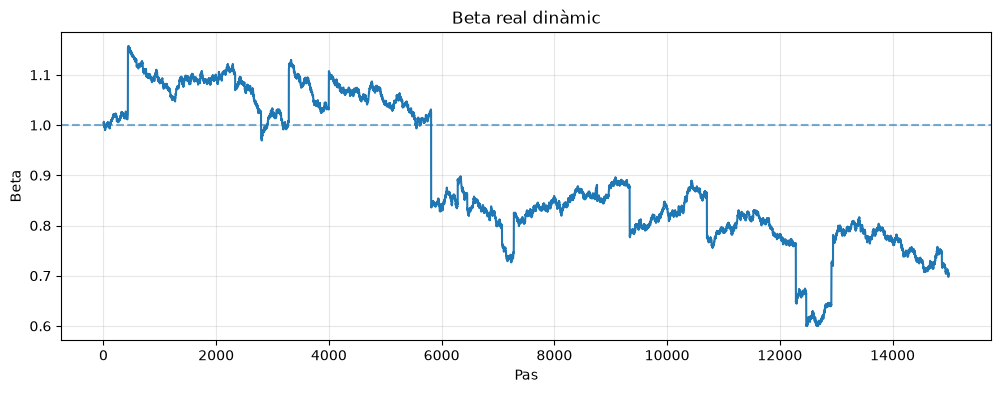

In [93]:
plt.figure(figsize=(12, 4))

plt.plot(beta_real)

plt.title("Beta real dinàmic")
plt.xlabel("Pas")
plt.ylabel("Beta")

plt.axhline(
    1,
    linestyle="--",
    alpha=0.6
)

plt.grid(alpha=0.3)

plt.show()

### 2.7. Factor comú i preus

Els dos actius comparteixen un moviment general de mercat.

Treballarem amb log-preus normalitzats:

$$
\log(B_t) = F_t
$$

$$
\log(A_t) = \beta_t \log(B_t) + S_t
$$

L'algoritme només observarà els preus finals d'A i B.

In [94]:
# ==========================================
# FACTOR COMÚ DE MERCAT
# ==========================================

retorns_mercat = rng.normal(
    mu_mercat,
    sigma_mercat,
    n_passos
)

factor_comu = np.cumsum(
    retorns_mercat
)


# ==========================================
# LOG-PREUS NORMALITZATS
# ==========================================

log_preu_B = factor_comu

log_preu_A = (
    beta_real * log_preu_B
    + spread_real
)


# ==========================================
# PREUS
# ==========================================

preu_B = (
    100
    * np.exp(log_preu_B)
)

preu_A = (
    100
    * np.exp(log_preu_A)
)


# ==========================================
# DATAFRAME
# ==========================================

dates = pd.bdate_range(
    start="2000-01-03",
    periods=n_passos
)

mercat = pd.DataFrame(
    {
        "Preu_A": preu_A,
        "Preu_B": preu_B,

        # Variables ocultes del simulador
        "Beta_Real": beta_real,
        "Spread_Real": spread_real,
        "Equilibri_Real": equilibri_spread,
        "Deteriorament": deteriorament
    },
    index=dates
)

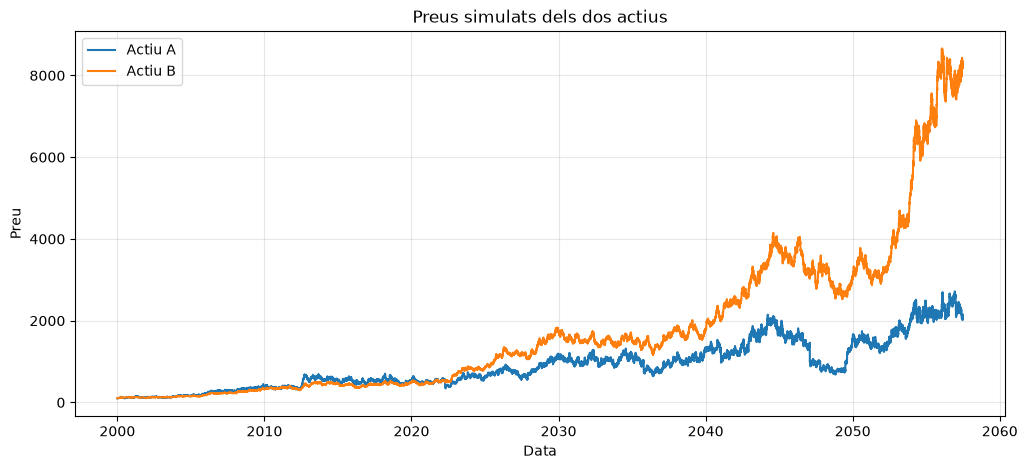

In [95]:
plt.figure(figsize=(12, 5))

plt.plot(
    mercat.index,
    mercat["Preu_A"],
    label="Actiu A"
)

plt.plot(
    mercat.index,
    mercat["Preu_B"],
    label="Actiu B"
)

plt.title("Preus simulats dels dos actius")
plt.xlabel("Data")
plt.ylabel("Preu")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 3. Estimació de la relació

A partir d'aquest punt, l'algoritme només utilitzarà els preus observats d'A i B.

Primer convertim els preus a log-preus, que utilitzarem per estimar la relació entre els dos actius.

In [96]:
# ==========================================
# INFORMACIÓ OBSERVABLE
# ==========================================

mercat["Log_A"] = np.log(
    mercat["Preu_A"]
)

mercat["Log_B"] = np.log(
    mercat["Preu_B"]
)

### 3.1. Kalman Filter

Modelarem la relació observable com:

$$
\log(A_t) = \alpha_t + \beta_t \log(B_t) + S_t
$$

El Kalman estimarà en cada pas tres variables ocultes:

- $\alpha_t$: intercept dinàmic;
- $\beta_t$: hedge ratio;
- $S_t$: spread latent.

Les estimacions només utilitzen informació disponible fins al moment actual.

Els paràmetres de soroll del Kalman controlen la velocitat d'adaptació del model. Aquí utilitzem valors raonables per a la simulació; en dades reals s'haurien de calibrar.

In [97]:
# ==========================================
# PARÀMETRES DEL KALMAN FILTER
# ==========================================

phi_spread = 0.92

q_alpha = 0.003**2
q_beta = 0.002**2
q_spread = 0.015**2

r_observacio = 0.005**2


# Matriu de transició de l'estat
F = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, phi_spread]
])


# Soroll del model
Q = np.diag([
    q_alpha,
    q_beta,
    q_spread
])

In [98]:
# ==========================================
# KALMAN FILTER
# ==========================================

log_A = mercat["Log_A"].to_numpy()
log_B = mercat["Log_B"].to_numpy()

n = len(mercat)


# Estat inicial:
# [alpha, beta, spread]
estat = np.array([
    0.0,
    1.0,
    0.0
])

P = np.eye(3)


# Arrays per guardar estimacions
alpha_kalman = np.zeros(n)
beta_kalman = np.zeros(n)
spread_kalman = np.zeros(n)

se_beta_kalman = np.zeros(n)
se_spread_kalman = np.zeros(n)


for t in range(n):

    # ======================================
    # 1. PREDICCIÓ
    # ======================================

    estat_pred = F @ estat

    P_pred = (
        F @ P @ F.T
        + Q
    )


    # ======================================
    # 2. OBSERVACIÓ
    # ======================================

    H = np.array([
        1.0,
        log_B[t],
        1.0
    ])

    prediccio_A = (
        H @ estat_pred
    )

    innovacio = (
        log_A[t]
        - prediccio_A
    )

    variancia_innovacio = (
        H @ P_pred @ H.T
        + r_observacio
    )


    # ======================================
    # 3. KALMAN GAIN
    # ======================================

    K = (
        P_pred @ H.T
        / variancia_innovacio
    )


    # ======================================
    # 4. ACTUALITZACIÓ DE L'ESTAT
    # ======================================

    estat = (
        estat_pred
        + K * innovacio
    )


    # ======================================
    # 5. ACTUALITZACIÓ DE LA INCERTESA
    # ======================================

    I = np.eye(3)

    KH = np.outer(
        K,
        H
    )

    P = (
        (I - KH)
        @ P_pred
        @ (I - KH).T
        + np.outer(K, K)
        * r_observacio
    )


    # ======================================
    # 6. GUARDAR RESULTATS
    # ======================================

    alpha_kalman[t] = estat[0]
    beta_kalman[t] = estat[1]
    spread_kalman[t] = estat[2]

    se_beta_kalman[t] = np.sqrt(
        P[1, 1]
    )

    se_spread_kalman[t] = np.sqrt(
        P[2, 2]
    )


# ==========================================
# AFEGIM LES ESTIMACIONS AL DATAFRAME
# ==========================================

mercat["Alpha_Kalman"] = alpha_kalman
mercat["Beta_Kalman"] = beta_kalman
mercat["Spread_Kalman"] = spread_kalman

mercat["SE_Beta_Kalman"] = se_beta_kalman
mercat["SE_Spread_Kalman"] = se_spread_kalman

### 3.2. Qualitat de l'estimació del beta

Com que estem en una simulació, podem comparar el beta estimat pel Kalman amb el beta real ocult.

Aquesta comparació és només diagnòstica: el beta real no participa en les decisions de trading.

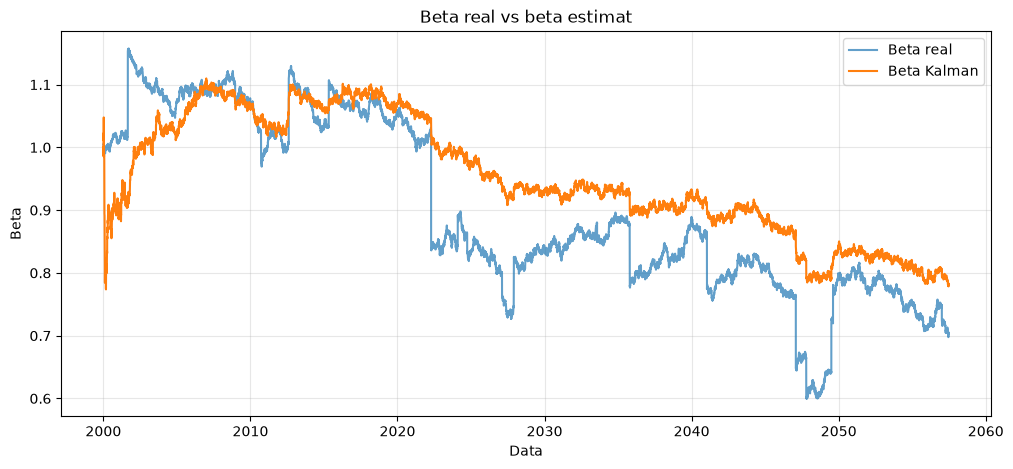

In [99]:
plt.figure(figsize=(12, 5))

plt.plot(
    mercat.index,
    mercat["Beta_Real"],
    label="Beta real",
    alpha=0.7
)

plt.plot(
    mercat.index,
    mercat["Beta_Kalman"],
    label="Beta Kalman"
)

plt.title("Beta real vs beta estimat")
plt.xlabel("Data")
plt.ylabel("Beta")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [100]:
correlacio_beta = (
    mercat["Beta_Real"]
    .corr(mercat["Beta_Kalman"])
)

print(
    f"Correlació beta real vs Kalman: "
    f"{correlacio_beta:.3f}"
)

Correlació beta real vs Kalman: 0.891


### 3.3. Qualitat de l'estimació del spread

El Kalman també estima la desviació relativa entre els dos actius.

Com que l'equilibri real del spread pot canviar, ens interessa comparar el spread estimat amb la desviació respecte al seu equilibri:

$$
Desviacio_t = Spread_t - Equilibri_t
$$

Una desviació positiva indica que el spread està per sobre del seu equilibri, i una negativa que està per sota.

Aquesta és precisament la informació que després utilitzarem per buscar oportunitats de mean reversion.

In [101]:
# ==========================================
# DESVIACIÓ REAL RESPECTE A L'EQUILIBRI
# ==========================================

mercat["Desviacio_Real"] = (
    mercat["Spread_Real"]
    - mercat["Equilibri_Real"]
)

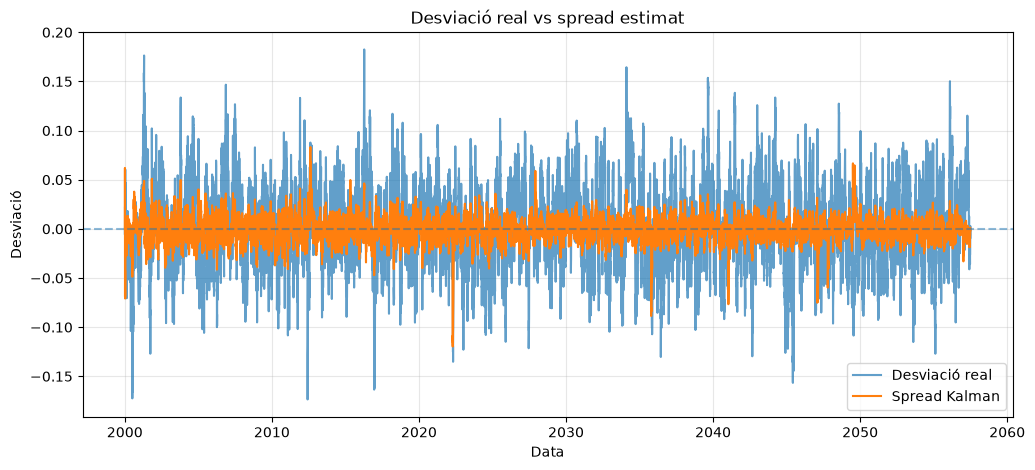

In [102]:
plt.figure(figsize=(12, 5))

plt.plot(
    mercat.index,
    mercat["Desviacio_Real"],
    label="Desviació real",
    alpha=0.7
)

plt.plot(
    mercat.index,
    mercat["Spread_Kalman"],
    label="Spread Kalman"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Desviació real vs spread estimat"
)

plt.xlabel("Data")
plt.ylabel("Desviació")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [103]:
correlacio_spread = (
    mercat["Desviacio_Real"]
    .corr(
        mercat["Spread_Kalman"]
    )
)

print(
    f"Correlació desviació real vs Kalman: "
    f"{correlacio_spread:.3f}"
)

Correlació desviació real vs Kalman: 0.617


### 3.4. Z-score del spread

El valor absolut del spread no indica per si sol si una desviació és gran.

El z-score compara el spread actual amb el seu comportament recent:

$$
Z_t = \frac{S_t - \mu_t}{\sigma_t}
$$

Un valor de $Z=2$ indica que el spread està aproximadament dues desviacions estàndard per sobre del seu nivell recent.

In [104]:
# ==========================================
# Z-SCORE DEL SPREAD ESTIMAT
# ==========================================

finestra_z = 60

mercat["Mitjana_Spread_Kalman"] = (
    mercat["Spread_Kalman"]
    .rolling(finestra_z)
    .mean()
)

mercat["Std_Spread_Kalman"] = (
    mercat["Spread_Kalman"]
    .rolling(finestra_z)
    .std()
)

mercat["Z_Kalman"] = (
    (
        mercat["Spread_Kalman"]
        - mercat["Mitjana_Spread_Kalman"]
    )
    / mercat["Std_Spread_Kalman"]
)

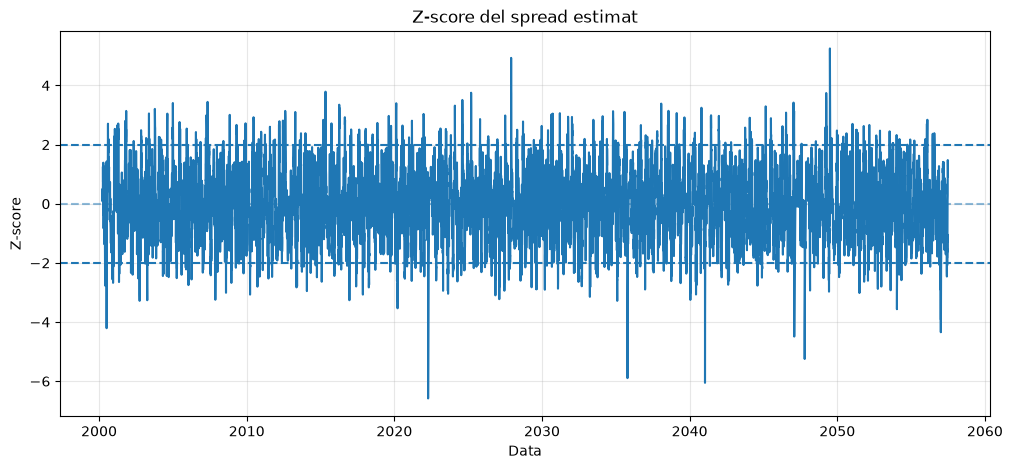

In [105]:
plt.figure(figsize=(12, 5))

plt.plot(
    mercat.index,
    mercat["Z_Kalman"],
    label="Z-score"
)

plt.axhline(
    2,
    linestyle="--"
)

plt.axhline(
    -2,
    linestyle="--"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title("Z-score del spread estimat")
plt.xlabel("Data")
plt.ylabel("Z-score")

plt.grid(alpha=0.3)

plt.show()

## 4. Regles de trading

Utilitzarem el z-score per detectar desviacions extremes del spread.

- $Z > 2$: short spread → vendre A i comprar B.
- $Z < -2$: long spread → comprar A i vendre B.
- La posició es manté fins que el spread torna cap a la zona d'equilibri.

Començarem amb una sortida a $Z=0$. Tant el llindar d'entrada com el de sortida són paràmetres que es poden calibrar.

In [106]:
# ==========================================
# PARÀMETRES DE TRADING
# ==========================================

z_entrada = 2.0
z_sortida = 0.0


# ==========================================
# GENERACIÓ DE SENYALS
# ==========================================

z = mercat["Z_Kalman"].to_numpy()

posicio_senyal = np.zeros(len(mercat))

posicio_actual = 0


for t in range(len(mercat)):

    if np.isnan(z[t]):

        posicio_senyal[t] = posicio_actual
        continue


    # ======================================
    # NO TENIM POSICIÓ
    # ======================================

    if posicio_actual == 0:

        # Spread massa alt
        if z[t] > z_entrada:

            posicio_actual = -1


        # Spread massa baix
        elif z[t] < -z_entrada:

            posicio_actual = 1


    # ======================================
    # LONG SPREAD
    # ======================================

    elif posicio_actual == 1:

        if z[t] >= -z_sortida:

            posicio_actual = 0


    # ======================================
    # SHORT SPREAD
    # ======================================

    elif posicio_actual == -1:

        if z[t] <= z_sortida:

            posicio_actual = 0


    posicio_senyal[t] = posicio_actual


mercat["Senyal_Posicio"] = posicio_senyal

### 4.1. De senyal a posició executable

El senyal calculat al temps $t$ utilitza informació disponible fins a aquell mateix instant.

Per evitar look-ahead bias, la posició que genera aquest senyal només pot aplicar-se al període següent:

$$
Posicio_t = Senyal_{t-1}
$$

Per tant:

- $Posicio_t = +1$: long spread.
- $Posicio_t = -1$: short spread.
- $Posicio_t = 0$: sense posició.

El beta utilitzat per construir el hedge també serà el beta estimat al període anterior.

In [107]:
# ==========================================
# POSICIÓ EXECUTABLE
# ==========================================

mercat["Posicio"] = (
    mercat["Senyal_Posicio"]
    .shift(1)
    .fillna(0)
)

mercat["Beta_Trading"] = (
    mercat["Beta_Kalman"]
    .shift(1)
)

### 4.2. Hedge ratio i pesos

El spread estimat segueix aproximadament la relació:

$$
\log(A_t) - \beta_t \log(B_t)
$$

Per tant, una posició long spread té la forma:

$$
+A - \beta_t B
$$

i una posició short spread:

$$
-A + \beta_t B
$$

Normalitzem els pesos perquè l'exposició bruta sigui aproximadament 1:

$$
w_A =
\frac{Posicio}{1+|\beta|}
$$

$$
w_B =
-\frac{Posicio\cdot\beta}{1+|\beta|}
$$

In [108]:
# ==========================================
# PESOS BETA-AJUSTATS
# ==========================================

beta_abs = (
    mercat["Beta_Trading"]
    .abs()
)

mercat["Pes_A"] = (
    mercat["Posicio"]
    / (1 + beta_abs)
)

mercat["Pes_B"] = (
    -mercat["Posicio"]
    * mercat["Beta_Trading"]
    / (1 + beta_abs)
)


# Durant els primers passos pot faltar beta
mercat["Pes_A"] = (
    mercat["Pes_A"]
    .fillna(0)
)

mercat["Pes_B"] = (
    mercat["Pes_B"]
    .fillna(0)
)

### 4.3. Retorn de l'estratègia

Primer calculem el retorn de cada actiu:

$$
r_{A,t} = \frac{P_{A,t}}{P_{A,t-1}} - 1
$$

$$
r_{B,t} = \frac{P_{B,t}}{P_{B,t-1}} - 1
$$

El retorn de la cartera és la suma dels retorns ponderats:

$$
r_{estrategia,t}
=
w_{A,t}r_{A,t}
+
w_{B,t}r_{B,t}
$$

Els pesos ja provenen del senyal i del beta del període anterior, de manera que no utilitzem informació futura.

In [109]:
# ==========================================
# RETORNS DELS DOS ACTIUS
# ==========================================

mercat["Retorn_A"] = (
    mercat["Preu_A"]
    .pct_change()
    .fillna(0)
)

mercat["Retorn_B"] = (
    mercat["Preu_B"]
    .pct_change()
    .fillna(0)
)


# ==========================================
# RETORN BRUT DE L'ESTRATÈGIA
# ==========================================

mercat["Retorn_Estrategia_Brut"] = (
    mercat["Pes_A"]
    * mercat["Retorn_A"]
    +
    mercat["Pes_B"]
    * mercat["Retorn_B"]
)

### 4.4. Evolució del capital abans de costos

Els retorns de l'estratègia es van acumulant de manera composta:

$$
C_t = C_{t-1}(1+r_t)
$$

Primer observarem el resultat brut. Després incorporarem costos de transacció i reequilibris.

In [110]:
# ==========================================
# CAPITAL BRUT
# ==========================================

capital_inicial = 10_000

mercat["Capital_Brut"] = (
    capital_inicial
    * (
        1
        + mercat["Retorn_Estrategia_Brut"]
    ).cumprod()
)

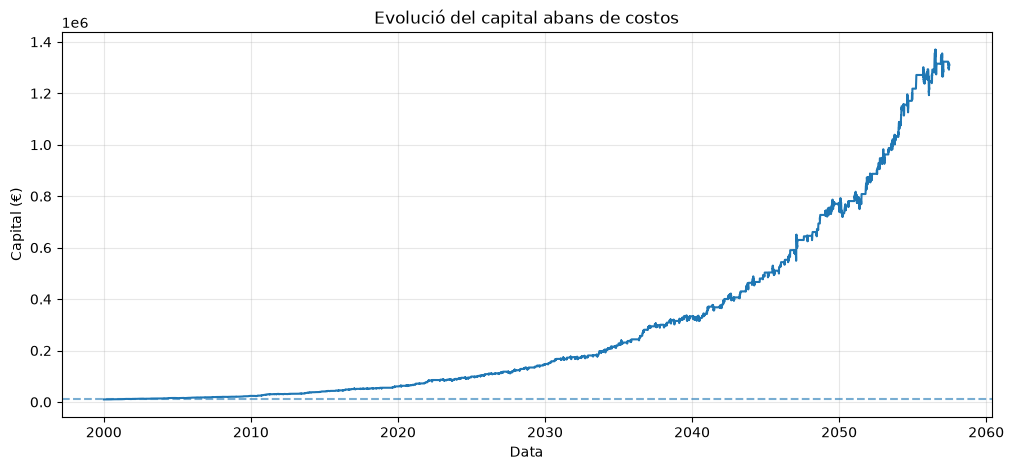

Capital inicial: 10000.00 €
Capital final brut: 1311032.76 €


In [111]:
plt.figure(figsize=(12, 5))

plt.plot(
    mercat.index,
    mercat["Capital_Brut"]
)

plt.axhline(
    capital_inicial,
    linestyle="--",
    alpha=0.6
)

plt.title("Evolució del capital abans de costos")
plt.xlabel("Data")
plt.ylabel("Capital (€)")

plt.grid(alpha=0.3)

plt.show()

print(
    f"Capital inicial: "
    f"{capital_inicial:.2f} €"
)

print(
    f"Capital final brut: "
    f"{mercat['Capital_Brut'].iloc[-1]:.2f} €"
)

### 4.5. Costos de transacció

Cada canvi en els pesos obliga a comprar o vendre actius.

Definim el turnover com:

$$
Turnover_t =
|w_{A,t} - w_{A,t-1}|
+
|w_{B,t} - w_{B,t-1}|
$$

Si el cost per unitat negociada és $c$:

$$
Cost_t = c \cdot Turnover_t
$$

i el retorn net és:

$$
r_{net,t} = r_{brut,t} - Cost_t
$$

Això inclou entrades, sortides i reajustos del hedge ratio.

In [112]:
# ==========================================
# COSTOS DE TRANSACCIÓ
# ==========================================

cost_transaccio = 0.001  # 0.1% del capital negociat


# Canvi en els pesos
mercat["Turnover"] = (
    mercat["Pes_A"].diff().abs().fillna(0)
    +
    mercat["Pes_B"].diff().abs().fillna(0)
)


# Cost del període
mercat["Cost_Transaccio"] = (
    cost_transaccio
    * mercat["Turnover"]
)


# Retorn net
mercat["Retorn_Estrategia_Net"] = (
    mercat["Retorn_Estrategia_Brut"]
    - mercat["Cost_Transaccio"]
)


# Capital després de costos
mercat["Capital_Net"] = (
    capital_inicial
    * (
        1
        + mercat["Retorn_Estrategia_Net"]
    ).cumprod()
)

### 4.6. Comparació amb Buy & Hold

Una estratègia només és interessant si entenem què aporta respecte a alternatives simples.

Compararem el pairs trading amb:

- Buy & Hold d'A;
- Buy & Hold de B;
- una cartera inicial 50/50 d'A i B.

La comparació no s'ha de fer només amb rendibilitat: més endavant també compararem volatilitat i drawdown.

In [113]:
# ==========================================
# BENCHMARKS BUY & HOLD
# ==========================================

mercat["Capital_A"] = (
    capital_inicial
    * mercat["Preu_A"]
    / mercat["Preu_A"].iloc[0]
)

mercat["Capital_B"] = (
    capital_inicial
    * mercat["Preu_B"]
    / mercat["Preu_B"].iloc[0]
)


# 50% del capital inicial a cada actiu
mercat["Capital_50_50"] = (
    0.5 * mercat["Capital_A"]
    + 0.5 * mercat["Capital_B"]
)

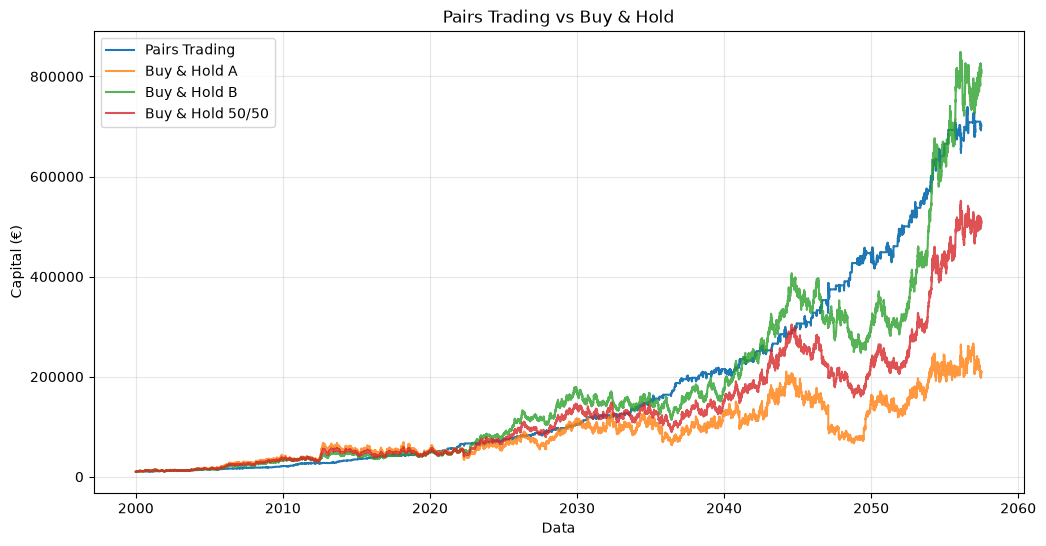

Pairs Trading: 701,850.02 €
Buy & Hold A: 207,518.50 €
Buy & Hold B: 807,593.35 €
Buy & Hold 50/50: 507,555.92 €


In [114]:
plt.figure(figsize=(12, 6))

plt.plot(
    mercat.index,
    mercat["Capital_Net"],
    label="Pairs Trading"
)

plt.plot(
    mercat.index,
    mercat["Capital_A"],
    label="Buy & Hold A",
    alpha=0.8
)

plt.plot(
    mercat.index,
    mercat["Capital_B"],
    label="Buy & Hold B",
    alpha=0.8
)

plt.plot(
    mercat.index,
    mercat["Capital_50_50"],
    label="Buy & Hold 50/50",
    alpha=0.8
)

plt.title("Pairs Trading vs Buy & Hold")
plt.xlabel("Data")
plt.ylabel("Capital (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


print(
    f"Pairs Trading: "
    f"{mercat['Capital_Net'].iloc[-1]:,.2f} €"
)

print(
    f"Buy & Hold A: "
    f"{mercat['Capital_A'].iloc[-1]:,.2f} €"
)

print(
    f"Buy & Hold B: "
    f"{mercat['Capital_B'].iloc[-1]:,.2f} €"
)

print(
    f"Buy & Hold 50/50: "
    f"{mercat['Capital_50_50'].iloc[-1]:,.2f} €"
)

## 5. Rendibilitat i risc

El capital final no és suficient per comparar estratègies.

Calcularem:

- **Rendibilitat total**: creixement acumulat del capital.
- **Rendibilitat anualitzada**: ritme de creixement compost.
- **Volatilitat anualitzada**: variabilitat dels retorns.
- **Max Drawdown**: pitjor caiguda des d'un màxim anterior.
- **Sharpe Ratio**: rendibilitat obtinguda en relació amb la volatilitat assumida.

El drawdown en cada instant és:

$$
DD_t = \frac{C_t}{\max_{s \leq t} C_s} - 1
$$

In [115]:
# ==========================================
# FUNCIÓ DE MÈTRIQUES
# ==========================================

def calcular_metriques(capital, retorns):

    capital = capital.dropna()
    retorns = retorns.dropna()

    n_passos = len(retorns)

    # Rendibilitat total
    rendibilitat_total = (
        capital.iloc[-1]
        / capital.iloc[0]
        - 1
    )

    # Rendibilitat anualitzada composta
    rendibilitat_anual = (
        (
            capital.iloc[-1]
            / capital.iloc[0]
        )
        ** (252 / n_passos)
        - 1
    )

    # Volatilitat anualitzada
    volatilitat_anual = (
        retorns.std()
        * np.sqrt(252)
    )

    # Drawdown
    maxim_acumulat = capital.cummax()

    drawdown = (
        capital
        / maxim_acumulat
        - 1
    )

    max_drawdown = drawdown.min()

    # Sharpe amb tipus lliure de risc = 0
    if retorns.std() > 0:

        sharpe = (
            retorns.mean()
            / retorns.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    return {
        "Rendibilitat_Total": rendibilitat_total,
        "Rendibilitat_Anual": rendibilitat_anual,
        "Volatilitat_Anual": volatilitat_anual,
        "Max_Drawdown": max_drawdown,
        "Sharpe": sharpe
    }

In [116]:
# ==========================================
# RETORNS DELS BENCHMARKS
# ==========================================

mercat["Retorn_50_50"] = (
    mercat["Capital_50_50"]
    .pct_change()
    .fillna(0)
)


# ==========================================
# MÈTRIQUES
# ==========================================

metriques = pd.DataFrame({

    "Pairs Trading": calcular_metriques(
        mercat["Capital_Net"],
        mercat["Retorn_Estrategia_Net"]
    ),

    "Buy & Hold A": calcular_metriques(
        mercat["Capital_A"],
        mercat["Retorn_A"]
    ),

    "Buy & Hold B": calcular_metriques(
        mercat["Capital_B"],
        mercat["Retorn_B"]
    ),

    "Buy & Hold 50/50": calcular_metriques(
        mercat["Capital_50_50"],
        mercat["Retorn_50_50"]
    )
}).T


metriques

,Rendibilitat_Total,Rendibilitat_Anual,Volatilitat_Anual,Max_Drawdown,Sharpe
Pairs Trading,69.185002,0.074031,0.080220,-0.092420,0.930235
Buy & Hold A,19.751850,0.052268,0.320253,-0.682710,0.320477
Buy & Hold B,79.759335,0.076566,0.158408,-0.391800,0.544984
Buy & Hold 50/50,49.755592,0.068199,0.195942,-0.479526,0.434854


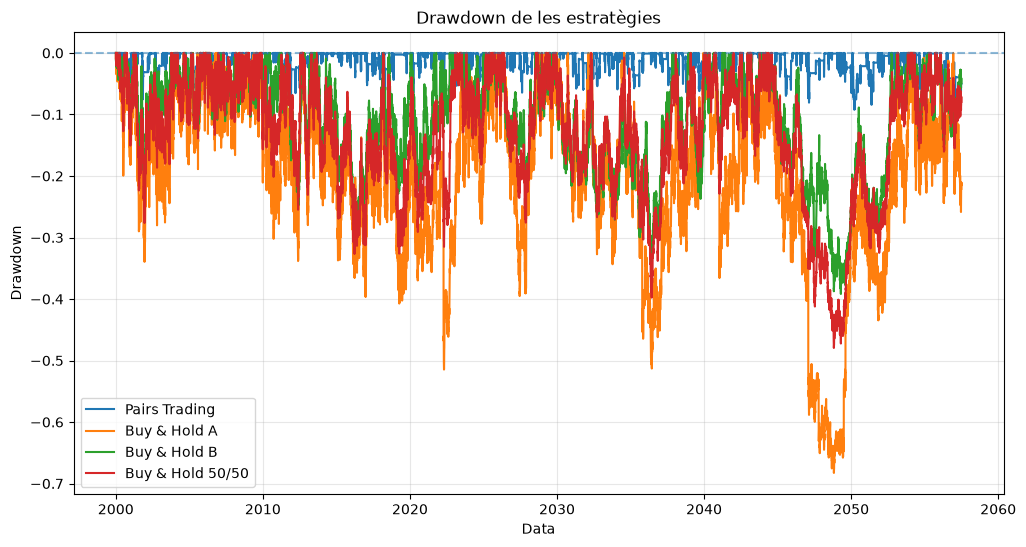

In [117]:
# ==========================================
# DRAWDOWNS
# ==========================================

columnes_capital = {
    "Pairs Trading": "Capital_Net",
    "Buy & Hold A": "Capital_A",
    "Buy & Hold B": "Capital_B",
    "Buy & Hold 50/50": "Capital_50_50"
}

plt.figure(figsize=(12, 6))


for nom, columna in columnes_capital.items():

    maxim = (
        mercat[columna]
        .cummax()
    )

    drawdown = (
        mercat[columna]
        / maxim
        - 1
    )

    plt.plot(
        mercat.index,
        drawdown,
        label=nom
    )


plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title("Drawdown de les estratègies")
plt.xlabel("Data")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5.1. Interpretació dels resultats

La diferència principal apareix en el risc assumit.

El pairs trading obté aproximadament un 7.4% anual amb:

- volatilitat anual d'aproximadament 8%;
- max drawdown d'aproximadament -9%;
- Sharpe proper a 0.93.

En canvi, els Buy & Hold depenen molt més de l'evolució direccional de cada actiu. En aquesta simulació B ha funcionat molt millor que A, però aquesta diferència no seria coneguda per endavant.

L'objectiu del pairs trading no és predir quin actiu pujarà més, sinó explotar desviacions relatives entre dos actius relacionats.

Això no fa que els resultats siguin predictibles, però pot reduir la dependència de la direcció general del mercat i produir un perfil de risc més estable.

## 6. Anàlisi de les operacions

Ara analitzem cada operació del pairs trading per separat.

Per cada trade guardarem:

- data d'entrada i sortida;
- direcció: long spread o short spread;
- durada;
- z-score d'entrada;
- retorn net, inclosos els costos.

El retorn d'una operació es calcula de forma composta:

$$
R_{trade} = \prod_{t=entrada}^{sortida}(1+r_{net,t}) - 1
$$

In [118]:
# ==========================================
# CONSTRUCCIÓ DE LES OPERACIONS INDIVIDUALS
# ==========================================

operacions = []

posicio = mercat["Posicio"].to_numpy()
retorns_nets = mercat["Retorn_Estrategia_Net"].to_numpy()
z = mercat["Z_Kalman"].to_numpy()

index = mercat.index

entrada = None
direccio = None
z_entrada_trade = None


for t in range(1, len(mercat)):

    posicio_anterior = posicio[t - 1]
    posicio_actual = posicio[t]


    # ======================================
    # ENTRADA
    # ======================================

    if posicio_anterior == 0 and posicio_actual != 0:

        entrada = t

        direccio = (
            "Long Spread"
            if posicio_actual == 1
            else "Short Spread"
        )

        z_entrada_trade = z[t - 1]


    # ======================================
    # SORTIDA
    # ======================================

    elif posicio_anterior != 0 and posicio_actual == 0:

        sortida = t

        retorn_trade = (
            np.prod(
                1 + retorns_nets[
                    entrada:sortida + 1
                ]
            )
            - 1
        )

        durada = (
            sortida
            - entrada
        )

        operacions.append({
            "Entrada": index[entrada],
            "Sortida": index[sortida],
            "Direccio": direccio,
            "Durada": durada,
            "Z_Entrada": z_entrada_trade,
            "Retorn_Net": retorn_trade
        })

        entrada = None
        direccio = None
        z_entrada_trade = None


operacions = pd.DataFrame(
    operacions
)

### 6.1. Estadístiques per operació

La taxa d'encert no és suficient per valorar una estratègia.

També ens interessa la mida dels guanys i de les pèrdues.

L'expectancy aproximada és:

$$
E[R] =
P(guanyar)E[R|guanyar]
+
P(perdre)E[R|perdre]
$$

Una estratègia pot funcionar amb una taxa d'encert baixa si els guanys són suficientment grans respecte a les pèrdues.

In [119]:
# ==========================================
# ESTADÍSTIQUES DE LES OPERACIONS
# ==========================================

guanyadores = (
    operacions["Retorn_Net"] > 0
)

perdedores = (
    operacions["Retorn_Net"] < 0
)


n_operacions = len(
    operacions
)

win_rate = (
    guanyadores.mean()
)

retorn_mitja = (
    operacions["Retorn_Net"]
    .mean()
)

retorn_median = (
    operacions["Retorn_Net"]
    .median()
)

guany_mitja = (
    operacions.loc[
        guanyadores,
        "Retorn_Net"
    ]
    .mean()
)

perdua_mitja = (
    operacions.loc[
        perdedores,
        "Retorn_Net"
    ]
    .mean()
)

durada_mediana = (
    operacions["Durada"]
    .median()
)


print(
    f"Operacions: {n_operacions}"
)

print(
    f"Win rate: {win_rate:.2%}"
)

print(
    f"Retorn mitjà per trade: "
    f"{retorn_mitja:.2%}"
)

print(
    f"Retorn medià per trade: "
    f"{retorn_median:.2%}"
)

print(
    f"Guany mitjà: "
    f"{guany_mitja:.2%}"
)

print(
    f"Pèrdua mitjana: "
    f"{perdua_mitja:.2%}"
)

print(
    f"Durada mediana: "
    f"{durada_mediana:.0f} passos"
)

Operacions: 311
Win rate: 80.39%
Retorn mitjà per trade: 1.39%
Retorn medià per trade: 1.70%
Guany mitjà: 2.10%
Pèrdua mitjana: -1.49%
Durada mediana: 12 passos


### 6.2. Distribució dels retorns per operació

La mitjana no mostra tota la forma de la distribució.

Ens interessa veure si els retorns es concentren al voltant d'un valor estable o si existeixen algunes pèrdues extremes que expliquen bona part del risc de l'estratègia.

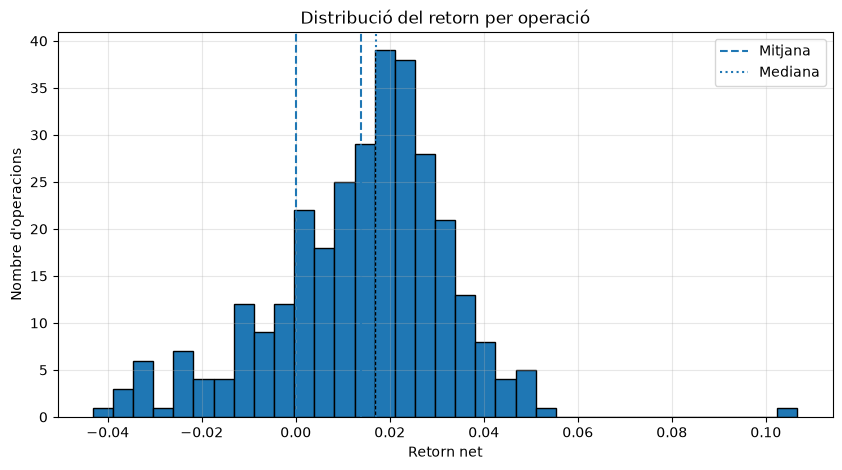

In [120]:
# ==========================================
# DISTRIBUCIÓ DEL RETORN DELS TRADES
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    operacions["Retorn_Net"],
    bins=35,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.axvline(
    operacions["Retorn_Net"].mean(),
    linestyle="--",
    label="Mitjana"
)

plt.axvline(
    operacions["Retorn_Net"].median(),
    linestyle=":",
    label="Mediana"
)

plt.title("Distribució del retorn per operació")
plt.xlabel("Retorn net")
plt.ylabel("Nombre d'operacions")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6.3. Durada de les operacions guanyadores i perdedores

En una estratègia de mean reversion, una operació que tarda molt a revertir pot indicar que la relació s'ha deteriorat o que el model ha entrat en un mal moment.

Compararem la durada dels trades guanyadors amb la dels perdedors.

In [121]:
# ==========================================
# GUANYADORES VS PERDEDORES
# ==========================================

resum_trades = pd.DataFrame({
    "Guanyadores": [
        operacions.loc[
            operacions["Retorn_Net"] > 0,
            "Durada"
        ].median(),

        operacions.loc[
            operacions["Retorn_Net"] > 0,
            "Durada"
        ].mean()
    ],

    "Perdedores": [
        operacions.loc[
            operacions["Retorn_Net"] < 0,
            "Durada"
        ].median(),

        operacions.loc[
            operacions["Retorn_Net"] < 0,
            "Durada"
        ].mean()
    ]
},
index=[
    "Durada mediana",
    "Durada mitjana"
])

resum_trades

,Guanyadores,Perdedores
Durada mediana,10.50,24.000000
Durada mitjana,11.52,26.278689


In [122]:
correlacio_durada_retorn = (
    operacions["Durada"]
    .corr(
        operacions["Retorn_Net"]
    )
)

print(
    f"Correlació durada-retorn: "
    f"{correlacio_durada_retorn:.3f}"
)

Correlació durada-retorn: -0.728


### 6.4. Interpretació de la durada dels trades

La distribució mostra que la majoria d'operacions són positives, però existeix una cua de pèrdues que redueix el retorn mitjà.

Les operacions guanyadores duren típicament uns 10-12 passos, mentre que les perdedores duren aproximadament el doble.

A més, observem una correlació fortament negativa entre durada i retorn:

$$
Corr(Durada, Retorn) \approx -0.73
$$

Per tant, quan una operació tarda molt a revertir, tendeix a tenir pitjors resultats.

Això és un senyal de risc, però no implica que tancar automàticament els trades llargs millori l'estratègia. La correlació no demostra causalitat.

### 6.5. Deteriorament de la relació i resultat dels trades

Com que el mercat és simulat, coneixem el deteriorament real de la relació.

Utilitzarem aquesta informació només com a diagnòstic, mai per generar senyals.

Per cada operació mesurarem:

- deteriorament en el moment d'entrada;
- deteriorament mitjà durant el trade;
- deteriorament màxim durant el trade.

Això permet comprovar si les pèrdues apareixen especialment quan la relació entre els dos actius deixa de ser estable.

In [123]:
# ==========================================
# DETERIORAMENT DURANT CADA OPERACIÓ
# ==========================================

deteriorament_array = (
    mercat["Deteriorament"]
    .to_numpy()
)

deteriorament_entrada = []
deteriorament_mitja = []
deteriorament_maxim = []


for _, trade in operacions.iterrows():

    entrada = mercat.index.get_loc(
        trade["Entrada"]
    )

    sortida = mercat.index.get_loc(
        trade["Sortida"]
    )

    tram = deteriorament_array[
        entrada:sortida + 1
    ]

    deteriorament_entrada.append(
        deteriorament_array[entrada]
    )

    deteriorament_mitja.append(
        np.mean(tram)
    )

    deteriorament_maxim.append(
        np.max(tram)
    )


operacions["Deteriorament_Entrada"] = (
    deteriorament_entrada
)

operacions["Deteriorament_Mitja"] = (
    deteriorament_mitja
)

operacions["Deteriorament_Maxim"] = (
    deteriorament_maxim
)

In [124]:
# ==========================================
# CORRELACIÓ AMB EL RESULTAT DEL TRADE
# ==========================================

correlacions_deteriorament = (
    operacions[
        [
            "Retorn_Net",
            "Durada",
            "Deteriorament_Entrada",
            "Deteriorament_Mitja",
            "Deteriorament_Maxim"
        ]
    ]
    .corr()
)

correlacions_deteriorament

,Retorn_Net,Durada,Deteriorament_Entrada,Deteriorament_Mitja,Deteriorament_Maxim
Retorn_Net,1.000000,-0.728296,0.014547,0.037770,-0.035824
Durada,-0.728296,1.000000,-0.052110,-0.088457,0.041871
Deteriorament_Entrada,0.014547,-0.052110,1.000000,0.936675,0.818612
Deteriorament_Mitja,0.037770,-0.088457,0.936675,1.000000,0.917497
Deteriorament_Maxim,-0.035824,0.041871,0.818612,0.917497,1.000000


In [125]:
# ==========================================
# GUANYADORES VS PERDEDORES
# ==========================================

resum_deteriorament = pd.DataFrame({

    "Guanyadores": [

        operacions.loc[
            operacions["Retorn_Net"] > 0,
            "Deteriorament_Entrada"
        ].mean(),

        operacions.loc[
            operacions["Retorn_Net"] > 0,
            "Deteriorament_Mitja"
        ].mean(),

        operacions.loc[
            operacions["Retorn_Net"] > 0,
            "Deteriorament_Maxim"
        ].mean()
    ],

    "Perdedores": [

        operacions.loc[
            operacions["Retorn_Net"] < 0,
            "Deteriorament_Entrada"
        ].mean(),

        operacions.loc[
            operacions["Retorn_Net"] < 0,
            "Deteriorament_Mitja"
        ].mean(),

        operacions.loc[
            operacions["Retorn_Net"] < 0,
            "Deteriorament_Maxim"
        ].mean()
    ]
},
index=[
    "Deteriorament entrada",
    "Deteriorament mitjà",
    "Deteriorament màxim"
])

resum_deteriorament

,Guanyadores,Perdedores
Deteriorament entrada,0.076047,0.081338
Deteriorament mitjà,0.073905,0.075984
Deteriorament màxim,0.102878,0.128613


### 6.6. Conclusió del diagnòstic

La durada del trade presenta una relació fortament negativa amb el retorn:

$$
Corr(Durada, Retorn) \approx -0.73
$$

En canvi, el deteriorament real de la relació mostra correlacions gairebé nul·les amb el resultat de les operacions.

Per tant, en aquesta simulació els trades llargs tendeixen a ser pitjors, però el deteriorament ocult no sembla explicar directament aquest comportament.

No afegirem regles basades en aquesta variable, ja que tampoc seria observable en un mercat real.

## 7. Optimització dels paràmetres

L'estratègia conté diversos paràmetres que fins ara hem fixat manualment.

Calibrarem principalment:

- finestra del z-score;
- llindar d'entrada;
- llindar de sortida;
- velocitat d'adaptació del beta del Kalman.

Cada configuració es provarà sobre múltiples mercats simulats utilitzant les mateixes seeds.

L'objectiu no és trobar el punt amb més rendibilitat, sinó una zona de paràmetres amb bon creixement i risc controlat.

In [126]:
# ==========================================
# ESPAI INICIAL DE PARÀMETRES
# ==========================================

finestra_z_vals = [
    40,
    60,
    90
]

z_entrada_vals = [
    1.5,
    2.0,
    2.5
]

z_sortida_vals = [
    0.0,
    0.5,
    1.0
]

q_beta_vals = [
    0.001**2,
    0.002**2,
    0.004**2
]

### 7.1. Funció completa de simulació i backtest

Per calibrar els paràmetres necessitem repetir el mateix procés moltes vegades.

La funció següent executa, per una seed determinada:

1. simulació del mercat;
2. estimació amb Kalman;
3. càlcul del z-score;
4. generació de senyals long/short;
5. aplicació de costos;
6. càlcul de rendibilitat i risc.

Els paràmetres del mercat es mantenen fixos. Només modificarem els paràmetres que pertanyen a l'algoritme.

In [127]:
def simular_pairs_trading(
    seed,
    finestra_z=60,
    z_entrada=2.0,
    z_sortida=0.0,
    q_beta=0.002**2,
    n_passos=15_000,
    cost_transaccio=0.001,
    capital_inicial=10_000,
    mostrar_progres=False
):

    # ==========================================
    # COMPROVACIONS
    # ==========================================

    if z_sortida >= z_entrada:
        raise ValueError(
            "z_sortida ha de ser inferior a z_entrada."
        )

    rng = np.random.default_rng(seed)


    # ==========================================
    # FUNCIÓ AUXILIAR DE PROGRÉS
    # ==========================================

    def progres(etapa, t, total):

        if not mostrar_progres:
            return

        interval = max(
            1,
            total // 100
        )

        if (
            t % interval == 0
            or t == total - 1
        ):

            percentatge = (
                (t + 1)
                / total
                * 100
            )

            print(
                f"\r{etapa}: "
                f"{percentatge:.1f}%",
                end=""
            )


    # ==========================================
    # 1. PARÀMETRES DEL MERCAT
    # ==========================================

    mu_mercat = 0.0003
    sigma_mercat = 0.01

    kappa_max = 0.08

    sigma_spread_min = 0.015
    sigma_spread_max = 0.025

    prob_canvi_equilibri = 0.002
    sigma_canvi_equilibri = 0.05

    persistencia_deteriorament = 0.97
    sigma_deteriorament = 0.01

    prob_xoc_relacio = 0.003
    xoc_relacio_min = 0.20
    xoc_relacio_max = 0.60

    prob_salt_spread = 0.001
    sigma_salt_spread = 0.08

    beta_inicial = 1.0

    sigma_canvi_beta = 0.0015

    prob_salt_beta = 0.0015
    sigma_salt_beta = 0.08

    beta_min = 0.6
    beta_max = 1.4


    # ==========================================
    # 2. DETERIORAMENT DE LA RELACIÓ
    # ==========================================

    deteriorament = np.zeros(
        n_passos
    )

    for t in range(
        1,
        n_passos
    ):

        deteriorament[t] = (
            persistencia_deteriorament
            * deteriorament[t - 1]
            + rng.normal(
                0,
                sigma_deteriorament
            )
        )

        if (
            rng.random()
            < prob_xoc_relacio
        ):

            deteriorament[t] += (
                rng.uniform(
                    xoc_relacio_min,
                    xoc_relacio_max
                )
            )

        deteriorament[t] = np.clip(
            deteriorament[t],
            0,
            1
        )

        progres(
            "Deteriorament",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 3. KAPPA I SIGMA DINÀMICS
    # ==========================================

    kappa_dinamic = (
        kappa_max
        * (1 - deteriorament)
    )

    sigma_spread_dinamic = (
        sigma_spread_min
        + deteriorament
        * (
            sigma_spread_max
            - sigma_spread_min
        )
    )


    # ==========================================
    # 4. EQUILIBRI DINÀMIC
    # ==========================================

    equilibri_spread = np.zeros(
        n_passos
    )

    equilibri_actual = 0.0

    for t in range(
        1,
        n_passos
    ):

        if (
            rng.random()
            < prob_canvi_equilibri
        ):

            equilibri_actual += (
                rng.normal(
                    0,
                    sigma_canvi_equilibri
                )
            )

        equilibri_spread[t] = (
            equilibri_actual
        )

        progres(
            "Equilibri",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 5. SPREAD REAL
    # ==========================================

    spread_real = np.zeros(
        n_passos
    )

    spread_real[0] = (
        equilibri_spread[0]
    )

    for t in range(
        1,
        n_passos
    ):

        soroll = rng.normal(
            0,
            sigma_spread_dinamic[t]
        )

        salt = 0.0

        if (
            rng.random()
            < prob_salt_spread
        ):

            salt = rng.normal(
                0,
                sigma_salt_spread
            )

        spread_real[t] = (
            spread_real[t - 1]
            + kappa_dinamic[t]
            * (
                equilibri_spread[t]
                - spread_real[t - 1]
            )
            + soroll
            + salt
        )

        progres(
            "Spread",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 6. BETA REAL
    # ==========================================

    beta_real = np.zeros(
        n_passos
    )

    beta_real[0] = (
        beta_inicial
    )

    for t in range(
        1,
        n_passos
    ):

        canvi_beta = rng.normal(
            0,
            sigma_canvi_beta
        )

        if (
            rng.random()
            < prob_salt_beta
        ):

            canvi_beta += (
                rng.normal(
                    0,
                    sigma_salt_beta
                )
            )

        beta_real[t] = (
            beta_real[t - 1]
            + canvi_beta
        )

        beta_real[t] = np.clip(
            beta_real[t],
            beta_min,
            beta_max
        )

        progres(
            "Beta real",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 7. PREUS
    # ==========================================

    retorns_mercat = rng.normal(
        mu_mercat,
        sigma_mercat,
        n_passos
    )

    factor_comu = np.cumsum(
        retorns_mercat
    )

    log_B = factor_comu

    log_A = (
        beta_real * log_B
        + spread_real
    )

    preu_B = (
        100
        * np.exp(log_B)
    )

    preu_A = (
        100
        * np.exp(log_A)
    )


    # ==========================================
    # 8. KALMAN FILTER
    # ==========================================

    phi_spread = 0.92

    q_alpha = 0.003**2
    q_spread = 0.015**2

    r_observacio = 0.005**2

    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, phi_spread]
    ])

    Q = np.diag([
        q_alpha,
        q_beta,
        q_spread
    ])

    estat = np.array([
        0.0,
        1.0,
        0.0
    ])

    P = np.eye(3)

    beta_kalman = np.zeros(
        n_passos
    )

    spread_kalman = np.zeros(
        n_passos
    )


    for t in range(
        n_passos
    ):

        # Predicció
        estat_pred = (
            F @ estat
        )

        P_pred = (
            F @ P @ F.T
            + Q
        )


        # Observació
        H = np.array([
            1.0,
            log_B[t],
            1.0
        ])

        innovacio = (
            log_A[t]
            - H @ estat_pred
        )

        variancia_innovacio = (
            H @ P_pred @ H.T
            + r_observacio
        )


        # Kalman gain
        K = (
            P_pred @ H.T
            / variancia_innovacio
        )


        # Actualització
        estat = (
            estat_pred
            + K * innovacio
        )

        I = np.eye(3)

        KH = np.outer(
            K,
            H
        )

        P = (
            (I - KH)
            @ P_pred
            @ (I - KH).T
            + np.outer(K, K)
            * r_observacio
        )


        beta_kalman[t] = (
            estat[1]
        )

        spread_kalman[t] = (
            estat[2]
        )

        progres(
            "Kalman",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 9. Z-SCORE
    # ==========================================

    serie_spread = pd.Series(
        spread_kalman
    )

    mitjana_spread = (
        serie_spread
        .rolling(finestra_z)
        .mean()
        .to_numpy()
    )

    std_spread = (
        serie_spread
        .rolling(finestra_z)
        .std()
        .to_numpy()
    )

    z = (
        (
            spread_kalman
            - mitjana_spread
        )
        / std_spread
    )


    # ==========================================
    # 10. SENYALS
    # ==========================================

    senyal = np.zeros(
        n_passos
    )

    posicio_actual = 0


    for t in range(
        n_passos
    ):

        if np.isnan(z[t]):

            senyal[t] = (
                posicio_actual
            )

            progres(
                "Senyals",
                t,
                n_passos
            )

            continue


        # Fora del mercat
        if posicio_actual == 0:

            if z[t] > z_entrada:

                posicio_actual = -1

            elif z[t] < -z_entrada:

                posicio_actual = 1


        # Long spread
        elif posicio_actual == 1:

            if (
                z[t]
                >= -z_sortida
            ):

                posicio_actual = 0


        # Short spread
        elif posicio_actual == -1:

            if (
                z[t]
                <= z_sortida
            ):

                posicio_actual = 0


        senyal[t] = (
            posicio_actual
        )

        progres(
            "Senyals",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 11. POSICIÓ EXECUTABLE
    # ==========================================

    posicio = np.roll(
        senyal,
        1
    )

    posicio[0] = 0


    beta_trading = np.roll(
        beta_kalman,
        1
    )

    beta_trading[0] = np.nan


    # ==========================================
    # 12. PESOS
    # ==========================================

    beta_abs = np.abs(
        beta_trading
    )

    pes_A = (
        posicio
        / (1 + beta_abs)
    )

    pes_B = (
        -posicio
        * beta_trading
        / (1 + beta_abs)
    )

    pes_A = np.nan_to_num(
        pes_A
    )

    pes_B = np.nan_to_num(
        pes_B
    )


    # ==========================================
    # 13. RETORNS
    # ==========================================

    retorn_A = np.zeros(
        n_passos
    )

    retorn_B = np.zeros(
        n_passos
    )

    retorn_A[1:] = (
        preu_A[1:]
        / preu_A[:-1]
        - 1
    )

    retorn_B[1:] = (
        preu_B[1:]
        / preu_B[:-1]
        - 1
    )


    # ==========================================
    # 14. TURNOVER I COSTOS
    # ==========================================

    turnover = np.zeros(
        n_passos
    )

    turnover[1:] = (
        np.abs(
            pes_A[1:]
            - pes_A[:-1]
        )
        +
        np.abs(
            pes_B[1:]
            - pes_B[:-1]
        )
    )

    costos = (
        turnover
        * cost_transaccio
    )


    # ==========================================
    # 15. RETORN NET
    # ==========================================

    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )

    retorn_net = (
        retorn_brut
        - costos
    )


    # ==========================================
    # 16. CAPITAL I RUÏNA
    # ==========================================

    capital = np.zeros(
        n_passos
    )

    capital[0] = (
        capital_inicial
    )

    ruina = False

    maxim_capital = (
        capital_inicial
    )

    max_drawdown = 0.0


    for t in range(
        1,
        n_passos
    ):

        capital[t] = (
            capital[t - 1]
            * (
                1
                + retorn_net[t]
            )
        )


        # Evitem permetre que el capital
        # torni a créixer després de la ruïna
        if capital[t] <= 0:

            capital[t:] = 0

            ruina = True

            progres(
                "Capital",
                n_passos - 1,
                n_passos
            )

            break


        maxim_capital = max(
            maxim_capital,
            capital[t]
        )

        drawdown = (
            capital[t]
            / maxim_capital
            - 1
        )

        max_drawdown = min(
            max_drawdown,
            drawdown
        )

        progres(
            "Capital",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    # ==========================================
    # 17. MÈTRIQUES DE RETORN I RISC
    # ==========================================

    capital_final = (
        capital[-1]
    )

    rendibilitat_total = (
        capital_final
        / capital_inicial
        - 1
    )


    if (
        capital_final > 0
    ):

        log_growth = np.log(
            capital_final
            / capital_inicial
        )

        rendibilitat_anual = (
            (
                capital_final
                / capital_inicial
            )
            ** (
                252
                / n_passos
            )
            - 1
        )

    else:

        log_growth = -np.inf
        rendibilitat_anual = -1.0


    volatilitat_anual = (
        np.std(
            retorn_net,
            ddof=1
        )
        * np.sqrt(252)
    )


    if (
        np.std(
            retorn_net,
            ddof=1
        ) > 0
    ):

        sharpe = (
            np.mean(
                retorn_net
            )
            / np.std(
                retorn_net,
                ddof=1
            )
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    # ==========================================
    # 18. OPERACIONS INDIVIDUALS
    # ==========================================

    retorns_trades = []
    durades_trades = []

    entrada = None


    for t in range(
        1,
        n_passos
    ):

        posicio_anterior = (
            posicio[t - 1]
        )

        posicio_actual = (
            posicio[t]
        )


        # Entrada
        if (
            posicio_anterior == 0
            and posicio_actual != 0
        ):

            entrada = t


        # Sortida
        elif (
            posicio_anterior != 0
            and posicio_actual == 0
            and entrada is not None
        ):

            retorn_trade = (
                np.prod(
                    1
                    + retorn_net[
                        entrada:t + 1
                    ]
                )
                - 1
            )

            retorns_trades.append(
                retorn_trade
            )

            durades_trades.append(
                t - entrada
            )

            entrada = None

        progres(
            "Trades",
            t,
            n_passos
        )

    if mostrar_progres:
        print()


    retorns_trades = np.array(
        retorns_trades
    )


    if len(
        retorns_trades
    ) > 0:

        win_rate = np.mean(
            retorns_trades > 0
        )

        expectancy = np.mean(
            retorns_trades
        )

        durada_mediana = np.median(
            durades_trades
        )

    else:

        win_rate = np.nan
        expectancy = np.nan
        durada_mediana = np.nan


    # ==========================================
    # 19. RESULTAT
    # ==========================================

    return {
        "Capital_Final":
            capital_final,

        "Rendibilitat_Total":
            rendibilitat_total,

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Log_Growth":
            log_growth,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Max_Drawdown":
            max_drawdown,

        "Sharpe":
            sharpe,

        "Operacions":
            len(retorns_trades),

        "Win_Rate":
            win_rate,

        "Expectancy":
            expectancy,

        "Durada_Mediana":
            durada_mediana,

        "Turnover_Total":
            np.sum(turnover),

        "Ruina":
            ruina
    }

In [128]:
resultat_prova = simular_pairs_trading(
    seed=42,
    finestra_z=60,
    z_entrada=2.0,
    z_sortida=0.0,
    q_beta=0.002**2,
    mostrar_progres=True
)

pd.Series(
    resultat_prova
)

Deteriorament: 100.0%
Equilibri: 100.0%
Spread: 100.0%
Beta real: 100.0%
Kalman: 100.0%
Senyals: 100.0%
Capital: 100.0%
Trades: 100.0%


Capital_Final         985191.844744
Rendibilitat_Total        97.519184
Rendibilitat_Anual         0.080168
Log_Growth                 4.590251
Volatilitat_Anual          0.094697
Max_Drawdown              -0.330748
Sharpe                     0.863343
Operacions                      318
Win_Rate                   0.827044
Expectancy                 0.014974
Durada_Mediana                 15.0
Turnover_Total           639.953055
Ruina                         False
dtype: object

### 7.2. Primera ronda d'optimització

Provarem totes les combinacions de la grid sobre 10 mercats simulats diferents.

$$
81\ configuracions \times 10\ seeds = 810\ backtests
$$

Les mateixes 10 seeds s'utilitzen per a totes les configuracions. Així, les diferències entre configuracions provenen dels paràmetres de l'algoritme i no de mercats diferents.

10 simulacions són poques per escollir una configuració final, però suficients per a una primera ronda de filtratge.

L'objectiu és descartar zones dolentes i identificar regions prometedores. Les configuracions finalistes es validaran posteriorment amb moltes més seeds completament noves.

In [129]:
from itertools import product


# ==========================================
# COMBINACIONS DE PARÀMETRES
# ==========================================

combinacions = list(
    product(
        finestra_z_vals,
        z_entrada_vals,
        z_sortida_vals,
        q_beta_vals
    )
)

print(
    f"Configuracions totals: "
    f"{len(combinacions)}"
)

Configuracions totals: 81


In [130]:
# ==========================================
# SEEDS DE LA PRIMERA RONDA
# ==========================================

seeds_optimitzacio = [
    10_000 + i
    for i in range(10)
]

print(
    f"Mercats per configuració: "
    f"{len(seeds_optimitzacio)}"
)

print(
    f"Backtests totals: "
    f"{len(combinacions) * len(seeds_optimitzacio)}"
)

Mercats per configuració: 10
Backtests totals: 810


In [131]:
# ==========================================
# PRIMERA RONDA D'OPTIMITZACIÓ
# ==========================================

resultats_optimitzacio = []

total_backtests = (
    len(combinacions)
    * len(seeds_optimitzacio)
)

comptador = 0


for id_config, (
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in enumerate(combinacions):

    for seed in seeds_optimitzacio:

        resultat = simular_pairs_trading(
            seed=seed,
            finestra_z=finestra_z,
            z_entrada=z_entrada,
            z_sortida=z_sortida,
            q_beta=q_beta,
            mostrar_progres=False
        )

        resultats_optimitzacio.append({

            "Config": id_config,

            "Seed": seed,

            "Finestra_Z": finestra_z,

            "Z_Entrada": z_entrada,

            "Z_Sortida": z_sortida,

            "Q_Beta": q_beta,

            **resultat
        })


        # ==================================
        # PROGRÉS GLOBAL
        # ==================================

        comptador += 1

        percentatge = (
            comptador
            / total_backtests
            * 100
        )

        print(
            f"\rOptimització: "
            f"{percentatge:.1f}% "
            f"({comptador}/{total_backtests})",
            end=""
        )


resultats_optimitzacio = pd.DataFrame(
    resultats_optimitzacio
)

print(
    "\nOptimització completada!"
)

Optimització: 100.0% (810/810)
Optimització completada!


### 7.3. Resum de cada configuració

No compararem configuracions a partir d'un únic mercat.

Per cada combinació calcularem valors agregats sobre les 10 seeds, principalment:

- creixement medià;
- rendibilitat anual mediana;
- Sharpe medià;
- drawdown medià;
- pitjor drawdown observat;
- taxa de ruïna.

En aquesta primera ronda ens interessa especialment trobar configuracions que mantinguin un bon creixement sense assumir drawdowns excessius.

In [132]:
# ==========================================
# RESUM DE LES 81 CONFIGURACIONS
# ==========================================

resum_optimitzacio = []


for id_config in range(
    len(combinacions)
):

    df_config = (
        resultats_optimitzacio[
            resultats_optimitzacio["Config"]
            == id_config
        ]
    )

    resum_optimitzacio.append({

        "Config":
            id_config,

        "Finestra_Z":
            df_config["Finestra_Z"].iloc[0],

        "Z_Entrada":
            df_config["Z_Entrada"].iloc[0],

        "Z_Sortida":
            df_config["Z_Sortida"].iloc[0],

        "Q_Beta":
            df_config["Q_Beta"].iloc[0],

        "LogGrowth_Mediana":
            df_config["Log_Growth"]
            .replace(
                [-np.inf, np.inf],
                np.nan
            )
            .median(),

        "Rendibilitat_Anual_Mediana":
            df_config[
                "Rendibilitat_Anual"
            ].median(),

        "Sharpe_Mediana":
            df_config[
                "Sharpe"
            ].median(),

        "DD_Mediana":
            df_config[
                "Max_Drawdown"
            ].median(),

        "DD_Pitjor":
            df_config[
                "Max_Drawdown"
            ].min(),

        "Expectancy_Mediana":
            df_config[
                "Expectancy"
            ].median(),

        "Operacions_Mediana":
            df_config[
                "Operacions"
            ].median(),

        "Taxa_Ruina":
            df_config[
                "Ruina"
            ].mean()
    })


resum_optimitzacio = pd.DataFrame(
    resum_optimitzacio
)

In [133]:
resum_optimitzacio.sort_values(
    "Sharpe_Mediana",
    ascending=False
).head(15)

,Config,Finestra_Z,Z_Entrada,Z_Sortida,Q_Beta,LogGrowth_Mediana,Rendibilitat_Anual_Mediana,Sharpe_Mediana,DD_Mediana,DD_Pitjor,Expectancy_Mediana,Operacions_Mediana,Taxa_Ruina
54,54,90,1.5,0.0,0.000001,7.260275,0.129725,1.246945,-0.212227,-0.555787,0.019139,386.0,0.0
55,55,90,1.5,0.0,0.000004,6.904079,0.122983,1.222474,-0.189281,-0.455496,0.017830,398.5,0.0
57,57,90,1.5,0.5,0.000001,6.223941,0.110226,1.207458,-0.168067,-0.472615,0.013861,454.0,0.0
28,28,60,1.5,0.0,0.000004,6.986161,0.124533,1.190779,-0.172944,-0.465956,0.014676,486.5,0.0
27,27,60,1.5,0.0,0.000001,7.111061,0.126896,1.172871,-0.184532,-0.648764,0.015575,467.5,0.0
56,56,90,1.5,0.0,0.000016,6.615714,0.117556,1.163695,-0.152319,-0.471927,0.015846,426.5,0.0
30,30,60,1.5,0.5,0.000001,6.079497,0.107534,1.153085,-0.167878,-0.369172,0.011531,544.0,0.0
64,64,90,2.0,0.0,0.000004,5.159710,0.090551,1.148217,-0.138444,-0.448820,0.021939,239.5,0.0
60,60,90,1.5,1.0,0.000001,5.052147,0.088586,1.145800,-0.139986,-0.382382,0.008971,554.5,0.0
58,58,90,1.5,0.5,0.000004,5.795960,0.102273,1.141163,-0.184062,-0.441352,0.012715,464.5,0.0


### 7.4. Cerca intensiva de la zona prometedora

La primera ronda ha permès identificar una regió de paràmetres especialment interessant.

Ampliarem la cerca al voltant d'aquesta zona i augmentarem fortament el nombre de mercats simulats.

Provarem:

- finestres entre 60 i 120 passos;
- entrades entre 1.25 i 2 desviacions estàndard;
- diferents nivells de sortida;
- diferents velocitats d'adaptació del beta.

Cada configuració es provarà sobre 100 seeds comunes.

$$
180\ configuracions \times 100\ seeds
=
18\,000\ backtests
$$

L'objectiu principal serà trobar configuracions robustes: bon creixement, Sharpe elevat i especialment drawdowns controlats.

In [135]:
# ==========================================
# GRID INTENSIVA
# ==========================================

finestra_z_llarga = [
    60,
    75,
    90,
    105,
    120
]

z_entrada_llarga = [
    1.25,
    1.50,
    1.75,
    2.00
]

z_sortida_llarga = [
    0.0,
    0.5,
    1.0
]

q_beta_llarga = [
    0.002**2,   # 0.000004
    0.003**2,   # 0.000009
    0.004**2    # 0.000016
]


combinacions_llargues = list(
    product(
        finestra_z_llarga,
        z_entrada_llarga,
        z_sortida_llarga,
        q_beta_llarga
    )
)


print(
    f"Configuracions: "
    f"{len(combinacions_llargues)}"
)

Configuracions: 180


In [136]:
# ==========================================
# 100 MERCATS NOUS
# ==========================================

seeds_llargues = [
    30_000 + i
    for i in range(100)
]


total_backtests_llargs = (
    len(combinacions_llargues)
    * len(seeds_llargues)
)


print(
    f"Seeds per configuració: "
    f"{len(seeds_llargues)}"
)

print(
    f"Backtests totals: "
    f"{total_backtests_llargs}"
)

Seeds per configuració: 100
Backtests totals: 18000


In [137]:
# ==========================================
# OPTIMITZACIÓ INTENSIVA
# ==========================================

resultats_llargs = []

total_backtests = (
    len(combinacions_llargues)
    * len(seeds_llargues)
)

comptador = 0


for id_config, (
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in enumerate(combinacions_llargues):

    for seed in seeds_llargues:

        resultat = simular_pairs_trading(
            seed=seed,
            finestra_z=finestra_z,
            z_entrada=z_entrada,
            z_sortida=z_sortida,
            q_beta=q_beta,
            mostrar_progres=False
        )


        resultats_llargs.append({

            "Config": id_config,

            "Seed": seed,

            "Finestra_Z":
                finestra_z,

            "Z_Entrada":
                z_entrada,

            "Z_Sortida":
                z_sortida,

            "Q_Beta":
                q_beta,

            **resultat
        })


        # ==================================
        # PROGRÉS GLOBAL
        # ==================================

        comptador += 1

        percentatge = (
            comptador
            / total_backtests
            * 100
        )

        print(
            f"\rOptimització llarga: "
            f"{percentatge:.1f}% "
            f"({comptador}/{total_backtests})",
            end=""
        )


    # ======================================
    # CHECKPOINT CADA 5 CONFIGURACIONS
    # ======================================

    if (
        (id_config + 1) % 5 == 0
        or id_config
        == len(combinacions_llargues) - 1
    ):

        pd.DataFrame(
            resultats_llargs
        ).to_csv(
            "checkpoint_pairs_trading.csv",
            index=False
        )


resultats_llargs = pd.DataFrame(
    resultats_llargs
)

print(
    "\nOptimització llarga completada!"
)

Optimització llarga: 100.0% (18000/18000)
Optimització llarga completada!


### 7.5. Resultats de la cerca intensiva

Per cada configuració resumirem els 100 mercats.

A més del resultat típic, analitzarem especialment la cua de risc:

- drawdown medià;
- drawdown del percentil 10;
- probabilitat de superar drawdowns del 20%, 30% i 50%;
- taxa de ruïna.

Això permet diferenciar una configuració que simplement guanya molt d'una que ofereix un comportament més robust.

In [139]:
# ==========================================
# RESUM DELS 100 MERCATS PER CONFIGURACIÓ
# ==========================================

resum_llarg = []


for id_config in range(
    len(combinacions_llargues)
):

    df_config = (
        resultats_llargs[
            resultats_llargs["Config"]
            == id_config
        ]
    )


    log_growth_valid = (
        df_config["Log_Growth"]
        .replace(
            [-np.inf, np.inf],
            np.nan
        )
    )


    resum_llarg.append({

        "Config":
            id_config,

        "Finestra_Z":
            df_config[
                "Finestra_Z"
            ].iloc[0],

        "Z_Entrada":
            df_config[
                "Z_Entrada"
            ].iloc[0],

        "Z_Sortida":
            df_config[
                "Z_Sortida"
            ].iloc[0],

        "Q_Beta":
            df_config[
                "Q_Beta"
            ].iloc[0],


        # ==================================
        # CREIXEMENT
        # ==================================

        "LogGrowth_Mediana":
            log_growth_valid.median(),

        "Rendibilitat_Anual_Mediana":
            df_config[
                "Rendibilitat_Anual"
            ].median(),

        "Rendibilitat_Anual_P10":
            df_config[
                "Rendibilitat_Anual"
            ].quantile(0.10),


        # ==================================
        # SHARPE
        # ==================================

        "Sharpe_Mediana":
            df_config[
                "Sharpe"
            ].median(),

        "Sharpe_P10":
            df_config[
                "Sharpe"
            ].quantile(0.10),


        # ==================================
        # DRAWDOWN
        # ==================================

        "DD_Mediana":
            df_config[
                "Max_Drawdown"
            ].median(),

        "DD_P10":
            df_config[
                "Max_Drawdown"
            ].quantile(0.10),

        "DD_Pitjor":
            df_config[
                "Max_Drawdown"
            ].min(),


        # ==================================
        # PROBABILITAT DE DRAWDOWN
        # ==================================

        "Prob_DD_20":
            (
                df_config[
                    "Max_Drawdown"
                ] <= -0.20
            ).mean(),

        "Prob_DD_30":
            (
                df_config[
                    "Max_Drawdown"
                ] <= -0.30
            ).mean(),

        "Prob_DD_50":
            (
                df_config[
                    "Max_Drawdown"
                ] <= -0.50
            ).mean(),


        # ==================================
        # ALTRES
        # ==================================

        "Taxa_Ruina":
            df_config[
                "Ruina"
            ].mean(),

        "Expectancy_Mediana":
            df_config[
                "Expectancy"
            ].median(),

        "Operacions_Mediana":
            df_config[
                "Operacions"
            ].median(),

        "Turnover_Mediana":
            df_config[
                "Turnover_Total"
            ].median()
    })


resum_llarg = pd.DataFrame(
    resum_llarg
)


# Guardem també el resum
resum_llarg.to_csv(
    "resum_pairs_trading.csv",
    index=False
)

print(
    "Resum completat i guardat."
)

Resum completat i guardat.


### 7.6. Conclusions de l'optimització

La cerca mostra una frontera clara entre rendibilitat i risc.

No seleccionarem encara una única configuració. Mantindrem tres perfils representatius:

- **Agressiu:** prioritza rendibilitat i Sharpe, acceptant drawdowns més grans.
- **Intermedi:** busca un compromís entre creixement i risc.
- **Conservador:** sacrifica rendibilitat per reduir els drawdowns habituals.

Aquesta comparació ens permetrà estudiar com reaccionen diferents perfils quan incorporem noves tècniques de gestió de risc.

El Sharpe Ratio serà una mètrica important, però no suficient per seleccionar una estratègia.

La decisió també tindrà en compte:

- drawdown medià;
- drawdown en escenaris adversos;
- probabilitat de drawdowns superiors al 30% i 50%;
- rendibilitat en el percentil 10;
- probabilitat de ruïna.

L'objectiu final no és trobar la configuració amb més rendibilitat, sinó una estratègia robusta davant de molts escenaris diferents.

### 7.7. Tres configuracions de referència

Mantindrem tres perfils representatius per continuar l'anàlisi:

- agressiu;
- intermedi;
- conservador.

Això permet comparar com responen diferents nivells de risc en les següents etapes del projecte.

In [140]:
# ==========================================
# CONFIGURACIONS DE REFERÈNCIA
# ==========================================

configuracions_referencia = resum_llarg[
    (
        (resum_llarg["Finestra_Z"] == 120)
        & (resum_llarg["Z_Entrada"] == 1.25)
        & (resum_llarg["Z_Sortida"] == 0.0)
        & (resum_llarg["Q_Beta"] == 0.002**2)
    )
    |
    (
        (resum_llarg["Finestra_Z"] == 75)
        & (resum_llarg["Z_Entrada"] == 1.75)
        & (resum_llarg["Z_Sortida"] == 1.0)
        & (resum_llarg["Q_Beta"] == 0.004**2)
    )
    |
    (
        (resum_llarg["Finestra_Z"] == 120)
        & (resum_llarg["Z_Entrada"] == 2.0)
        & (resum_llarg["Z_Sortida"] == 1.0)
        & (resum_llarg["Q_Beta"] == 0.004**2)
    )
].copy()


# Etiqueta per identificar-les fàcilment
def assignar_perfil(fila):

    if (
        fila["Finestra_Z"] == 120
        and fila["Z_Entrada"] == 1.25
        and fila["Z_Sortida"] == 0.0
    ):
        return "Agressiva"

    elif (
        fila["Finestra_Z"] == 75
        and fila["Z_Entrada"] == 1.75
        and fila["Z_Sortida"] == 1.0
    ):
        return "Intermedia"

    else:
        return "Conservadora"


configuracions_referencia["Perfil"] = (
    configuracions_referencia.apply(
        assignar_perfil,
        axis=1
    )
)


# Ordenem els perfils
ordre_perfils = [
    "Agressiva",
    "Intermedia",
    "Conservadora"
]

configuracions_referencia["Perfil"] = pd.Categorical(
    configuracions_referencia["Perfil"],
    categories=ordre_perfils,
    ordered=True
)

configuracions_referencia = (
    configuracions_referencia
    .sort_values("Perfil")
)


# ==========================================
# COLUMNES QUE VOLEM MOSTRAR
# ==========================================

columnes_referencia = [
    "Perfil",
    "Finestra_Z",
    "Z_Entrada",
    "Z_Sortida",
    "Q_Beta",
    "Rendibilitat_Anual_Mediana",
    "Rendibilitat_Anual_P10",
    "Sharpe_Mediana",
    "Sharpe_P10",
    "DD_Mediana",
    "DD_P10",
    "DD_Pitjor",
    "Prob_DD_20",
    "Prob_DD_30",
    "Prob_DD_50",
    "Taxa_Ruina",
    "Expectancy_Mediana",
    "Operacions_Mediana",
    "Turnover_Mediana"
]


configuracions_referencia[
    columnes_referencia
]

,Perfil,Finestra_Z,Z_Entrada,Z_Sortida,Q_Beta,Rendibilitat_Anual_Mediana,Rendibilitat_Anual_P10,Sharpe_Mediana,Sharpe_P10,DD_Mediana,DD_P10,DD_Pitjor,Prob_DD_20,Prob_DD_30,Prob_DD_50,Taxa_Ruina,Expectancy_Mediana,Operacions_Mediana,Turnover_Mediana
144,Agressiva,120,1.25,0.0,0.000004,0.139757,0.113068,1.293635,0.965875,-0.208993,-0.414778,-0.842631,0.56,0.25,0.06,0.0,0.017243,465.0,936.185780
62,Intermedia,75,1.75,1.0,0.000016,0.061042,0.048535,0.926149,0.700328,-0.141439,-0.260771,-0.498359,0.19,0.04,0.00,0.0,0.008038,451.0,905.862920
179,Conservadora,120,2.00,1.0,0.000016,0.048997,0.039449,0.940166,0.690108,-0.112671,-0.205044,-0.535358,0.11,0.02,0.01,0.0,0.011722,249.0,499.676446


## 8. Validació final

Les configuracions anteriors han estat seleccionades utilitzant els mercats de la fase d'optimització.

Per evitar sobreajustament, les tres configuracions es provaran ara sobre mercats completament nous.

Utilitzarem 1.000 seeds noves per perfil:

$$
3\ perfils \times 1000\ seeds = 3000\ backtests
$$

Aquesta fase no s'utilitza per tornar a modificar els paràmetres, sinó per comprovar si el comportament observat es manté fora de la mostra utilitzada per seleccionar-los.

In [142]:
# ==========================================
# VALIDACIÓ FINAL DE LES 3 CONFIGURACIONS
# ==========================================

perfils_validacio = [
    (
        "Agressiva",
        120,        # Finestra_Z
        1.25,       # Z_Entrada
        0.0,        # Z_Sortida
        0.002**2    # Q_Beta
    ),
    (
        "Intermedia",
        75,
        1.75,
        1.0,
        0.004**2
    ),
    (
        "Conservadora",
        120,
        2.0,
        1.0,
        0.004**2
    )
]


# 1000 mercats completament nous
seeds_test = [
    50_000 + i
    for i in range(1000)
]


resultats_test = []

total_backtests = (
    len(perfils_validacio)
    * len(seeds_test)
)

comptador = 0


for (
    perfil,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in perfils_validacio:

    for seed in seeds_test:

        resultat = simular_pairs_trading(
            seed=seed,
            finestra_z=finestra_z,
            z_entrada=z_entrada,
            z_sortida=z_sortida,
            q_beta=q_beta,
            mostrar_progres=False
        )

        resultats_test.append({
            "Perfil": perfil,
            "Seed": seed,
            **resultat
        })


        # ==================================
        # PROGRÉS GLOBAL
        # ==================================

        comptador += 1

        percentatge = (
            comptador
            / total_backtests
            * 100
        )

        print(
            f"\rValidació final: "
            f"{percentatge:.1f}% "
            f"({comptador}/{total_backtests})",
            end=""
        )


resultats_test = pd.DataFrame(
    resultats_test
)

print(
    "\nValidació final completada!"
)

Validació final: 100.0% (3000/3000)
Validació final completada!


### 8.1. Resultats fora de mostra

Compararem els tres perfils utilitzant tant el comportament típic com els escenaris adversos.

Ens interessen especialment:

- rendibilitat mediana i percentils baixos;
- Sharpe medià;
- drawdown medià i de cua;
- probabilitat de drawdowns greus;
- probabilitat de ruïna.

Amb 1.000 simulacions, un esdeveniment observat 10 vegades correspon aproximadament a una freqüència de l'1%.

In [143]:
# ==========================================
# RESUM DE LA VALIDACIÓ FINAL
# ==========================================

resum_test = []


for perfil in [
    "Agressiva",
    "Intermedia",
    "Conservadora"
]:

    df = resultats_test[
        resultats_test["Perfil"]
        == perfil
    ]


    resum_test.append({

        "Perfil":
            perfil,

        # ----------------------------------
        # RENDIBILITAT
        # ----------------------------------

        "Rend_Anual_Mediana":
            df[
                "Rendibilitat_Anual"
            ].median(),

        "Rend_Anual_P10":
            df[
                "Rendibilitat_Anual"
            ].quantile(0.10),

        "Rend_Anual_P5":
            df[
                "Rendibilitat_Anual"
            ].quantile(0.05),

        "Prob_Rend_Negativa":
            (
                df[
                    "Rendibilitat_Anual"
                ] < 0
            ).mean(),


        # ----------------------------------
        # SHARPE
        # ----------------------------------

        "Sharpe_Mediana":
            df[
                "Sharpe"
            ].median(),

        "Sharpe_P10":
            df[
                "Sharpe"
            ].quantile(0.10),


        # ----------------------------------
        # DRAWDOWN
        # ----------------------------------

        "DD_Mediana":
            df[
                "Max_Drawdown"
            ].median(),

        "DD_P10":
            df[
                "Max_Drawdown"
            ].quantile(0.10),

        "DD_P5":
            df[
                "Max_Drawdown"
            ].quantile(0.05),

        "DD_Pitjor":
            df[
                "Max_Drawdown"
            ].min(),


        # ----------------------------------
        # RISC DE CUA
        # ----------------------------------

        "Prob_DD_20":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.20
            ).mean(),

        "Prob_DD_30":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.30
            ).mean(),

        "Prob_DD_50":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.50
            ).mean(),

        "Taxa_Ruina":
            df[
                "Ruina"
            ].mean(),


        # ----------------------------------
        # TRADING
        # ----------------------------------

        "Expectancy_Mediana":
            df[
                "Expectancy"
            ].median(),

        "Operacions_Mediana":
            df[
                "Operacions"
            ].median(),

        "Turnover_Mediana":
            df[
                "Turnover_Total"
            ].median()
    })


resum_test = pd.DataFrame(
    resum_test
)


resum_test

,Perfil,Rend_Anual_Mediana,Rend_Anual_P10,Rend_Anual_P5,Prob_Rend_Negativa,Sharpe_Mediana,Sharpe_P10,DD_Mediana,DD_P10,DD_P5,DD_Pitjor,Prob_DD_20,Prob_DD_30,Prob_DD_50,Taxa_Ruina,Expectancy_Mediana,Operacions_Mediana,Turnover_Mediana
0,Agressiva,0.139576,0.112926,0.105688,0.000,1.260247,0.984313,-0.212039,-0.417220,-0.511049,-0.961212,0.542,0.251,0.058,0.000,0.017096,465.0,936.542027
1,Intermedia,0.060405,0.046401,0.042657,0.001,0.912526,0.661860,-0.148218,-0.288079,-0.364202,-0.843365,0.262,0.090,0.023,0.001,0.007943,450.0,903.625283
2,Conservadora,0.048588,0.038074,0.035250,0.001,0.920024,0.667873,-0.114248,-0.235856,-0.304122,-0.951967,0.161,0.051,0.015,0.000,0.011560,250.0,502.027096


### 8.2. Conclusions de la validació

La validació sobre 1.000 mercats nous confirma la frontera entre rendibilitat i risc observada durant l'optimització.

El perfil agressiu obté la major rendibilitat i el major Sharpe, però presenta una probabilitat considerable de drawdowns profunds.

El perfil intermedi redueix substancialment aquest risc, encara que manté un nivell de turnover similar al perfil agressiu.

El perfil conservador presenta menys rendibilitat, però també menor drawdown típic, menor probabilitat de drawdowns greus i aproximadament la meitat d'operacions.

Un resultat important és que el Sharpe Ratio no és suficient per caracteritzar el risc. El perfil agressiu té el Sharpe més alt, però també una cua de drawdowns molt més severa.

Per tant, continuarem treballant amb els tres perfils i compararem conjuntament:

- rendibilitat;
- Sharpe;
- drawdown;
- risc de cua;
- turnover.

La presència d'alguns drawdowns extrems indica que el següent problema no és només quan entrar o sortir, sinó també quanta exposició assumir.

## 9. Position sizing

Fins ara totes les operacions utilitzen aproximadament una exposició bruta igual a 1.

Introduirem un factor d'exposició:

$$
\lambda \in [0,1]
$$

i escalarem els pesos:

$$
w_{A,t}^{*} = \lambda w_{A,t}
$$

$$
w_{B,t}^{*} = \lambda w_{B,t}
$$

Reduir l'exposició disminueix tant la rendibilitat esperada com la volatilitat i els drawdowns.

Amb un escalat constant, el Sharpe hauria de variar relativament poc, ja que rendibilitat i volatilitat es redueixen aproximadament en la mateixa proporció.

Primer estudiarem exposicions constants. Posteriorment podrem considerar position sizing dinàmic basat en volatilitat.

### 9.1. Exposició constant

Començarem amb la forma més simple de position sizing: multiplicar tots els pesos per un factor constant

$$
\lambda \in \{0.25,\ 0.50,\ 0.75,\ 1.00\}.
$$

Per tant,

$$
w_{A,t}^{*}=\lambda w_{A,t},
\qquad
w_{B,t}^{*}=\lambda w_{B,t}.
$$

Utilitzarem només 50 mercats simulats per configuració.

$$
3\ perfils \times 4\ exposicions \times 50\ seeds
=
600\ backtests.
$$

L'objectiu d'aquesta etapa és entendre el mecanisme, no estimar amb gran precisió probabilitats de cua.

Les mateixes seeds s'utilitzaran en totes les configuracions perquè la comparació sigui directa.

In [147]:
def simular_pairs_trading_exposicio(
    seed,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta,
    exposicio=1.0,
    n_passos=15_000,
    cost_transaccio=0.001,
    capital_inicial=10_000
):

    rng = np.random.default_rng(seed)

    # ==========================================
    # PARÀMETRES DEL MERCAT
    # ==========================================

    mu_mercat = 0.0003
    sigma_mercat = 0.01

    kappa_max = 0.08
    sigma_spread_min = 0.015
    sigma_spread_max = 0.025

    prob_canvi_equilibri = 0.002
    sigma_canvi_equilibri = 0.05

    persistencia_deteriorament = 0.97
    sigma_deteriorament = 0.01

    prob_xoc_relacio = 0.003
    xoc_relacio_min = 0.20
    xoc_relacio_max = 0.60

    prob_salt_spread = 0.001
    sigma_salt_spread = 0.08

    beta_inicial = 1.0
    sigma_canvi_beta = 0.0015

    prob_salt_beta = 0.0015
    sigma_salt_beta = 0.08

    beta_min = 0.6
    beta_max = 1.4


    # ==========================================
    # DETERIORAMENT
    # ==========================================

    deteriorament = np.zeros(n_passos)

    for t in range(1, n_passos):

        deteriorament[t] = (
            persistencia_deteriorament
            * deteriorament[t - 1]
            + rng.normal(
                0,
                sigma_deteriorament
            )
        )

        if rng.random() < prob_xoc_relacio:

            deteriorament[t] += rng.uniform(
                xoc_relacio_min,
                xoc_relacio_max
            )

        deteriorament[t] = np.clip(
            deteriorament[t],
            0,
            1
        )


    kappa_dinamic = (
        kappa_max
        * (1 - deteriorament)
    )

    sigma_spread_dinamic = (
        sigma_spread_min
        + deteriorament
        * (
            sigma_spread_max
            - sigma_spread_min
        )
    )


    # ==========================================
    # EQUILIBRI
    # ==========================================

    equilibri_spread = np.zeros(n_passos)

    equilibri_actual = 0.0

    for t in range(1, n_passos):

        if rng.random() < prob_canvi_equilibri:

            equilibri_actual += rng.normal(
                0,
                sigma_canvi_equilibri
            )

        equilibri_spread[t] = equilibri_actual


    # ==========================================
    # SPREAD REAL
    # ==========================================

    spread_real = np.zeros(n_passos)

    for t in range(1, n_passos):

        soroll = rng.normal(
            0,
            sigma_spread_dinamic[t]
        )

        salt = 0.0

        if rng.random() < prob_salt_spread:

            salt = rng.normal(
                0,
                sigma_salt_spread
            )

        spread_real[t] = (
            spread_real[t - 1]
            + kappa_dinamic[t]
            * (
                equilibri_spread[t]
                - spread_real[t - 1]
            )
            + soroll
            + salt
        )


    # ==========================================
    # BETA REAL
    # ==========================================

    beta_real = np.zeros(n_passos)
    beta_real[0] = beta_inicial

    for t in range(1, n_passos):

        canvi_beta = rng.normal(
            0,
            sigma_canvi_beta
        )

        if rng.random() < prob_salt_beta:

            canvi_beta += rng.normal(
                0,
                sigma_salt_beta
            )

        beta_real[t] = np.clip(
            beta_real[t - 1]
            + canvi_beta,
            beta_min,
            beta_max
        )


    # ==========================================
    # PREUS
    # ==========================================

    retorns_mercat = rng.normal(
        mu_mercat,
        sigma_mercat,
        n_passos
    )

    log_B = np.cumsum(
        retorns_mercat
    )

    log_A = (
        beta_real * log_B
        + spread_real
    )

    preu_B = 100 * np.exp(log_B)
    preu_A = 100 * np.exp(log_A)


    # ==========================================
    # KALMAN
    # ==========================================

    phi_spread = 0.92

    q_alpha = 0.003**2
    q_spread = 0.015**2

    r_observacio = 0.005**2

    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, phi_spread]
    ])

    Q = np.diag([
        q_alpha,
        q_beta,
        q_spread
    ])

    estat = np.array([
        0.0,
        1.0,
        0.0
    ])

    P = np.eye(3)

    beta_kalman = np.zeros(n_passos)
    spread_kalman = np.zeros(n_passos)


    for t in range(n_passos):

        estat_pred = F @ estat

        P_pred = (
            F @ P @ F.T
            + Q
        )

        H = np.array([
            1.0,
            log_B[t],
            1.0
        ])

        innovacio = (
            log_A[t]
            - H @ estat_pred
        )

        variancia_innovacio = (
            H @ P_pred @ H.T
            + r_observacio
        )

        K = (
            P_pred @ H.T
            / variancia_innovacio
        )

        estat = (
            estat_pred
            + K * innovacio
        )

        I = np.eye(3)

        KH = np.outer(
            K,
            H
        )

        P = (
            (I - KH)
            @ P_pred
            @ (I - KH).T
            + np.outer(K, K)
            * r_observacio
        )

        beta_kalman[t] = estat[1]
        spread_kalman[t] = estat[2]


    # ==========================================
    # Z-SCORE
    # ==========================================

    serie_spread = pd.Series(
        spread_kalman
    )

    mitjana = (
        serie_spread
        .rolling(finestra_z)
        .mean()
        .to_numpy()
    )

    desviacio = (
        serie_spread
        .rolling(finestra_z)
        .std()
        .to_numpy()
    )

    z = (
        spread_kalman
        - mitjana
    ) / desviacio


    # ==========================================
    # SENYALS
    # ==========================================

    senyal = np.zeros(n_passos)

    posicio_actual = 0

    for t in range(n_passos):

        if np.isnan(z[t]):

            senyal[t] = posicio_actual
            continue


        if posicio_actual == 0:

            if z[t] > z_entrada:
                posicio_actual = -1

            elif z[t] < -z_entrada:
                posicio_actual = 1


        elif posicio_actual == 1:

            if z[t] >= -z_sortida:
                posicio_actual = 0


        elif posicio_actual == -1:

            if z[t] <= z_sortida:
                posicio_actual = 0


        senyal[t] = posicio_actual


    # ==========================================
    # EXECUCIÓ
    # ==========================================

    posicio = np.roll(
        senyal,
        1
    )

    posicio[0] = 0


    beta_trading = np.roll(
        beta_kalman,
        1
    )

    beta_trading[0] = np.nan


    # ==========================================
    # PESOS BASE
    # ==========================================

    beta_abs = np.abs(
        beta_trading
    )

    pes_A = (
        posicio
        / (1 + beta_abs)
    )

    pes_B = (
        -posicio
        * beta_trading
        / (1 + beta_abs)
    )

    pes_A = np.nan_to_num(
        pes_A
    )

    pes_B = np.nan_to_num(
        pes_B
    )


    # ==========================================
    # POSITION SIZING
    # ==========================================

    pes_A = (
        exposicio
        * pes_A
    )

    pes_B = (
        exposicio
        * pes_B
    )


    # ==========================================
    # RETORNS DELS ACTIUS
    # ==========================================

    retorn_A = np.zeros(n_passos)
    retorn_B = np.zeros(n_passos)

    retorn_A[1:] = (
        preu_A[1:]
        / preu_A[:-1]
        - 1
    )

    retorn_B[1:] = (
        preu_B[1:]
        / preu_B[:-1]
        - 1
    )


    # ==========================================
    # COSTOS
    # ==========================================

    turnover = np.zeros(n_passos)

    turnover[1:] = (
        np.abs(
            pes_A[1:]
            - pes_A[:-1]
        )
        +
        np.abs(
            pes_B[1:]
            - pes_B[:-1]
        )
    )

    cost = (
        cost_transaccio
        * turnover
    )


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )

    retorn_net = (
        retorn_brut
        - cost
    )


    # ==========================================
    # CAPITAL
    # ==========================================

    capital = (
        capital_inicial
        * np.cumprod(
            1 + retorn_net
        )
    )

    maxim_acumulat = np.maximum.accumulate(
        capital
    )

    drawdown = (
        capital
        / maxim_acumulat
        - 1
    )

    max_drawdown = np.min(
        drawdown
    )


    # ==========================================
    # MÈTRIQUES
    # ==========================================

    capital_final = capital[-1]

    rendibilitat_anual = (
        (
            capital_final
            / capital_inicial
        )
        ** (
            252
            / n_passos
        )
        - 1
    )


    volatilitat_anual = (
        np.std(
            retorn_net,
            ddof=1
        )
        * np.sqrt(252)
    )


    if np.std(
        retorn_net,
        ddof=1
    ) > 0:

        sharpe = (
            np.mean(
                retorn_net
            )
            / np.std(
                retorn_net,
                ddof=1
            )
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    n_operacions = np.sum(
        (
            posicio[:-1] == 0
        )
        &
        (
            posicio[1:] != 0
        )
    )


    return {

        "Capital_Final":
            capital_final,

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Operacions":
            n_operacions,

        "Turnover_Total":
            np.sum(turnover)
    }

In [148]:
# ==========================================
# PERFILS
# ==========================================

perfils_sizing = [

    (
        "Agressiva",
        120,
        1.25,
        0.0,
        0.002**2
    ),

    (
        "Intermedia",
        75,
        1.75,
        1.0,
        0.004**2
    ),

    (
        "Conservadora",
        120,
        2.0,
        1.0,
        0.004**2
    )
]


# ==========================================
# EXPOSICIONS
# ==========================================

exposicions = [
    0.25,
    0.50,
    0.75,
    1.00
]


# 50 mercats comuns
seeds_sizing = [
    70_000 + i
    for i in range(50)
]


total_backtests = (
    len(perfils_sizing)
    * len(exposicions)
    * len(seeds_sizing)
)


resultats_sizing = []

comptador = 0


for (
    perfil,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in perfils_sizing:

    for exposicio in exposicions:

        for seed in seeds_sizing:

            resultat = (
                simular_pairs_trading_exposicio(
                    seed=seed,
                    finestra_z=finestra_z,
                    z_entrada=z_entrada,
                    z_sortida=z_sortida,
                    q_beta=q_beta,
                    exposicio=exposicio
                )
            )


            resultats_sizing.append({

                "Perfil":
                    perfil,

                "Exposicio":
                    exposicio,

                "Seed":
                    seed,

                **resultat
            })


            # ==============================
            # PROGRÉS GLOBAL
            # ==============================

            comptador += 1

            percentatge = (
                comptador
                / total_backtests
                * 100
            )

            print(
                f"\rPosition sizing: "
                f"{percentatge:.1f}% "
                f"({comptador}/{total_backtests})",
                end=""
            )


resultats_sizing = pd.DataFrame(
    resultats_sizing
)

print(
    "\nPosition sizing completat!"
)

Position sizing: 100.0% (600/600)
Position sizing completat!


### 9.1.1. Comparació de les exposicions

Compararem cada perfil mantenint exactament les mateixes regles de trading i modificant únicament la mida de les posicions.

Ens interessa observar com canvien:

- rendibilitat anual;
- volatilitat;
- drawdown;
- probabilitat de drawdowns importants;
- turnover.

El Sharpe hauria de variar molt poc amb un escalat constant, ja que tant el retorn diari com el risc s'escalen aproximadament en la mateixa proporció.

In [149]:
resum_sizing = []


for perfil in [
    "Agressiva",
    "Intermedia",
    "Conservadora"
]:

    for exposicio in exposicions:

        df = resultats_sizing[
            (
                resultats_sizing["Perfil"]
                == perfil
            )
            &
            (
                resultats_sizing["Exposicio"]
                == exposicio
            )
        ]


        resum_sizing.append({

            "Perfil":
                perfil,

            "Exposicio":
                exposicio,

            "Rend_Anual_Mediana":
                df[
                    "Rendibilitat_Anual"
                ].median(),

            "Vol_Anual_Mediana":
                df[
                    "Volatilitat_Anual"
                ].median(),

            "Sharpe_Mediana":
                df[
                    "Sharpe"
                ].median(),

            "DD_Mediana":
                df[
                    "Max_Drawdown"
                ].median(),

            "DD_P10":
                df[
                    "Max_Drawdown"
                ].quantile(0.10),

            "Prob_DD_20":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.20
                ).mean(),

            "Prob_DD_30":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.30
                ).mean(),

            "Turnover_Mediana":
                df[
                    "Turnover_Total"
                ].median()
        })


resum_sizing = pd.DataFrame(
    resum_sizing
)

resum_sizing

,Perfil,Exposicio,Rend_Anual_Mediana,Vol_Anual_Mediana,Sharpe_Mediana,DD_Mediana,DD_P10,Prob_DD_20,Prob_DD_30,Turnover_Mediana
0,Agressiva,0.25,0.036071,0.027047,1.348969,-0.061124,-0.115419,0.02,0.00,236.449011
1,Agressiva,0.50,0.072766,0.054094,1.348969,-0.120230,-0.224888,0.16,0.04,472.898023
2,Agressiva,0.75,0.109785,0.081141,1.348969,-0.177323,-0.328525,0.36,0.14,709.347034
3,Agressiva,1.00,0.147170,0.108188,1.348969,-0.232827,-0.426460,0.64,0.30,945.796045
4,Intermedia,0.25,0.016614,0.016533,0.973301,-0.032909,-0.071806,0.00,0.00,225.522432
5,Intermedia,0.50,0.033254,0.033067,0.973301,-0.065276,-0.140641,0.04,0.00,451.044864
6,Intermedia,0.75,0.049913,0.049600,0.973301,-0.097099,-0.209021,0.14,0.04,676.567296
7,Intermedia,1.00,0.066584,0.066133,0.973301,-0.128377,-0.276995,0.24,0.08,902.089729
8,Conservadora,0.25,0.013199,0.013177,1.001015,-0.025143,-0.060184,0.00,0.00,126.166457
9,Conservadora,0.50,0.026407,0.026354,1.001015,-0.049837,-0.119494,0.04,0.00,252.332913


### 9.1.2. Interpretació de l'exposició constant

La mida de la posició i l'agressivitat del senyal són dues decisions diferents.

Una configuració amb senyals agressius pot convertir-se en una cartera de baix risc si s'aplica amb una exposició petita.

En els resultats observats, el perfil agressiu amb una exposició del 25% presenta menys volatilitat i menys drawdown que el perfil conservador amb una exposició del 100%.

L'escalat constant redueix aproximadament de manera proporcional:

- rendibilitat;
- volatilitat;
- turnover.

El Sharpe es manté pràcticament constant perquè el retorn i la volatilitat s'escalen al mateix ritme.

Per tant, el perfil final d'una cartera depèn de dues capes:

$$
\text{Senyal de trading}
+
\text{Mida de la posició}
$$

La comparació més justa entre estratègies consisteix a portar-les a un nivell de risc similar, no necessàriament a la mateixa exposició.

### 9.2. Volatility targeting

Amb una exposició constant, la mida de la posició no canvia encara que el mercat es torni més o menys volàtil.

Una alternativa és adaptar dinàmicament l'exposició al risc estimat.

Definim:

$$
\lambda_t
=
\frac{\sigma_{\text{objectiu}}}
{\hat{\sigma}_t}
$$

on:

- $\sigma_{\text{objectiu}}$ és la volatilitat anual que volem assumir;
- $\hat{\sigma}_t$ és la volatilitat estimada de l'estratègia.

Limitarem l'exposició a:

$$
0 \leq \lambda_t \leq 1
$$

per evitar apalancament.

La volatilitat s'estimarà utilitzant només retorns passats, evitant lookahead.

Com que aquesta secció té un objectiu principalment pedagògic, utilitzarem només 50 mercats per configuració. Això és suficient per observar el mecanisme, però no per estimar amb precisió probabilitats molt petites de risc extrem.

In [150]:
def simular_pairs_trading_vol_target(
    seed,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta,
    volatilitat_objectiu=0.05,
    finestra_vol=60,
    exposicio_maxima=1.0,
    n_passos=15_000,
    cost_transaccio=0.001,
    capital_inicial=10_000
):

    rng = np.random.default_rng(seed)

    # ==========================================
    # 1. PARÀMETRES DEL MERCAT
    # ==========================================

    mu_mercat = 0.0003
    sigma_mercat = 0.01

    kappa_max = 0.08

    sigma_spread_min = 0.015
    sigma_spread_max = 0.025

    prob_canvi_equilibri = 0.002
    sigma_canvi_equilibri = 0.05

    persistencia_deteriorament = 0.97
    sigma_deteriorament = 0.01

    prob_xoc_relacio = 0.003
    xoc_relacio_min = 0.20
    xoc_relacio_max = 0.60

    prob_salt_spread = 0.001
    sigma_salt_spread = 0.08

    beta_inicial = 1.0
    sigma_canvi_beta = 0.0015

    prob_salt_beta = 0.0015
    sigma_salt_beta = 0.08

    beta_min = 0.6
    beta_max = 1.4


    # ==========================================
    # 2. DETERIORAMENT
    # ==========================================

    deteriorament = np.zeros(n_passos)

    for t in range(1, n_passos):

        deteriorament[t] = (
            persistencia_deteriorament
            * deteriorament[t - 1]
            + rng.normal(
                0,
                sigma_deteriorament
            )
        )

        if rng.random() < prob_xoc_relacio:

            deteriorament[t] += rng.uniform(
                xoc_relacio_min,
                xoc_relacio_max
            )

        deteriorament[t] = np.clip(
            deteriorament[t],
            0,
            1
        )


    kappa_dinamic = (
        kappa_max
        * (1 - deteriorament)
    )

    sigma_spread_dinamic = (
        sigma_spread_min
        + deteriorament
        * (
            sigma_spread_max
            - sigma_spread_min
        )
    )


    # ==========================================
    # 3. EQUILIBRI
    # ==========================================

    equilibri_spread = np.zeros(n_passos)

    equilibri_actual = 0.0

    for t in range(1, n_passos):

        if rng.random() < prob_canvi_equilibri:

            equilibri_actual += rng.normal(
                0,
                sigma_canvi_equilibri
            )

        equilibri_spread[t] = equilibri_actual


    # ==========================================
    # 4. SPREAD REAL
    # ==========================================

    spread_real = np.zeros(n_passos)

    for t in range(1, n_passos):

        soroll = rng.normal(
            0,
            sigma_spread_dinamic[t]
        )

        salt = 0.0

        if rng.random() < prob_salt_spread:

            salt = rng.normal(
                0,
                sigma_salt_spread
            )

        spread_real[t] = (
            spread_real[t - 1]
            + kappa_dinamic[t]
            * (
                equilibri_spread[t]
                - spread_real[t - 1]
            )
            + soroll
            + salt
        )


    # ==========================================
    # 5. BETA REAL
    # ==========================================

    beta_real = np.zeros(n_passos)

    beta_real[0] = beta_inicial

    for t in range(1, n_passos):

        canvi_beta = rng.normal(
            0,
            sigma_canvi_beta
        )

        if rng.random() < prob_salt_beta:

            canvi_beta += rng.normal(
                0,
                sigma_salt_beta
            )

        beta_real[t] = np.clip(
            beta_real[t - 1]
            + canvi_beta,
            beta_min,
            beta_max
        )


    # ==========================================
    # 6. PREUS
    # ==========================================

    retorns_mercat = rng.normal(
        mu_mercat,
        sigma_mercat,
        n_passos
    )

    log_B = np.cumsum(
        retorns_mercat
    )

    log_A = (
        beta_real * log_B
        + spread_real
    )

    preu_B = 100 * np.exp(log_B)
    preu_A = 100 * np.exp(log_A)


    # ==========================================
    # 7. KALMAN
    # ==========================================

    phi_spread = 0.92

    q_alpha = 0.003**2
    q_spread = 0.015**2
    r_observacio = 0.005**2

    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, phi_spread]
    ])

    Q = np.diag([
        q_alpha,
        q_beta,
        q_spread
    ])

    estat = np.array([
        0.0,
        1.0,
        0.0
    ])

    P = np.eye(3)

    beta_kalman = np.zeros(n_passos)
    spread_kalman = np.zeros(n_passos)


    for t in range(n_passos):

        estat_pred = F @ estat

        P_pred = (
            F @ P @ F.T
            + Q
        )

        H = np.array([
            1.0,
            log_B[t],
            1.0
        ])

        innovacio = (
            log_A[t]
            - H @ estat_pred
        )

        variancia_innovacio = (
            H @ P_pred @ H.T
            + r_observacio
        )

        K = (
            P_pred @ H.T
            / variancia_innovacio
        )

        estat = (
            estat_pred
            + K * innovacio
        )

        I = np.eye(3)

        KH = np.outer(
            K,
            H
        )

        P = (
            (I - KH)
            @ P_pred
            @ (I - KH).T
            + np.outer(K, K)
            * r_observacio
        )

        beta_kalman[t] = estat[1]
        spread_kalman[t] = estat[2]


    # ==========================================
    # 8. Z-SCORE
    # ==========================================

    serie_spread = pd.Series(
        spread_kalman
    )

    mitjana = (
        serie_spread
        .rolling(finestra_z)
        .mean()
        .to_numpy()
    )

    desviacio = (
        serie_spread
        .rolling(finestra_z)
        .std()
        .to_numpy()
    )

    z = (
        spread_kalman
        - mitjana
    ) / desviacio


    # ==========================================
    # 9. SENYALS
    # ==========================================

    senyal = np.zeros(n_passos)

    posicio_actual = 0

    for t in range(n_passos):

        if np.isnan(z[t]):

            senyal[t] = posicio_actual
            continue


        if posicio_actual == 0:

            if z[t] > z_entrada:
                posicio_actual = -1

            elif z[t] < -z_entrada:
                posicio_actual = 1


        elif posicio_actual == 1:

            if z[t] >= -z_sortida:
                posicio_actual = 0


        elif posicio_actual == -1:

            if z[t] <= z_sortida:
                posicio_actual = 0


        senyal[t] = posicio_actual


    # ==========================================
    # 10. EXECUCIÓ
    # ==========================================

    posicio = np.roll(
        senyal,
        1
    )

    posicio[0] = 0


    beta_trading = np.roll(
        beta_kalman,
        1
    )

    beta_trading[0] = np.nan


    # ==========================================
    # 11. PESOS AMB EXPOSICIÓ 1
    # ==========================================

    beta_abs = np.abs(
        beta_trading
    )

    pes_A_base = (
        posicio
        / (1 + beta_abs)
    )

    pes_B_base = (
        -posicio
        * beta_trading
        / (1 + beta_abs)
    )

    pes_A_base = np.nan_to_num(
        pes_A_base
    )

    pes_B_base = np.nan_to_num(
        pes_B_base
    )


    # ==========================================
    # 12. RETORNS DELS ACTIUS
    # ==========================================

    retorn_A = np.zeros(n_passos)
    retorn_B = np.zeros(n_passos)

    retorn_A[1:] = (
        preu_A[1:]
        / preu_A[:-1]
        - 1
    )

    retorn_B[1:] = (
        preu_B[1:]
        / preu_B[:-1]
        - 1
    )


    # ==========================================
    # 13. RETORN BASE
    # ==========================================

    retorn_base = (
        pes_A_base * retorn_A
        + pes_B_base * retorn_B
    )


    # ==========================================
    # 14. VOLATILITAT ESTIMADA
    # ==========================================

    volatilitat_estimada = (
        pd.Series(retorn_base)
        .rolling(
            finestra_vol,
            min_periods=20
        )
        .std()
        .shift(1)
        * np.sqrt(252)
    ).to_numpy()


    # ==========================================
    # 15. EXPOSICIÓ DINÀMICA
    # ==========================================

    lambda_t = np.zeros(n_passos)

    valids = (
        np.isfinite(volatilitat_estimada)
        &
        (volatilitat_estimada > 0)
    )

    lambda_t[valids] = (
        volatilitat_objectiu
        / volatilitat_estimada[valids]
    )

    lambda_t = np.clip(
        lambda_t,
        0,
        exposicio_maxima
    )


    # ==========================================
    # 16. PESOS FINALS
    # ==========================================

    pes_A = (
        lambda_t
        * pes_A_base
    )

    pes_B = (
        lambda_t
        * pes_B_base
    )


    # ==========================================
    # 17. TURNOVER I COSTOS
    # ==========================================

    turnover = np.zeros(n_passos)

    turnover[1:] = (
        np.abs(
            pes_A[1:]
            - pes_A[:-1]
        )
        +
        np.abs(
            pes_B[1:]
            - pes_B[:-1]
        )
    )

    costos = (
        cost_transaccio
        * turnover
    )


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )

    retorn_net = (
        retorn_brut
        - costos
    )


    # ==========================================
    # 18. CAPITAL
    # ==========================================

    capital = (
        capital_inicial
        * np.cumprod(
            1 + retorn_net
        )
    )


    maxim_acumulat = (
        np.maximum.accumulate(
            capital
        )
    )

    drawdown = (
        capital
        / maxim_acumulat
        - 1
    )

    max_drawdown = np.min(
        drawdown
    )


    # ==========================================
    # 19. MÈTRIQUES
    # ==========================================

    capital_final = capital[-1]

    rendibilitat_anual = (
        (
            capital_final
            / capital_inicial
        )
        ** (
            252
            / n_passos
        )
        - 1
    )


    volatilitat_anual = (
        np.std(
            retorn_net,
            ddof=1
        )
        * np.sqrt(252)
    )


    std_retorn = np.std(
        retorn_net,
        ddof=1
    )

    if std_retorn > 0:

        sharpe = (
            np.mean(retorn_net)
            / std_retorn
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    n_operacions = np.sum(
        (
            posicio[:-1] == 0
        )
        &
        (
            posicio[1:] != 0
        )
    )


    lambda_activa = lambda_t[
        posicio != 0
    ]


    if len(lambda_activa) > 0:

        exposicio_mitjana = (
            np.mean(lambda_activa)
        )

        exposicio_mediana = (
            np.median(lambda_activa)
        )

    else:

        exposicio_mitjana = 0.0
        exposicio_mediana = 0.0


    return {

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Operacions":
            n_operacions,

        "Turnover_Total":
            np.sum(turnover),

        "Exposicio_Mitjana":
            exposicio_mitjana,

        "Exposicio_Mediana":
            exposicio_mediana
    }

In [151]:
# ==========================================
# VOLATILITY TARGETING
# ==========================================

perfils_vol_target = [

    (
        "Agressiva",
        120,
        1.25,
        0.0,
        0.002**2
    ),

    (
        "Intermedia",
        75,
        1.75,
        1.0,
        0.004**2
    ),

    (
        "Conservadora",
        120,
        2.0,
        1.0,
        0.004**2
    )
]


volatilitats_objectiu = [
    0.03,
    0.05,
    0.07
]


seeds_vol_target = [
    80_000 + i
    for i in range(50)
]


total_backtests = (
    len(perfils_vol_target)
    * len(volatilitats_objectiu)
    * len(seeds_vol_target)
)


resultats_vol_target = []

comptador = 0


for (
    perfil,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in perfils_vol_target:

    for vol_objectiu in volatilitats_objectiu:

        for seed in seeds_vol_target:

            resultat = (
                simular_pairs_trading_vol_target(
                    seed=seed,
                    finestra_z=finestra_z,
                    z_entrada=z_entrada,
                    z_sortida=z_sortida,
                    q_beta=q_beta,
                    volatilitat_objectiu=vol_objectiu,
                    finestra_vol=60,
                    exposicio_maxima=1.0
                )
            )


            resultats_vol_target.append({

                "Perfil":
                    perfil,

                "Vol_Objectiu":
                    vol_objectiu,

                "Seed":
                    seed,

                **resultat
            })


            comptador += 1

            percentatge = (
                comptador
                / total_backtests
                * 100
            )

            print(
                f"\rVolatility targeting: "
                f"{percentatge:.1f}% "
                f"({comptador}/{total_backtests})",
                end=""
            )


resultats_vol_target = pd.DataFrame(
    resultats_vol_target
)

print(
    "\nVolatility targeting completat!"
)

Volatility targeting: 100.0% (450/450)
Volatility targeting completat!


### 9.2.1. Resultats del volatility targeting

Compararem la volatilitat objectiu amb la volatilitat realment obtinguda.

També observarem l'exposició mitjana utilitzada per cada perfil.

Si el volatility targeting funciona correctament, els perfils més volàtils haurien de reduir automàticament la seva exposició, mentre que els perfils de menor risc haurien de mantenir-la més alta.

In [153]:
resum_vol_target = []


for perfil in [
    "Agressiva",
    "Intermedia",
    "Conservadora"
]:

    for vol_objectiu in volatilitats_objectiu:

        df = resultats_vol_target[
            (
                resultats_vol_target["Perfil"]
                == perfil
            )
            &
            (
                resultats_vol_target["Vol_Objectiu"]
                == vol_objectiu
            )
        ]


        resum_vol_target.append({

            "Perfil":
                perfil,

            "Vol_Objectiu":
                vol_objectiu,

            "Rend_Anual_Mediana":
                df[
                    "Rendibilitat_Anual"
                ].median(),

            "Vol_Real_Mediana":
                df[
                    "Volatilitat_Anual"
                ].median(),

            "Sharpe_Mediana":
                df[
                    "Sharpe"
                ].median(),

            "DD_Mediana":
                df[
                    "Max_Drawdown"
                ].median(),

            "DD_P10":
                df[
                    "Max_Drawdown"
                ].quantile(0.10),

            "Prob_DD_20":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.20
                ).mean(),

            "Prob_DD_30":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.30
                ).mean(),

            "Exposicio_Mitjana":
                df[
                    "Exposicio_Mitjana"
                ].median(),

            "Exposicio_Mediana":
                df[
                    "Exposicio_Mediana"
                ].median(),

            "Turnover_Mediana":
                df[
                    "Turnover_Total"
                ].median()
        })


resum_vol_target = pd.DataFrame(
    resum_vol_target
)

resum_vol_target

,Perfil,Vol_Objectiu,Rend_Anual_Mediana,Vol_Real_Mediana,Sharpe_Mediana,DD_Mediana,DD_P10,Prob_DD_20,Prob_DD_30,Exposicio_Mitjana,Exposicio_Mediana,Turnover_Mediana
0,Agressiva,0.03,0.043328,0.035538,1.181048,-0.070873,-0.115404,0.02,0.02,0.328084,0.305841,383.079024
1,Agressiva,0.05,0.071833,0.057064,1.206701,-0.111971,-0.171515,0.04,0.02,0.539519,0.509736,609.529595
2,Agressiva,0.07,0.098580,0.076642,1.243088,-0.151207,-0.237575,0.18,0.02,0.730631,0.713630,789.570785
3,Intermedia,0.03,0.031641,0.037059,0.822827,-0.084221,-0.137778,0.02,0.02,0.550872,0.502523,598.146499
4,Intermedia,0.05,0.048434,0.053001,0.881486,-0.113290,-0.183384,0.04,0.02,0.806453,0.837539,801.737001
5,Intermedia,0.07,0.056954,0.061679,0.925777,-0.131135,-0.218505,0.14,0.02,0.934691,1.000000,880.126595
6,Conservadora,0.03,0.028333,0.033560,0.805279,-0.077454,-0.140293,0.02,0.00,0.609292,0.570132,385.776998
7,Conservadora,0.05,0.039542,0.044676,0.883933,-0.094066,-0.174352,0.06,0.02,0.825957,0.950220,467.482609
8,Conservadora,0.07,0.044892,0.050404,0.899521,-0.102037,-0.197215,0.10,0.02,0.917744,1.000000,492.712332


### 9.2.2. Interpretació del volatility targeting

El volatility targeting adapta correctament l'exposició al nivell de risc estimat, però la volatilitat final no coincideix exactament amb l'objectiu.

Això passa perquè:

- la volatilitat s'estima amb dades passades i reacciona amb retard;
- els períodes sense posició introdueixen retorns zero en l'estimació;
- l'exposició màxima està limitada a $\lambda_t \leq 1$.

Els resultats mostren que el volatility targeting no millora necessàriament totes les mètriques.

En el perfil agressiu, però, aconsegueix reduir significativament la cua dels drawdowns mantenint una rendibilitat similar a una exposició constant comparable.

A canvi, augmenta el turnover perquè la mida de la posició es reajusta contínuament.

Per tant, el position sizing dinàmic no crea rendibilitat per si mateix: modifica la distribució del risc al llarg del temps.

### 9.3. Volatilitat ex-ante de la cartera

L'estimació anterior utilitza els retorns històrics de l'estratègia, que són zero durant els períodes sense posició.

Una alternativa més directa és estimar el risc dels pesos que volem mantenir.

Definim la matriu de covariàncies dels actius:

$$
\Sigma_t =
\begin{pmatrix}
\sigma_{A,t}^2 & \sigma_{AB,t} \\
\sigma_{AB,t} & \sigma_{B,t}^2
\end{pmatrix}.
$$

Per uns pesos

$$
w_t =
\begin{pmatrix}
w_{A,t} \\
w_{B,t}
\end{pmatrix},
$$

la volatilitat esperada de la cartera és:

$$
\sigma_{p,t}
=
\sqrt{
w_t^\top \Sigma_t w_t
}.
$$

El volatility targeting es pot definir aleshores com:

$$
\lambda_t
=
\min
\left(
1,
\frac{\sigma_{\text{objectiu}}}
{\hat{\sigma}_{p,t}}
\right).
$$

Aquesta estimació mesura el risc de la posició potencial encara que l'estratègia hagi estat fora del mercat durant els dies anteriors.

### 9.3.1. Volatility targeting amb covariàncies

Estimarem la matriu de covariàncies dels retorns dels dos actius utilitzant una finestra mòbil de 60 passos.

Per evitar lookahead, l'estimació utilitzada en $t$ només conté informació disponible fins a $t-1$.

Per uns pesos base $w_{A,t}$ i $w_{B,t}$:

$$
\sigma_{p,t}^2
=
w_{A,t}^2\sigma_{A,t}^2
+
w_{B,t}^2\sigma_{B,t}^2
+
2w_{A,t}w_{B,t}\sigma_{AB,t}.
$$

La volatilitat anual estimada és:

$$
\hat{\sigma}_{p,t}
=
\sqrt{252\,\sigma_{p,t}^2}.
$$

Finalment:

$$
\lambda_t
=
\min\left(
1,
\frac{\sigma_{\text{objectiu}}}
{\hat{\sigma}_{p,t}}
\right).
$$

Utilitzarem de nou només 50 mercats per combinació. L'objectiu és comparar mecanismes de gestió del risc, no fer una nova optimització exhaustiva.

In [154]:
def simular_pairs_trading_cov_target(
    seed,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta,
    volatilitat_objectiu=0.05,
    finestra_cov=60,
    exposicio_maxima=1.0,
    n_passos=15_000,
    cost_transaccio=0.001,
    capital_inicial=10_000
):

    rng = np.random.default_rng(seed)

    # ==========================================
    # 1. PARÀMETRES DEL MERCAT
    # ==========================================

    mu_mercat = 0.0003
    sigma_mercat = 0.01

    kappa_max = 0.08

    sigma_spread_min = 0.015
    sigma_spread_max = 0.025

    prob_canvi_equilibri = 0.002
    sigma_canvi_equilibri = 0.05

    persistencia_deteriorament = 0.97
    sigma_deteriorament = 0.01

    prob_xoc_relacio = 0.003
    xoc_relacio_min = 0.20
    xoc_relacio_max = 0.60

    prob_salt_spread = 0.001
    sigma_salt_spread = 0.08

    beta_inicial = 1.0
    sigma_canvi_beta = 0.0015

    prob_salt_beta = 0.0015
    sigma_salt_beta = 0.08

    beta_min = 0.6
    beta_max = 1.4


    # ==========================================
    # 2. DETERIORAMENT
    # ==========================================

    deteriorament = np.zeros(n_passos)

    for t in range(1, n_passos):

        deteriorament[t] = (
            persistencia_deteriorament
            * deteriorament[t - 1]
            + rng.normal(
                0,
                sigma_deteriorament
            )
        )

        if rng.random() < prob_xoc_relacio:

            deteriorament[t] += rng.uniform(
                xoc_relacio_min,
                xoc_relacio_max
            )

        deteriorament[t] = np.clip(
            deteriorament[t],
            0,
            1
        )


    kappa_dinamic = (
        kappa_max
        * (1 - deteriorament)
    )

    sigma_spread_dinamic = (
        sigma_spread_min
        + deteriorament
        * (
            sigma_spread_max
            - sigma_spread_min
        )
    )


    # ==========================================
    # 3. EQUILIBRI
    # ==========================================

    equilibri_spread = np.zeros(n_passos)
    equilibri_actual = 0.0

    for t in range(1, n_passos):

        if rng.random() < prob_canvi_equilibri:

            equilibri_actual += rng.normal(
                0,
                sigma_canvi_equilibri
            )

        equilibri_spread[t] = equilibri_actual


    # ==========================================
    # 4. SPREAD REAL
    # ==========================================

    spread_real = np.zeros(n_passos)

    for t in range(1, n_passos):

        soroll = rng.normal(
            0,
            sigma_spread_dinamic[t]
        )

        salt = 0.0

        if rng.random() < prob_salt_spread:

            salt = rng.normal(
                0,
                sigma_salt_spread
            )

        spread_real[t] = (
            spread_real[t - 1]
            + kappa_dinamic[t]
            * (
                equilibri_spread[t]
                - spread_real[t - 1]
            )
            + soroll
            + salt
        )


    # ==========================================
    # 5. BETA REAL
    # ==========================================

    beta_real = np.zeros(n_passos)
    beta_real[0] = beta_inicial

    for t in range(1, n_passos):

        canvi_beta = rng.normal(
            0,
            sigma_canvi_beta
        )

        if rng.random() < prob_salt_beta:

            canvi_beta += rng.normal(
                0,
                sigma_salt_beta
            )

        beta_real[t] = np.clip(
            beta_real[t - 1]
            + canvi_beta,
            beta_min,
            beta_max
        )


    # ==========================================
    # 6. PREUS
    # ==========================================

    retorns_mercat = rng.normal(
        mu_mercat,
        sigma_mercat,
        n_passos
    )

    log_B = np.cumsum(
        retorns_mercat
    )

    log_A = (
        beta_real * log_B
        + spread_real
    )

    preu_B = 100 * np.exp(log_B)
    preu_A = 100 * np.exp(log_A)


    # ==========================================
    # 7. KALMAN
    # ==========================================

    phi_spread = 0.92

    q_alpha = 0.003**2
    q_spread = 0.015**2
    r_observacio = 0.005**2

    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, phi_spread]
    ])

    Q = np.diag([
        q_alpha,
        q_beta,
        q_spread
    ])

    estat = np.array([
        0.0,
        1.0,
        0.0
    ])

    P = np.eye(3)

    beta_kalman = np.zeros(n_passos)
    spread_kalman = np.zeros(n_passos)


    for t in range(n_passos):

        estat_pred = F @ estat

        P_pred = (
            F @ P @ F.T
            + Q
        )

        H = np.array([
            1.0,
            log_B[t],
            1.0
        ])

        innovacio = (
            log_A[t]
            - H @ estat_pred
        )

        variancia_innovacio = (
            H @ P_pred @ H.T
            + r_observacio
        )

        K = (
            P_pred @ H.T
            / variancia_innovacio
        )

        estat = (
            estat_pred
            + K * innovacio
        )

        I = np.eye(3)

        KH = np.outer(
            K,
            H
        )

        P = (
            (I - KH)
            @ P_pred
            @ (I - KH).T
            + np.outer(K, K)
            * r_observacio
        )

        beta_kalman[t] = estat[1]
        spread_kalman[t] = estat[2]


    # ==========================================
    # 8. Z-SCORE
    # ==========================================

    serie_spread = pd.Series(
        spread_kalman
    )

    mitjana = (
        serie_spread
        .rolling(finestra_z)
        .mean()
        .to_numpy()
    )

    desviacio = (
        serie_spread
        .rolling(finestra_z)
        .std()
        .to_numpy()
    )

    z = (
        spread_kalman
        - mitjana
    ) / desviacio


    # ==========================================
    # 9. SENYALS
    # ==========================================

    senyal = np.zeros(n_passos)

    posicio_actual = 0

    for t in range(n_passos):

        if np.isnan(z[t]):

            senyal[t] = posicio_actual
            continue


        if posicio_actual == 0:

            if z[t] > z_entrada:
                posicio_actual = -1

            elif z[t] < -z_entrada:
                posicio_actual = 1


        elif posicio_actual == 1:

            if z[t] >= -z_sortida:
                posicio_actual = 0


        elif posicio_actual == -1:

            if z[t] <= z_sortida:
                posicio_actual = 0


        senyal[t] = posicio_actual


    # ==========================================
    # 10. EXECUCIÓ
    # ==========================================

    posicio = np.roll(
        senyal,
        1
    )

    posicio[0] = 0


    beta_trading = np.roll(
        beta_kalman,
        1
    )

    beta_trading[0] = np.nan


    # ==========================================
    # 11. PESOS BASE
    # ==========================================

    beta_abs = np.abs(
        beta_trading
    )

    pes_A_base = (
        posicio
        / (1 + beta_abs)
    )

    pes_B_base = (
        -posicio
        * beta_trading
        / (1 + beta_abs)
    )

    pes_A_base = np.nan_to_num(
        pes_A_base
    )

    pes_B_base = np.nan_to_num(
        pes_B_base
    )


    # ==========================================
    # 12. RETORNS DELS ACTIUS
    # ==========================================

    retorn_A = np.zeros(n_passos)
    retorn_B = np.zeros(n_passos)

    retorn_A[1:] = (
        preu_A[1:]
        / preu_A[:-1]
        - 1
    )

    retorn_B[1:] = (
        preu_B[1:]
        / preu_B[:-1]
        - 1
    )


    # ==========================================
    # 13. COVARIÀNCIES ROLLING
    # ==========================================

    serie_ret_A = pd.Series(
        retorn_A
    )

    serie_ret_B = pd.Series(
        retorn_B
    )


    var_A = (
        serie_ret_A
        .rolling(
            finestra_cov,
            min_periods=20
        )
        .var()
        .shift(1)
        .to_numpy()
    )


    var_B = (
        serie_ret_B
        .rolling(
            finestra_cov,
            min_periods=20
        )
        .var()
        .shift(1)
        .to_numpy()
    )


    cov_AB = (
        serie_ret_A
        .rolling(
            finestra_cov,
            min_periods=20
        )
        .cov(
            serie_ret_B
        )
        .shift(1)
        .to_numpy()
    )


    # ==========================================
    # 14. VOLATILITAT EX-ANTE
    # ==========================================

    variancia_cartera = (
        pes_A_base**2
        * var_A

        + pes_B_base**2
        * var_B

        + 2
        * pes_A_base
        * pes_B_base
        * cov_AB
    )


    variancia_cartera = np.maximum(
        variancia_cartera,
        0
    )


    volatilitat_ex_ante = (
        np.sqrt(
            variancia_cartera
        )
        * np.sqrt(252)
    )


    # ==========================================
    # 15. EXPOSICIÓ DINÀMICA
    # ==========================================

    lambda_t = np.zeros(n_passos)


    valid = (
        np.isfinite(
            volatilitat_ex_ante
        )
        &
        (
            volatilitat_ex_ante > 0
        )
    )


    lambda_t[valid] = (
        volatilitat_objectiu
        / volatilitat_ex_ante[valid]
    )


    lambda_t = np.clip(
        lambda_t,
        0,
        exposicio_maxima
    )


    # ==========================================
    # 16. PESOS FINALS
    # ==========================================

    pes_A = (
        lambda_t
        * pes_A_base
    )

    pes_B = (
        lambda_t
        * pes_B_base
    )


    # ==========================================
    # 17. TURNOVER I COSTOS
    # ==========================================

    turnover = np.zeros(n_passos)

    turnover[1:] = (
        np.abs(
            pes_A[1:]
            - pes_A[:-1]
        )
        +
        np.abs(
            pes_B[1:]
            - pes_B[:-1]
        )
    )


    costos = (
        cost_transaccio
        * turnover
    )


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )


    retorn_net = (
        retorn_brut
        - costos
    )


    # ==========================================
    # 18. CAPITAL
    # ==========================================

    capital = (
        capital_inicial
        * np.cumprod(
            1 + retorn_net
        )
    )


    maxim_acumulat = (
        np.maximum.accumulate(
            capital
        )
    )


    drawdown = (
        capital
        / maxim_acumulat
        - 1
    )


    max_drawdown = np.min(
        drawdown
    )


    # ==========================================
    # 19. MÈTRIQUES
    # ==========================================

    capital_final = capital[-1]


    rendibilitat_anual = (
        (
            capital_final
            / capital_inicial
        )
        ** (
            252
            / n_passos
        )
        - 1
    )


    volatilitat_anual = (
        np.std(
            retorn_net,
            ddof=1
        )
        * np.sqrt(252)
    )


    std_retorn = np.std(
        retorn_net,
        ddof=1
    )


    if std_retorn > 0:

        sharpe = (
            np.mean(
                retorn_net
            )
            / std_retorn
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    n_operacions = np.sum(
        (
            posicio[:-1] == 0
        )
        &
        (
            posicio[1:] != 0
        )
    )


    lambda_activa = lambda_t[
        posicio != 0
    ]


    if len(lambda_activa) > 0:

        exposicio_mitjana = np.mean(
            lambda_activa
        )

        exposicio_mediana = np.median(
            lambda_activa
        )

    else:

        exposicio_mitjana = 0.0
        exposicio_mediana = 0.0


    return {

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Operacions":
            n_operacions,

        "Turnover_Total":
            np.sum(turnover),

        "Exposicio_Mitjana":
            exposicio_mitjana,

        "Exposicio_Mediana":
            exposicio_mediana
    }

In [155]:
# ==========================================
# TEST DEL VOLATILITY TARGET EX-ANTE
# ==========================================

perfils_cov_target = [

    (
        "Agressiva",
        120,
        1.25,
        0.0,
        0.002**2
    ),

    (
        "Intermedia",
        75,
        1.75,
        1.0,
        0.004**2
    ),

    (
        "Conservadora",
        120,
        2.0,
        1.0,
        0.004**2
    )
]


volatilitats_objectiu_cov = [
    0.03,
    0.05,
    0.07
]


seeds_cov_target = [
    90_000 + i
    for i in range(50)
]


total_backtests = (
    len(perfils_cov_target)
    * len(volatilitats_objectiu_cov)
    * len(seeds_cov_target)
)


resultats_cov_target = []

comptador = 0


for (
    perfil,
    finestra_z,
    z_entrada,
    z_sortida,
    q_beta
) in perfils_cov_target:

    for vol_objectiu in volatilitats_objectiu_cov:

        for seed in seeds_cov_target:

            resultat = (
                simular_pairs_trading_cov_target(
                    seed=seed,
                    finestra_z=finestra_z,
                    z_entrada=z_entrada,
                    z_sortida=z_sortida,
                    q_beta=q_beta,
                    volatilitat_objectiu=vol_objectiu,
                    finestra_cov=60,
                    exposicio_maxima=1.0
                )
            )


            resultats_cov_target.append({

                "Perfil":
                    perfil,

                "Vol_Objectiu":
                    vol_objectiu,

                "Seed":
                    seed,

                **resultat
            })


            comptador += 1

            percentatge = (
                comptador
                / total_backtests
                * 100
            )

            print(
                f"\rCovariance targeting: "
                f"{percentatge:.1f}% "
                f"({comptador}/{total_backtests})",
                end=""
            )


resultats_cov_target = pd.DataFrame(
    resultats_cov_target
)

print(
    "\nCovariance targeting completat!"
)

Covariance targeting: 100.0% (450/450)
Covariance targeting completat!


In [156]:
resum_cov_target = []


for perfil in [
    "Agressiva",
    "Intermedia",
    "Conservadora"
]:

    for vol_objectiu in volatilitats_objectiu_cov:

        df = resultats_cov_target[
            (
                resultats_cov_target["Perfil"]
                == perfil
            )
            &
            (
                resultats_cov_target["Vol_Objectiu"]
                == vol_objectiu
            )
        ]


        resum_cov_target.append({

            "Perfil":
                perfil,

            "Vol_Objectiu":
                vol_objectiu,

            "Rend_Anual_Mediana":
                df[
                    "Rendibilitat_Anual"
                ].median(),

            "Vol_Real_Mediana":
                df[
                    "Volatilitat_Anual"
                ].median(),

            "Sharpe_Mediana":
                df[
                    "Sharpe"
                ].median(),

            "DD_Mediana":
                df[
                    "Max_Drawdown"
                ].median(),

            "DD_P10":
                df[
                    "Max_Drawdown"
                ].quantile(0.10),

            "Prob_DD_20":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.20
                ).mean(),

            "Prob_DD_30":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.30
                ).mean(),

            "Exposicio_Mitjana":
                df[
                    "Exposicio_Mitjana"
                ].median(),

            "Exposicio_Mediana":
                df[
                    "Exposicio_Mediana"
                ].median(),

            "Turnover_Mediana":
                df[
                    "Turnover_Total"
                ].median()
        })


resum_cov_target = pd.DataFrame(
    resum_cov_target
)

resum_cov_target

,Perfil,Vol_Objectiu,Rend_Anual_Mediana,Vol_Real_Mediana,Sharpe_Mediana,DD_Mediana,DD_P10,Prob_DD_20,Prob_DD_30,Exposicio_Mitjana,Exposicio_Mediana,Turnover_Mediana
0,Agressiva,0.03,0.029639,0.023684,1.230535,-0.048719,-0.090150,0.00,0.00,0.230099,0.232396,234.095299
1,Agressiva,0.05,0.049575,0.039474,1.230535,-0.080479,-0.149666,0.06,0.00,0.383498,0.387327,390.158832
2,Agressiva,0.07,0.069645,0.055263,1.230535,-0.111735,-0.208664,0.14,0.02,0.536898,0.542257,546.222365
3,Intermedia,0.03,0.012992,0.014784,0.878987,-0.033361,-0.067791,0.00,0.00,0.231061,0.234903,214.263303
4,Intermedia,0.05,0.021606,0.024640,0.878987,-0.055335,-0.112629,0.04,0.00,0.385101,0.391505,357.105506
5,Intermedia,0.07,0.030181,0.034496,0.878987,-0.077094,-0.157176,0.06,0.02,0.539141,0.548108,499.947708
6,Conservadora,0.03,0.010259,0.011643,0.870396,-0.024588,-0.055878,0.00,0.00,0.222568,0.230979,116.873454
7,Conservadora,0.05,0.017079,0.019405,0.870396,-0.040751,-0.092431,0.00,0.00,0.370947,0.384965,194.789090
8,Conservadora,0.07,0.023883,0.027168,0.870396,-0.056733,-0.128424,0.00,0.00,0.519326,0.538951,272.704726


### 9.3.2. Interpretació del volatility targeting ex-ante

El volatility targeting ex-ante calcula el risc esperat de la posició actual a partir dels pesos i de la matriu de covariàncies dels actius:

$$
\hat{\sigma}_{p,t}
=
\sqrt{
252
w_t^\top
\hat{\Sigma}_t
w_t
}.
$$

L'exposició es defineix com:

$$
\lambda_t
=
\min
\left(
1,
\frac{\sigma_{\text{objectiu}}}
{\hat{\sigma}_{p,t}}
\right).
$$

Els resultats mostren que la rendibilitat, la volatilitat, el turnover i els drawdowns augmenten aproximadament amb l'objectiu de risc, mentre que el Sharpe es manté pràcticament constant.

La volatilitat total observada queda per sota de l'objectiu perquè l'estratègia no està sempre invertida. El target controla principalment el risc condicional de les posicions actives.

També observem que un senyal agressiu amb una exposició petita pot tenir un perfil de cartera més conservador que una configuració de senyal conservadora amb exposició completa.

Això reforça la separació entre:

$$
\text{qualitat del senyal}
\quad\text{i}\quad
\text{quantitat de risc assumida}.
$$

### 9.3.3. Diferències matemàtiques entre els tres mètodes

Els tres mètodes parteixen dels mateixos pesos base:

$$
w_t^{base}
$$

però difereixen en com defineixen el factor d'exposició $\lambda$.

**1. Sizing constant**

$$
w_t
=
\lambda\,w_t^{base}
$$

on $\lambda$ és constant.

La mida de la posició no depèn del risc observat.

**2. Volatility targeting sobre retorns**

Primer estimem la volatilitat passada de l'estratègia:

$$
\hat{\sigma}_t
=
Std(r_{t-L}^{base},\ldots,r_{t-1}^{base})\sqrt{252}
$$

i definim:

$$
\lambda_t
=
\min\left(
1,
\frac{\sigma_{objectiu}}
{\hat{\sigma}_t}
\right).
$$

Per tant, l'exposició depèn del risc històric de l'estratègia.

**3. Volatility targeting ex-ante**

Estimem la matriu de covariàncies dels actius:

$$
\hat{\Sigma}_t
$$

i el risc esperat dels pesos actuals:

$$
\hat{\sigma}_{p,t}
=
\sqrt{
252\,
(w_t^{base})^\top
\hat{\Sigma}_t
w_t^{base}
}.
$$

L'exposició és:

$$
\lambda_t
=
\min\left(
1,
\frac{\sigma_{objectiu}}
{\hat{\sigma}_{p,t}}
\right).
$$

Per tant:

$$
\boxed{
\text{Constant}
\rightarrow
\lambda
}
$$

$$
\boxed{
\text{Vol target sobre retorns}
\rightarrow
\lambda_t=f(\text{risc passat de l'estratègia})
}
$$

$$
\boxed{
\text{Vol target ex-ante}
\rightarrow
\lambda_t=f(\text{pesos actuals},\text{covariàncies})
}
$$

### 9.4. Conclusions sobre position sizing

Els experiments separen dues decisions diferents:

$$
\text{qualitat del senyal}
\quad+\quad
\text{quantitat de risc}.
$$

El perfil agressiu presenta el millor rendiment ajustat a volatilitat. Quan es combina amb una exposició reduïda, pot generar una cartera més conservadora que els perfils de senyal intermedi o conservador.

Mantindrem dos models principals:

1. **Sizing constant**, com a model simple i de referència.
2. **Volatility targeting ex-ante**, com a model dinàmic de gestió del risc.

El sizing constant ofereix simplicitat i menor risc de model. El volatility targeting ex-ante adapta l'exposició a la covariància estimada dels actius, però introdueix més complexitat i turnover.

La candidata prudent és:

$$
\text{Senyal agressiu}
+
\lambda=0.25.
$$

La candidata dinàmica és:

$$
\text{Senyal agressiu}
+
\sigma_{\text{objectiu}}=5\%.
$$

Les dues s'hauran de comparar sobre exactament els mateixos mercats abans de seleccionar-ne una.

## 10. Comparació directa dels models finals

Compararem els models sobre exactament els mateixos mercats simulats.

Utilitzarem tres variants del mateix senyal agressiu:

1. sizing constant amb $\lambda=0.25$;
2. sizing constant amb $\lambda=0.38$;
3. volatility targeting ex-ante amb objectiu del 5%.

El valor $\lambda=0.38$ és aproximadament igual a l'exposició mitjana observada en el volatility targeting ex-ante del 5%.

Això permet una comparació més justa entre:

$$
\text{exposició constant}
\quad\text{vs}\quad
\text{exposició dinàmica}
$$

amb una quantitat de capital exposat similar.

Utilitzarem 100 seeds comunes:

$$
3\ models \times 100\ seeds = 300\ backtests.
$$

Com que cada model veu exactament els mateixos mercats, podem comparar els resultats seed per seed i reduir molt el soroll de la comparació.

In [157]:
# ==========================================
# COMPARACIÓ DIRECTA DELS 3 MODELS
# ==========================================

seeds_comparacio = [
    100_000 + i
    for i in range(100)
]


# Senyal agressiu
finestra_z_final = 120
z_entrada_final = 1.25
z_sortida_final = 0.0
q_beta_final = 0.002**2


models = [
    "Constant_025",
    "Constant_038",
    "ExAnte_5"
]


total_backtests = (
    len(models)
    * len(seeds_comparacio)
)

resultats_comparacio = []

comptador = 0


for seed in seeds_comparacio:

    # ======================================
    # MODEL 1: CONSTANT 25%
    # ======================================

    resultat = (
        simular_pairs_trading_exposicio(
            seed=seed,
            finestra_z=finestra_z_final,
            z_entrada=z_entrada_final,
            z_sortida=z_sortida_final,
            q_beta=q_beta_final,
            exposicio=0.25
        )
    )

    resultats_comparacio.append({
        "Model": "Constant_025",
        "Seed": seed,
        "Exposicio_Mitjana": 0.25,
        **resultat
    })

    comptador += 1

    print(
        f"\rComparació final: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


    # ======================================
    # MODEL 2: CONSTANT 38%
    # ======================================

    resultat = (
        simular_pairs_trading_exposicio(
            seed=seed,
            finestra_z=finestra_z_final,
            z_entrada=z_entrada_final,
            z_sortida=z_sortida_final,
            q_beta=q_beta_final,
            exposicio=0.38
        )
    )

    resultats_comparacio.append({
        "Model": "Constant_038",
        "Seed": seed,
        "Exposicio_Mitjana": 0.38,
        **resultat
    })

    comptador += 1

    print(
        f"\rComparació final: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


    # ======================================
    # MODEL 3: VOL TARGET EX-ANTE 5%
    # ======================================

    resultat = (
        simular_pairs_trading_cov_target(
            seed=seed,
            finestra_z=finestra_z_final,
            z_entrada=z_entrada_final,
            z_sortida=z_sortida_final,
            q_beta=q_beta_final,
            volatilitat_objectiu=0.05,
            finestra_cov=60,
            exposicio_maxima=1.0
        )
    )

    resultats_comparacio.append({
        "Model": "ExAnte_5",
        "Seed": seed,
        **resultat
    })

    comptador += 1

    print(
        f"\rComparació final: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


resultats_comparacio = pd.DataFrame(
    resultats_comparacio
)

print(
    "\nComparació completada!"
)

Comparació final: 100.0% (300/300)
Comparació completada!


### 10.1. Comparació agregada

Compararem primer la distribució dels resultats dels tres models.

Ens interessen especialment:

- rendibilitat i volatilitat;
- Sharpe;
- drawdown típic i de cua;
- probabilitat de drawdowns importants;
- exposició mitjana;
- turnover.

Com que els tres models comparteixen les mateixes seeds, després podrem fer també una comparació aparellada mercat per mercat.

In [158]:
# ==========================================
# RESUM DELS 3 MODELS
# ==========================================

resum_comparacio = []


for model in models:

    df = resultats_comparacio[
        resultats_comparacio["Model"]
        == model
    ]


    resum_comparacio.append({

        "Model":
            model,

        "Rend_Anual_Mediana":
            df[
                "Rendibilitat_Anual"
            ].median(),

        "Rend_Anual_P10":
            df[
                "Rendibilitat_Anual"
            ].quantile(0.10),

        "Vol_Anual_Mediana":
            df[
                "Volatilitat_Anual"
            ].median(),

        "Sharpe_Mediana":
            df[
                "Sharpe"
            ].median(),

        "Sharpe_P10":
            df[
                "Sharpe"
            ].quantile(0.10),

        "DD_Mediana":
            df[
                "Max_Drawdown"
            ].median(),

        "DD_P10":
            df[
                "Max_Drawdown"
            ].quantile(0.10),

        "DD_P5":
            df[
                "Max_Drawdown"
            ].quantile(0.05),

        "DD_Pitjor":
            df[
                "Max_Drawdown"
            ].min(),

        "Prob_DD_10":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.10
            ).mean(),

        "Prob_DD_20":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.20
            ).mean(),

        "Prob_DD_30":
            (
                df[
                    "Max_Drawdown"
                ] <= -0.30
            ).mean(),

        "Exposicio_Mitjana":
            df[
                "Exposicio_Mitjana"
            ].median(),

        "Turnover_Mediana":
            df[
                "Turnover_Total"
            ].median()
    })


resum_comparacio = pd.DataFrame(
    resum_comparacio
)

resum_comparacio

,Model,Rend_Anual_Mediana,Rend_Anual_P10,Vol_Anual_Mediana,Sharpe_Mediana,Sharpe_P10,DD_Mediana,DD_P10,DD_P5,DD_Pitjor,Prob_DD_10,Prob_DD_20,Prob_DD_30,Exposicio_Mitjana,Turnover_Mediana
0,Constant_025,0.034055,0.029627,0.026921,1.297040,1.011587,-0.052489,-0.108262,-0.147229,-0.173928,0.13,0.00,0.0,0.250000,231.452659
1,Constant_038,0.051964,0.045152,0.040921,1.297040,1.011587,-0.079282,-0.161581,-0.217203,-0.259849,0.36,0.06,0.0,0.380000,351.808042
2,ExAnte_5,0.051132,0.044266,0.039388,1.284213,1.004165,-0.075288,-0.146315,-0.168899,-0.235749,0.27,0.02,0.0,0.369201,374.748693


### 10.2. Comparació aparellada

Com que cada seed genera exactament el mateix mercat per als tres models, podem comparar-los directament mercat per mercat.

Per cada seed calcularem:

$$
\Delta R
=
R_{ExAnte}
-
R_{Constant}
$$

i:

$$
\Delta DD
=
DD_{ExAnte}
-
DD_{Constant}.
$$

Un $\Delta R>0$ indica més rendibilitat per al model ex-ante.

Com que els drawdowns són negatius, un $\Delta DD>0$ indica un drawdown menys profund i, per tant, una millora del risc.

In [159]:
# ==========================================
# COMPARACIÓ APARELLADA
# EX-ANTE VS CONSTANT 38%
# ==========================================

constant_038 = (
    resultats_comparacio[
        resultats_comparacio["Model"]
        == "Constant_038"
    ]
    .set_index("Seed")
)


exante_5 = (
    resultats_comparacio[
        resultats_comparacio["Model"]
        == "ExAnte_5"
    ]
    .set_index("Seed")
)


comparacio_parells = pd.DataFrame({

    "Delta_Rendibilitat":
        exante_5["Rendibilitat_Anual"]
        - constant_038["Rendibilitat_Anual"],

    "Delta_Volatilitat":
        exante_5["Volatilitat_Anual"]
        - constant_038["Volatilitat_Anual"],

    "Delta_Sharpe":
        exante_5["Sharpe"]
        - constant_038["Sharpe"],

    "Delta_DD":
        exante_5["Max_Drawdown"]
        - constant_038["Max_Drawdown"],

    "Delta_Turnover":
        exante_5["Turnover_Total"]
        - constant_038["Turnover_Total"]
})


resum_parells = pd.Series({

    "Delta_Rendibilitat_Mediana":
        comparacio_parells[
            "Delta_Rendibilitat"
        ].median(),

    "Delta_Sharpe_Mediana":
        comparacio_parells[
            "Delta_Sharpe"
        ].median(),

    "Delta_DD_Mediana":
        comparacio_parells[
            "Delta_DD"
        ].median(),

    "Prob_ExAnte_Mes_Rendible":
        (
            comparacio_parells[
                "Delta_Rendibilitat"
            ] > 0
        ).mean(),

    "Prob_ExAnte_Millor_DD":
        (
            comparacio_parells[
                "Delta_DD"
            ] > 0
        ).mean(),

    "Prob_ExAnte_Millor_Sharpe":
        (
            comparacio_parells[
                "Delta_Sharpe"
            ] > 0
        ).mean(),

    "Delta_Turnover_Mediana":
        comparacio_parells[
            "Delta_Turnover"
        ].median()
})


resum_parells

Delta_Rendibilitat_Mediana    -0.000595
Delta_Sharpe_Mediana          -0.002926
Delta_DD_Mediana               0.004689
Prob_ExAnte_Mes_Rendible       0.450000
Prob_ExAnte_Millor_DD          0.630000
Prob_ExAnte_Millor_Sharpe      0.460000
Delta_Turnover_Mediana        24.106639
dtype: float64

### 10.3. Conclusions de la comparació directa

La comparació sobre les mateixes 100 seeds permet separar l'efecte del position sizing del soroll generat pels diferents mercats.

El sizing constant amb $\lambda=0.38$ i el volatility targeting ex-ante del 5% presenten una exposició mitjana molt similar:

$$
0.38
\quad\text{vs}\quad
0.369.
$$

La rendibilitat i el Sharpe són pràcticament iguals, amb un petit avantatge per al sizing constant.

En canvi, el volatility targeting ex-ante presenta millors mètriques de drawdown, especialment a la cua de la distribució.

En la comparació seed per seed, el model ex-ante presenta un drawdown millor en aproximadament el 63% dels mercats.

Per tant, el volatility targeting ex-ante no sembla augmentar la qualitat del senyal, però sí redistribuir millor el risc en el temps.

El cost d'aquesta millora és una major complexitat i un turnover lleugerament superior.

El sizing constant continua sent un benchmark molt competitiu per la seva simplicitat.

## 10.4. Distribució dels resultats dels quatre models

Compararem quatre variants del mateix senyal agressiu:

1. sizing constant amb $\lambda=0.25$;
2. sizing constant amb $\lambda=0.38$;
3. volatility targeting sobre retorns amb objectiu del 5%;
4. volatility targeting ex-ante amb objectiu del 5%.

Els quatre models s'executaran sobre exactament els mateixos 100 mercats simulats.

$$
4\ models \times 100\ seeds
=
400\ backtests.
$$

No representarem una única trajectòria temporal.

Cada gràfic mostrarà la distribució de la rendibilitat anual obtinguda en 100 universos diferents.

Això permet visualitzar no només el resultat típic, sinó també la dispersió i els escenaris més favorables o adversos de cada model.

In [160]:
# ==========================================
# 4 MODELS SOBRE ELS MATEIXOS 100 UNIVERSOS
# ==========================================

seeds_distribucio = [
    110_000 + i
    for i in range(100)
]


# Senyal agressiu comú
finestra_z_dist = 120
z_entrada_dist = 1.25
z_sortida_dist = 0.0
q_beta_dist = 0.002**2


models_distribucio = [
    "Constant_025",
    "Constant_038",
    "VolTargetRetorns_5",
    "ExAnte_5"
]


total_backtests = (
    len(models_distribucio)
    * len(seeds_distribucio)
)


resultats_distribucio = []

comptador = 0


for seed in seeds_distribucio:

    # ======================================
    # 1. CONSTANT 25%
    # ======================================

    resultat = simular_pairs_trading_exposicio(
        seed=seed,
        finestra_z=finestra_z_dist,
        z_entrada=z_entrada_dist,
        z_sortida=z_sortida_dist,
        q_beta=q_beta_dist,
        exposicio=0.25
    )

    resultats_distribucio.append({
        "Model": "Constant_025",
        "Seed": seed,
        **resultat
    })

    comptador += 1

    print(
        f"\rDistribucions: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


    # ======================================
    # 2. CONSTANT 38%
    # ======================================

    resultat = simular_pairs_trading_exposicio(
        seed=seed,
        finestra_z=finestra_z_dist,
        z_entrada=z_entrada_dist,
        z_sortida=z_sortida_dist,
        q_beta=q_beta_dist,
        exposicio=0.38
    )

    resultats_distribucio.append({
        "Model": "Constant_038",
        "Seed": seed,
        **resultat
    })

    comptador += 1

    print(
        f"\rDistribucions: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


    # ======================================
    # 3. VOL TARGET SOBRE RETORNS 5%
    # ======================================

    resultat = simular_pairs_trading_vol_target(
        seed=seed,
        finestra_z=finestra_z_dist,
        z_entrada=z_entrada_dist,
        z_sortida=z_sortida_dist,
        q_beta=q_beta_dist,
        volatilitat_objectiu=0.05,
        finestra_vol=60,
        exposicio_maxima=1.0
    )

    resultats_distribucio.append({
        "Model": "VolTargetRetorns_5",
        "Seed": seed,
        **resultat
    })

    comptador += 1

    print(
        f"\rDistribucions: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


    # ======================================
    # 4. VOL TARGET EX-ANTE 5%
    # ======================================

    resultat = simular_pairs_trading_cov_target(
        seed=seed,
        finestra_z=finestra_z_dist,
        z_entrada=z_entrada_dist,
        z_sortida=z_sortida_dist,
        q_beta=q_beta_dist,
        volatilitat_objectiu=0.05,
        finestra_cov=60,
        exposicio_maxima=1.0
    )

    resultats_distribucio.append({
        "Model": "ExAnte_5",
        "Seed": seed,
        **resultat
    })

    comptador += 1

    print(
        f"\rDistribucions: "
        f"{100 * comptador / total_backtests:.1f}% "
        f"({comptador}/{total_backtests})",
        end=""
    )


resultats_distribucio = pd.DataFrame(
    resultats_distribucio
)

print(
    "\nSimulacions completades!"
)

Distribucions: 100.0% (400/400)
Simulacions completades!


In [161]:
# ==========================================
# RESUM DE LES DISTRIBUCIONS
# ==========================================

resum_distribucio = (
    resultats_distribucio
    .groupby("Model")[
        "Rendibilitat_Anual"
    ]
    .agg(
        Mediana="median",
        Mitjana="mean",
        Min="min",
        Max="max"
    )
)


resum_distribucio["P10"] = (
    resultats_distribucio
    .groupby("Model")[
        "Rendibilitat_Anual"
    ]
    .quantile(0.10)
)


resum_distribucio["P90"] = (
    resultats_distribucio
    .groupby("Model")[
        "Rendibilitat_Anual"
    ]
    .quantile(0.90)
)


resum_distribucio

,Mediana,Mitjana,Min,Max,P10,P90
Model,,,,,,
Constant_025,0.033864,0.034354,0.021208,0.046763,0.028748,0.040047
Constant_038,0.051666,0.052366,0.032078,0.071587,0.043689,0.061157
ExAnte_5,0.051447,0.051148,0.033927,0.064120,0.043433,0.059007
VolTargetRetorns_5,0.071194,0.071144,0.044677,0.088951,0.060023,0.083325


In [162]:
# ==========================================
# ESCALA COMUNA DELS 4 GRÀFICS
# ==========================================

rendiments_percent = (
    100
    * resultats_distribucio[
        "Rendibilitat_Anual"
    ]
)


x_min = rendiments_percent.min()
x_max = rendiments_percent.max()

bins_comuns = np.linspace(
    x_min,
    x_max,
    25
)

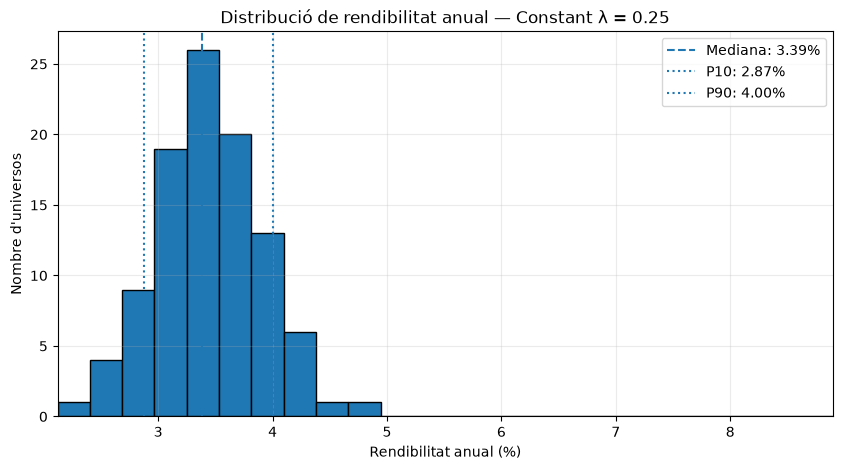

In [163]:
df_grafic = resultats_distribucio[
    resultats_distribucio["Model"]
    == "Constant_025"
]

r = (
    100
    * df_grafic["Rendibilitat_Anual"]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    r,
    bins=bins_comuns,
    edgecolor="black"
)

plt.axvline(
    r.median(),
    linestyle="--",
    label=f"Mediana: {r.median():.2f}%"
)

plt.axvline(
    r.quantile(0.10),
    linestyle=":",
    label=f"P10: {r.quantile(0.10):.2f}%"
)

plt.axvline(
    r.quantile(0.90),
    linestyle=":",
    label=f"P90: {r.quantile(0.90):.2f}%"
)

plt.xlim(
    x_min,
    x_max
)

plt.title(
    "Distribució de rendibilitat anual — Constant λ = 0.25"
)

plt.xlabel(
    "Rendibilitat anual (%)"
)

plt.ylabel(
    "Nombre d'universos"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

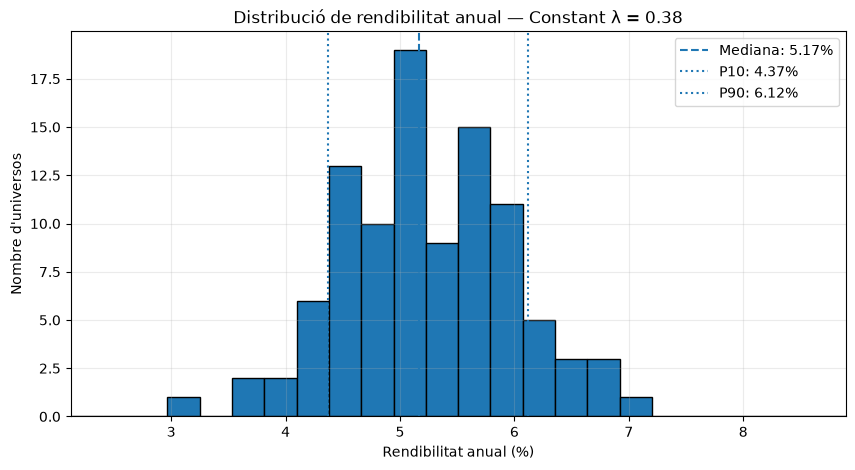

In [164]:
df_grafic = resultats_distribucio[
    resultats_distribucio["Model"]
    == "Constant_038"
]

r = (
    100
    * df_grafic["Rendibilitat_Anual"]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    r,
    bins=bins_comuns,
    edgecolor="black"
)

plt.axvline(
    r.median(),
    linestyle="--",
    label=f"Mediana: {r.median():.2f}%"
)

plt.axvline(
    r.quantile(0.10),
    linestyle=":",
    label=f"P10: {r.quantile(0.10):.2f}%"
)

plt.axvline(
    r.quantile(0.90),
    linestyle=":",
    label=f"P90: {r.quantile(0.90):.2f}%"
)

plt.xlim(
    x_min,
    x_max
)

plt.title(
    "Distribució de rendibilitat anual — Constant λ = 0.38"
)

plt.xlabel(
    "Rendibilitat anual (%)"
)

plt.ylabel(
    "Nombre d'universos"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

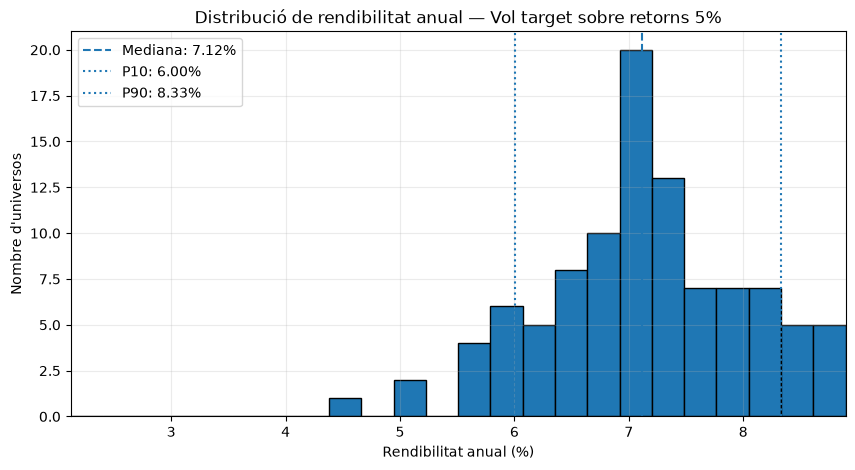

In [165]:
df_grafic = resultats_distribucio[
    resultats_distribucio["Model"]
    == "VolTargetRetorns_5"
]

r = (
    100
    * df_grafic["Rendibilitat_Anual"]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    r,
    bins=bins_comuns,
    edgecolor="black"
)

plt.axvline(
    r.median(),
    linestyle="--",
    label=f"Mediana: {r.median():.2f}%"
)

plt.axvline(
    r.quantile(0.10),
    linestyle=":",
    label=f"P10: {r.quantile(0.10):.2f}%"
)

plt.axvline(
    r.quantile(0.90),
    linestyle=":",
    label=f"P90: {r.quantile(0.90):.2f}%"
)

plt.xlim(
    x_min,
    x_max
)

plt.title(
    "Distribució de rendibilitat anual — Vol target sobre retorns 5%"
)

plt.xlabel(
    "Rendibilitat anual (%)"
)

plt.ylabel(
    "Nombre d'universos"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

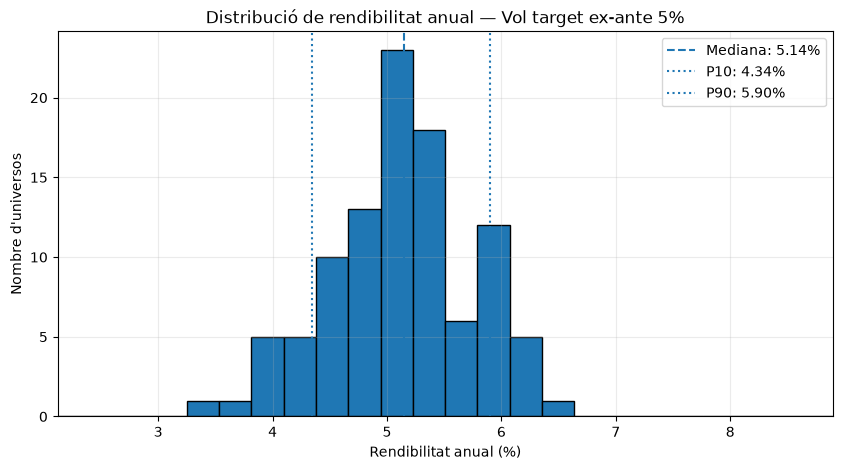

In [166]:
df_grafic = resultats_distribucio[
    resultats_distribucio["Model"]
    == "ExAnte_5"
]

r = (
    100
    * df_grafic["Rendibilitat_Anual"]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    r,
    bins=bins_comuns,
    edgecolor="black"
)

plt.axvline(
    r.median(),
    linestyle="--",
    label=f"Mediana: {r.median():.2f}%"
)

plt.axvline(
    r.quantile(0.10),
    linestyle=":",
    label=f"P10: {r.quantile(0.10):.2f}%"
)

plt.axvline(
    r.quantile(0.90),
    linestyle=":",
    label=f"P90: {r.quantile(0.90):.2f}%"
)

plt.xlim(
    x_min,
    x_max
)

plt.title(
    "Distribució de rendibilitat anual — Vol target ex-ante 5%"
)

plt.xlabel(
    "Rendibilitat anual (%)"
)

plt.ylabel(
    "Nombre d'universos"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

### 10.4.1. Comparació visual dels quatre models

Representem les quatre distribucions en una mateixa figura.

Tots els gràfics comparteixen:

- els mateixos 100 universos;
- els mateixos intervals de l'histograma;
- la mateixa escala de rendibilitat;
- la mediana i els percentils 10 i 90.

Això permet comparar directament el centre, la dispersió i les cues de cada distribució.

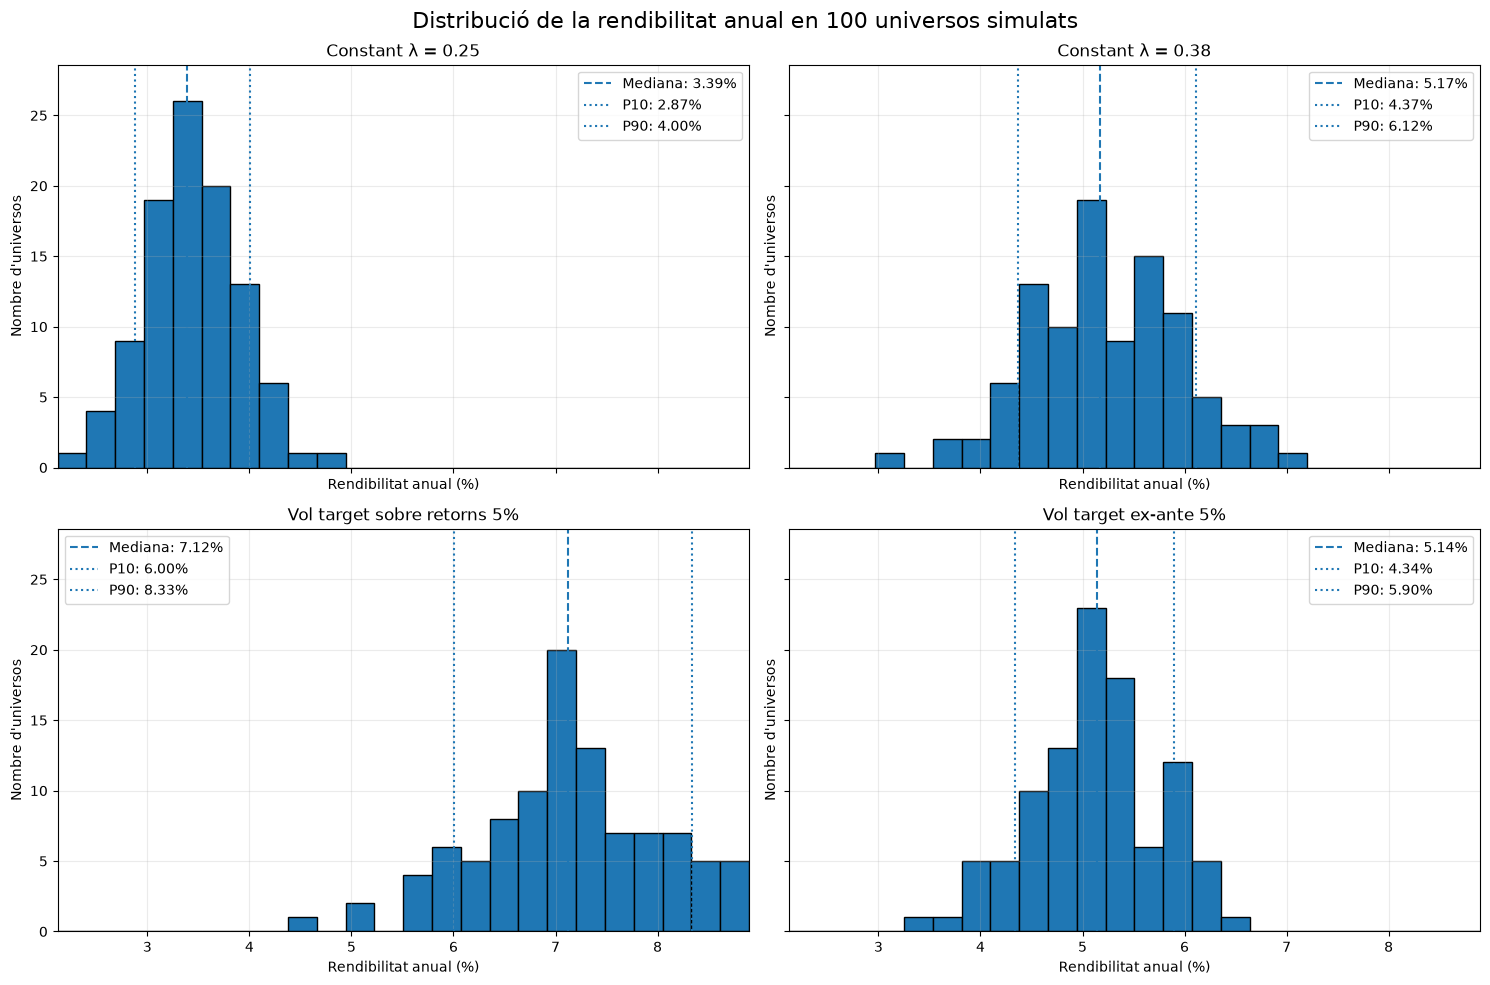

In [167]:
# ==========================================
# 4 DISTRIBUCIONS EN UNA MATEIXA FIGURA
# ==========================================

models_grafic = [
    (
        "Constant_025",
        "Constant λ = 0.25"
    ),
    (
        "Constant_038",
        "Constant λ = 0.38"
    ),
    (
        "VolTargetRetorns_5",
        "Vol target sobre retorns 5%"
    ),
    (
        "ExAnte_5",
        "Vol target ex-ante 5%"
    )
]


# ==========================================
# ESCALA COMUNA
# ==========================================

tots_rendiments = (
    100
    * resultats_distribucio[
        "Rendibilitat_Anual"
    ]
)

x_min = tots_rendiments.min()
x_max = tots_rendiments.max()

bins_comuns = np.linspace(
    x_min,
    x_max,
    25
)


# Mateix límit vertical per als 4 histogrames
max_frequencia = 0

for model, _ in models_grafic:

    rendiments = (
        100
        * resultats_distribucio.loc[
            resultats_distribucio["Model"] == model,
            "Rendibilitat_Anual"
        ]
    )

    frequencies, _ = np.histogram(
        rendiments,
        bins=bins_comuns
    )

    max_frequencia = max(
        max_frequencia,
        frequencies.max()
    )


# ==========================================
# FIGURA 2 x 2
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


for ax, (
    model,
    titol
) in zip(
    axes,
    models_grafic
):

    rendiments = (
        100
        * resultats_distribucio.loc[
            resultats_distribucio["Model"] == model,
            "Rendibilitat_Anual"
        ]
    )

    mediana = rendiments.median()
    p10 = rendiments.quantile(0.10)
    p90 = rendiments.quantile(0.90)


    ax.hist(
        rendiments,
        bins=bins_comuns,
        edgecolor="black"
    )


    ax.axvline(
        mediana,
        linestyle="--",
        label=f"Mediana: {mediana:.2f}%"
    )

    ax.axvline(
        p10,
        linestyle=":",
        label=f"P10: {p10:.2f}%"
    )

    ax.axvline(
        p90,
        linestyle=":",
        label=f"P90: {p90:.2f}%"
    )


    ax.set_title(
        titol
    )

    ax.set_xlim(
        x_min,
        x_max
    )

    ax.set_ylim(
        0,
        max_frequencia * 1.10
    )

    ax.set_xlabel(
        "Rendibilitat anual (%)"
    )

    ax.set_ylabel(
        "Nombre d'universos"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()


fig.suptitle(
    "Distribució de la rendibilitat anual en 100 universos simulats",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [168]:
# ==========================================
# COMPARACIÓ COMPLETA DELS 4 MODELS
# SOBRE ELS MATEIXOS 100 UNIVERSOS
# ==========================================

resum_complet_distribucio = []


for model in models_distribucio:

    df = resultats_distribucio[
        resultats_distribucio["Model"]
        == model
    ]


    fila = {

        "Model":
            model,

        "Rend_Anual_Mediana":
            df["Rendibilitat_Anual"].median(),

        "Rend_Anual_P10":
            df["Rendibilitat_Anual"].quantile(0.10),

        "Vol_Anual_Mediana":
            df["Volatilitat_Anual"].median(),

        "Sharpe_Mediana":
            df["Sharpe"].median(),

        "DD_Mediana":
            df["Max_Drawdown"].median(),

        "DD_P10":
            df["Max_Drawdown"].quantile(0.10),

        "Prob_DD_20":
            (
                df["Max_Drawdown"]
                <= -0.20
            ).mean(),

        "Turnover_Mediana":
            df["Turnover_Total"].median()
    }


    if "Exposicio_Mitjana" in df.columns:

        fila["Exposicio_Mitjana"] = (
            df["Exposicio_Mitjana"]
            .median()
        )

    else:

        if model == "Constant_025":
            fila["Exposicio_Mitjana"] = 0.25

        elif model == "Constant_038":
            fila["Exposicio_Mitjana"] = 0.38

        else:
            fila["Exposicio_Mitjana"] = np.nan


    resum_complet_distribucio.append(
        fila
    )


resum_complet_distribucio = pd.DataFrame(
    resum_complet_distribucio
)

resum_complet_distribucio

,Model,Rend_Anual_Mediana,Rend_Anual_P10,Vol_Anual_Mediana,Sharpe_Mediana,DD_Mediana,DD_P10,Prob_DD_20,Turnover_Mediana,Exposicio_Mitjana
0,Constant_025,0.033864,0.028748,0.027269,1.256184,-0.060825,-0.110360,0.00,234.366081,NaN
1,Constant_038,0.051666,0.043689,0.041449,1.256184,-0.091781,-0.165160,0.06,356.236443,NaN
2,VolTargetRetorns_5,0.071194,0.060023,0.057919,1.197055,-0.129641,-0.220866,0.13,597.957957,0.525974
3,ExAnte_5,0.051447,0.043433,0.039256,1.279877,-0.083168,-0.143042,0.04,379.637132,0.370414


### 10.5. Conclusions de la comparació dels quatre models

Els resultats mostren que una major rendibilitat no implica necessàriament una major eficiència.

El volatility targeting sobre retorns obté la rendibilitat més alta, però també manté una exposició mitjana superior, més volatilitat, més drawdown i més turnover.

En canvi, el sizing constant amb $\lambda=0.38$ i el volatility targeting ex-ante del 5% presenten una exposició similar.

Entre aquests dos models, l'ex-ante manté pràcticament la mateixa rendibilitat, però presenta una volatilitat i uns drawdowns lleugerament inferiors.

Per tant, els quatre models es mantindran per als stress tests:

- Constant $\lambda=0.25$: perfil prudent.
- Constant $\lambda=0.38$: model simple de referència.
- Vol target sobre retorns 5%: model dinàmic més agressiu.
- Vol target ex-ante 5%: model dinàmic orientat al control del risc.

## 11. Stress tests

Fins ara hem validat els models sobre moltes realitzacions diferents del mateix procés generador.

Ara modificarem l'estructura del mercat per comprovar què passa quan les hipòtesis del simulador deixen de complir-se.

Estudiarem quatre escenaris adversos:

1. **Fat tails:** shocks extrems més freqüents que sota una distribució normal.
2. **Volatility clustering:** períodes persistents de volatilitat elevada.
3. **Jumps intensos:** salts del spread i del beta més freqüents i més grans.
4. **Trencament prolongat de la relació:** períodes en què la mean reversion pràcticament desapareix.

Compararem els quatre models finals sobre les mateixes seeds.

Utilitzarem només 50 mercats per escenari:

$$
4\ models
\times
4\ escenaris
\times
50\ seeds
=
800\ backtests.
$$

L'objectiu no és tornar a optimitzar, sinó estudiar quins models degraden de manera més controlada quan el món és diferent del que hem assumit.

In [169]:
# ==========================================
# ESCENARIS DE STRESS
# ==========================================

escenaris_stress = {
    
    "Fat_Tails": {
        "descripcio":
            "Soroll amb cues gruixudes"
    },

    "Vol_Clustering": {
        "descripcio":
            "Periodes persistents de volatilitat alta"
    },

    "Jumps_Intensos": {
        "descripcio":
            "Salts del spread i beta mes frequents"
    },

    "Trencament_Relacio": {
        "descripcio":
            "Mean reversion gairebe nul·la durant periodes llargs"
    }
}

escenaris_stress

{'Fat_Tails': {'descripcio': 'Soroll amb cues gruixudes'},
 'Vol_Clustering': {'descripcio': 'Periodes persistents de volatilitat alta'},
 'Jumps_Intensos': {'descripcio': 'Salts del spread i beta mes frequents'},
 'Trencament_Relacio': {'descripcio': 'Mean reversion gairebe nul·la durant periodes llargs'}}

### 11.1. Construcció dels escenaris adversos

Mantindrem congelat el senyal agressiu:

$$
Finestra_Z=120,\qquad
Z_{entrada}=1.25,\qquad
Z_{sortida}=0,\qquad
Q_\beta=0.002^2.
$$

Només modificarem el procés generador del mercat.

Els quatre stress tests seran:

**Fat tails**

Substituirem part del soroll normal per una distribució $t$ de Student, que genera observacions extremes amb més freqüència.

**Volatility clustering**

Introduirem règims persistents de volatilitat elevada. Quan el mercat entra en un règim turbulent, la volatilitat es manté alta durant diversos passos.

**Jumps intensos**

Augmentarem la freqüència i la magnitud dels salts tant del spread com del beta.

**Trencament prolongat de la relació**

Introduirem períodes llargs durant els quals la força de mean reversion pràcticament desapareix i la volatilitat del spread augmenta.

L'objectiu no és construir una representació perfecta dels mercats reals, sinó comprovar com degraden els models quan les hipòtesis favorables del simulador deixen de complir-se.

In [170]:
def simular_pairs_trading_stress(
    seed,
    escenari,
    model,
    n_passos=15_000,
    cost_transaccio=0.001,
    capital_inicial=10_000
):

    rng = np.random.default_rng(seed)

    # ==========================================
    # SENYAL CONGELAT
    # ==========================================

    finestra_z = 120
    z_entrada = 1.25
    z_sortida = 0.0
    q_beta = 0.002**2


    # ==========================================
    # PARÀMETRES BASE DEL MERCAT
    # ==========================================

    mu_mercat = 0.0003
    sigma_mercat = 0.01

    kappa_max = 0.08

    sigma_spread_min = 0.015
    sigma_spread_max = 0.025

    prob_canvi_equilibri = 0.002
    sigma_canvi_equilibri = 0.05

    persistencia_deteriorament = 0.97
    sigma_deteriorament = 0.01

    prob_xoc_relacio = 0.003
    xoc_relacio_min = 0.20
    xoc_relacio_max = 0.60

    prob_salt_spread = 0.001
    sigma_salt_spread = 0.08

    beta_inicial = 1.0
    sigma_canvi_beta = 0.0015

    prob_salt_beta = 0.0015
    sigma_salt_beta = 0.08

    beta_min = 0.6
    beta_max = 1.4


    # ==========================================
    # MODIFICACIÓ: JUMPS INTENSOS
    # ==========================================

    if escenari == "Jumps_Intensos":

        prob_salt_spread = 0.004
        sigma_salt_spread = 0.14

        prob_salt_beta = 0.004
        sigma_salt_beta = 0.14


    # ==========================================
    # DETERIORAMENT BASE
    # ==========================================

    deteriorament = np.zeros(n_passos)

    for t in range(1, n_passos):

        deteriorament[t] = (
            persistencia_deteriorament
            * deteriorament[t - 1]
            + rng.normal(
                0,
                sigma_deteriorament
            )
        )

        if rng.random() < prob_xoc_relacio:

            deteriorament[t] += rng.uniform(
                xoc_relacio_min,
                xoc_relacio_max
            )

        deteriorament[t] = np.clip(
            deteriorament[t],
            0,
            1
        )


    kappa_dinamic = (
        kappa_max
        * (1 - deteriorament)
    )

    sigma_spread_dinamic = (
        sigma_spread_min
        + deteriorament
        * (
            sigma_spread_max
            - sigma_spread_min
        )
    )


    # ==========================================
    # VOLATILITY CLUSTERING
    # ==========================================

    multiplicador_vol = np.ones(
        n_passos
    )

    if escenari == "Vol_Clustering":

        estat_vol_alta = False

        prob_entrada_vol_alta = 0.002
        prob_sortida_vol_alta = 0.03

        for t in range(1, n_passos):

            if not estat_vol_alta:

                if (
                    rng.random()
                    < prob_entrada_vol_alta
                ):
                    estat_vol_alta = True

            else:

                if (
                    rng.random()
                    < prob_sortida_vol_alta
                ):
                    estat_vol_alta = False


            if estat_vol_alta:

                multiplicador_vol[t] = 2.5


    # ==========================================
    # TRENCAMENT PROLONGAT DE LA RELACIÓ
    # ==========================================

    trencament = np.zeros(
        n_passos,
        dtype=bool
    )

    if escenari == "Trencament_Relacio":

        relacio_trencada = False

        prob_entrada_trencament = 0.0005
        prob_sortida_trencament = 0.005

        for t in range(1, n_passos):

            if not relacio_trencada:

                if (
                    rng.random()
                    < prob_entrada_trencament
                ):
                    relacio_trencada = True

            else:

                if (
                    rng.random()
                    < prob_sortida_trencament
                ):
                    relacio_trencada = False


            trencament[t] = (
                relacio_trencada
            )


        # Mean reversion gairebé nul·la
        kappa_dinamic[
            trencament
        ] *= 0.05


        # Spread més inestable
        sigma_spread_dinamic[
            trencament
        ] *= 1.50


    # ==========================================
    # EQUILIBRI DEL SPREAD
    # ==========================================

    equilibri_spread = np.zeros(
        n_passos
    )

    equilibri_actual = 0.0

    for t in range(
        1,
        n_passos
    ):

        if (
            rng.random()
            < prob_canvi_equilibri
        ):

            equilibri_actual += rng.normal(
                0,
                sigma_canvi_equilibri
            )

        equilibri_spread[t] = (
            equilibri_actual
        )


    # ==========================================
    # SPREAD REAL
    # ==========================================

    spread_real = np.zeros(
        n_passos
    )


    for t in range(
        1,
        n_passos
    ):

        sigma_actual = (
            sigma_spread_dinamic[t]
            * multiplicador_vol[t]
        )


        # --------------------------------------
        # FAT TAILS
        # --------------------------------------

        if escenari == "Fat_Tails":

            graus_llibertat = 4

            escala_t = np.sqrt(
                (
                    graus_llibertat
                    - 2
                )
                / graus_llibertat
            )

            soroll = (
                sigma_actual
                * escala_t
                * rng.standard_t(
                    graus_llibertat
                )
            )

        else:

            soroll = rng.normal(
                0,
                sigma_actual
            )


        salt = 0.0

        if (
            rng.random()
            < prob_salt_spread
        ):

            salt = rng.normal(
                0,
                sigma_salt_spread
            )


        spread_real[t] = (
            spread_real[t - 1]
            + kappa_dinamic[t]
            * (
                equilibri_spread[t]
                - spread_real[t - 1]
            )
            + soroll
            + salt
        )


    # ==========================================
    # BETA REAL
    # ==========================================

    beta_real = np.zeros(
        n_passos
    )

    beta_real[0] = beta_inicial


    for t in range(
        1,
        n_passos
    ):

        canvi_beta = rng.normal(
            0,
            sigma_canvi_beta
        )


        if (
            rng.random()
            < prob_salt_beta
        ):

            canvi_beta += rng.normal(
                0,
                sigma_salt_beta
            )


        beta_real[t] = np.clip(
            beta_real[t - 1]
            + canvi_beta,
            beta_min,
            beta_max
        )


    # ==========================================
    # FACTOR COMÚ
    # ==========================================

    if escenari == "Fat_Tails":

        graus_llibertat = 4

        escala_t = np.sqrt(
            (
                graus_llibertat
                - 2
            )
            / graus_llibertat
        )

        retorns_mercat = (
            mu_mercat
            + sigma_mercat
            * escala_t
            * rng.standard_t(
                graus_llibertat,
                n_passos
            )
        )

    else:

        retorns_mercat = rng.normal(
            mu_mercat,
            sigma_mercat,
            n_passos
        )


    # Clustering també afecta
    # el factor de mercat
    retorns_mercat = (
        mu_mercat
        + (
            retorns_mercat
            - mu_mercat
        )
        * multiplicador_vol
    )


    log_B = np.cumsum(
        retorns_mercat
    )

    log_A = (
        beta_real * log_B
        + spread_real
    )


    preu_B = (
        100
        * np.exp(log_B)
    )

    preu_A = (
        100
        * np.exp(log_A)
    )


    # ==========================================
    # KALMAN
    # ==========================================

    phi_spread = 0.92

    q_alpha = 0.003**2
    q_spread = 0.015**2

    r_observacio = 0.005**2


    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, phi_spread]
    ])


    Q = np.diag([
        q_alpha,
        q_beta,
        q_spread
    ])


    estat = np.array([
        0.0,
        1.0,
        0.0
    ])

    P = np.eye(3)


    beta_kalman = np.zeros(
        n_passos
    )

    spread_kalman = np.zeros(
        n_passos
    )


    for t in range(
        n_passos
    ):

        estat_pred = (
            F @ estat
        )

        P_pred = (
            F @ P @ F.T
            + Q
        )


        H = np.array([
            1.0,
            log_B[t],
            1.0
        ])


        innovacio = (
            log_A[t]
            - H @ estat_pred
        )


        variancia_innovacio = (
            H @ P_pred @ H.T
            + r_observacio
        )


        K = (
            P_pred @ H.T
            / variancia_innovacio
        )


        estat = (
            estat_pred
            + K * innovacio
        )


        I = np.eye(3)

        KH = np.outer(
            K,
            H
        )


        P = (
            (I - KH)
            @ P_pred
            @ (I - KH).T
            + np.outer(K, K)
            * r_observacio
        )


        beta_kalman[t] = estat[1]
        spread_kalman[t] = estat[2]


    # ==========================================
    # Z-SCORE
    # ==========================================

    serie_spread = pd.Series(
        spread_kalman
    )


    mitjana = (
        serie_spread
        .rolling(
            finestra_z
        )
        .mean()
        .to_numpy()
    )


    desviacio = (
        serie_spread
        .rolling(
            finestra_z
        )
        .std()
        .to_numpy()
    )


    z = (
        spread_kalman
        - mitjana
    ) / desviacio


    # ==========================================
    # SENYALS
    # ==========================================

    senyal = np.zeros(
        n_passos
    )

    posicio_actual = 0


    for t in range(
        n_passos
    ):

        if np.isnan(z[t]):

            senyal[t] = (
                posicio_actual
            )

            continue


        if posicio_actual == 0:

            if z[t] > z_entrada:

                posicio_actual = -1

            elif z[t] < -z_entrada:

                posicio_actual = 1


        elif posicio_actual == 1:

            if (
                z[t]
                >= -z_sortida
            ):

                posicio_actual = 0


        elif posicio_actual == -1:

            if (
                z[t]
                <= z_sortida
            ):

                posicio_actual = 0


        senyal[t] = (
            posicio_actual
        )


    # ==========================================
    # EXECUCIÓ
    # ==========================================

    posicio = np.roll(
        senyal,
        1
    )

    posicio[0] = 0


    beta_trading = np.roll(
        beta_kalman,
        1
    )

    beta_trading[0] = np.nan


    # ==========================================
    # PESOS BASE
    # ==========================================

    beta_abs = np.abs(
        beta_trading
    )


    pes_A_base = (
        posicio
        / (1 + beta_abs)
    )


    pes_B_base = (
        -posicio
        * beta_trading
        / (1 + beta_abs)
    )


    pes_A_base = np.nan_to_num(
        pes_A_base
    )

    pes_B_base = np.nan_to_num(
        pes_B_base
    )


    # ==========================================
    # RETORNS DELS ACTIUS
    # ==========================================

    retorn_A = np.zeros(
        n_passos
    )

    retorn_B = np.zeros(
        n_passos
    )


    retorn_A[1:] = (
        preu_A[1:]
        / preu_A[:-1]
        - 1
    )


    retorn_B[1:] = (
        preu_B[1:]
        / preu_B[:-1]
        - 1
    )


    # ==========================================
    # MODEL DE POSITION SIZING
    # ==========================================

    lambda_t = np.zeros(
        n_passos
    )


    # ------------------------------------------
    # CONSTANT 25%
    # ------------------------------------------

    if model == "Constant_025":

        lambda_t[
            posicio != 0
        ] = 0.25


    # ------------------------------------------
    # CONSTANT 38%
    # ------------------------------------------

    elif model == "Constant_038":

        lambda_t[
            posicio != 0
        ] = 0.38


    # ------------------------------------------
    # VOL TARGET SOBRE RETORNS
    # ------------------------------------------

    elif model == "VolTargetRetorns_5":

        retorn_base = (
            pes_A_base * retorn_A
            + pes_B_base * retorn_B
        )


        volatilitat_estimada = (
            pd.Series(
                retorn_base
            )
            .rolling(
                60,
                min_periods=20
            )
            .std()
            .shift(1)
            * np.sqrt(252)
        ).to_numpy()


        valid = (
            np.isfinite(
                volatilitat_estimada
            )
            &
            (
                volatilitat_estimada
                > 0
            )
        )


        lambda_t[valid] = (
            0.05
            / volatilitat_estimada[valid]
        )


        lambda_t = np.clip(
            lambda_t,
            0,
            1
        )


    # ------------------------------------------
    # VOL TARGET EX-ANTE
    # ------------------------------------------

    elif model == "ExAnte_5":

        serie_A = pd.Series(
            retorn_A
        )

        serie_B = pd.Series(
            retorn_B
        )


        var_A = (
            serie_A
            .rolling(
                60,
                min_periods=20
            )
            .var()
            .shift(1)
            .to_numpy()
        )


        var_B = (
            serie_B
            .rolling(
                60,
                min_periods=20
            )
            .var()
            .shift(1)
            .to_numpy()
        )


        cov_AB = (
            serie_A
            .rolling(
                60,
                min_periods=20
            )
            .cov(
                serie_B
            )
            .shift(1)
            .to_numpy()
        )


        variancia_cartera = (
            pes_A_base**2
            * var_A

            + pes_B_base**2
            * var_B

            + 2
            * pes_A_base
            * pes_B_base
            * cov_AB
        )


        variancia_cartera = np.maximum(
            variancia_cartera,
            0
        )


        volatilitat_ex_ante = (
            np.sqrt(
                variancia_cartera
            )
            * np.sqrt(252)
        )


        valid = (
            np.isfinite(
                volatilitat_ex_ante
            )
            &
            (
                volatilitat_ex_ante
                > 0
            )
        )


        lambda_t[valid] = (
            0.05
            / volatilitat_ex_ante[valid]
        )


        lambda_t = np.clip(
            lambda_t,
            0,
            1
        )


    else:

        raise ValueError(
            "Model desconegut."
        )


    # Assegurem exposició zero
    # quan no hi ha posició
    lambda_t[
        posicio == 0
    ] = 0


    # ==========================================
    # PESOS FINALS
    # ==========================================

    pes_A = (
        lambda_t
        * pes_A_base
    )

    pes_B = (
        lambda_t
        * pes_B_base
    )


    # ==========================================
    # TURNOVER I COSTOS
    # ==========================================

    turnover = np.zeros(
        n_passos
    )


    turnover[1:] = (
        np.abs(
            pes_A[1:]
            - pes_A[:-1]
        )
        +
        np.abs(
            pes_B[1:]
            - pes_B[:-1]
        )
    )


    costos = (
        cost_transaccio
        * turnover
    )


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )


    retorn_net = (
        retorn_brut
        - costos
    )


    # ==========================================
    # CAPITAL I RUÏNA
    # ==========================================

    capital = np.zeros(
        n_passos
    )

    capital[0] = (
        capital_inicial
    )

    ruina = False


    for t in range(
        1,
        n_passos
    ):

        factor = (
            1
            + retorn_net[t]
        )


        if factor <= 0:

            capital[t:] = 0

            ruina = True

            break


        capital[t] = (
            capital[t - 1]
            * factor
        )


    # ==========================================
    # DRAWDOWN
    # ==========================================

    if ruina:

        max_drawdown = -1.0

        rendibilitat_anual = -1.0

    else:

        maxim_acumulat = (
            np.maximum.accumulate(
                capital
            )
        )


        drawdown = (
            capital
            / maxim_acumulat
            - 1
        )


        max_drawdown = (
            np.min(drawdown)
        )


        rendibilitat_anual = (
            (
                capital[-1]
                / capital_inicial
            )
            ** (
                252
                / n_passos
            )
            - 1
        )


    # ==========================================
    # VOLATILITAT I SHARPE
    # ==========================================

    volatilitat_anual = (
        np.std(
            retorn_net,
            ddof=1
        )
        * np.sqrt(252)
    )


    std_retorn = np.std(
        retorn_net,
        ddof=1
    )


    if std_retorn > 0:

        sharpe = (
            np.mean(
                retorn_net
            )
            / std_retorn
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    # ==========================================
    # EXPOSICIÓ
    # ==========================================

    lambda_activa = (
        lambda_t[
            posicio != 0
        ]
    )


    if len(
        lambda_activa
    ) > 0:

        exposicio_mitjana = (
            np.mean(
                lambda_activa
            )
        )

    else:

        exposicio_mitjana = 0.0


    # ==========================================
    # RESULTAT
    # ==========================================

    return {

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Turnover_Total":
            np.sum(turnover),

        "Exposicio_Mitjana":
            exposicio_mitjana,

        "Ruina":
            ruina,

        "Frac_Trencament":
            np.mean(trencament),

        "Frac_Vol_Alta":
            np.mean(
                multiplicador_vol > 1
            )
    }

In [171]:
# ==========================================
# EXECUCIÓ DELS STRESS TESTS
# ==========================================

models_stress = [
    "Constant_025",
    "Constant_038",
    "VolTargetRetorns_5",
    "ExAnte_5"
]


escenaris_stress = [
    "Fat_Tails",
    "Vol_Clustering",
    "Jumps_Intensos",
    "Trencament_Relacio"
]


seeds_stress = [
    120_000 + i
    for i in range(50)
]


total_backtests = (
    len(models_stress)
    * len(escenaris_stress)
    * len(seeds_stress)
)


resultats_stress = []

comptador = 0


for escenari in escenaris_stress:

    for seed in seeds_stress:

        for model in models_stress:

            resultat = (
                simular_pairs_trading_stress(
                    seed=seed,
                    escenari=escenari,
                    model=model
                )
            )


            resultats_stress.append({

                "Escenari":
                    escenari,

                "Model":
                    model,

                "Seed":
                    seed,

                **resultat
            })


            comptador += 1

            percentatge = (
                comptador
                / total_backtests
                * 100
            )


            print(
                f"\rStress tests: "
                f"{percentatge:.1f}% "
                f"({comptador}/{total_backtests})",
                end=""
            )


    # Checkpoint després de cada escenari
    pd.DataFrame(
        resultats_stress
    ).to_csv(
        "checkpoint_stress_tests.csv",
        index=False
    )


resultats_stress = pd.DataFrame(
    resultats_stress
)

print(
    "\nStress tests completats!"
)

Stress tests: 100.0% (800/800)
Stress tests completats!


### 11.2. Resum dels stress tests

Per cada combinació de model i escenari estudiarem:

- rendibilitat mediana;
- rendibilitat en el percentil 10;
- Sharpe medià;
- drawdown medià;
- drawdown en el percentil 10;
- probabilitat de drawdown superior al 20%, 30% i 50%;
- taxa de ruïna;
- exposició i turnover.

En aquesta etapa no busquem el model amb més rendibilitat absoluta.

Ens interessa especialment la **degradació**:

$$
\text{comportament normal}
\longrightarrow
\text{comportament sota stress}.
$$

Un model robust és aquell que continua funcionant de manera raonable quan les hipòtesis del mercat es tornen menys favorables.

In [172]:
# ==========================================
# RESUM DELS STRESS TESTS
# ==========================================

resum_stress = []


for escenari in escenaris_stress:

    for model in models_stress:

        df = resultats_stress[
            (
                resultats_stress["Escenari"]
                == escenari
            )
            &
            (
                resultats_stress["Model"]
                == model
            )
        ]


        resum_stress.append({

            "Escenari":
                escenari,

            "Model":
                model,

            "Rend_Anual_Mediana":
                df[
                    "Rendibilitat_Anual"
                ].median(),

            "Rend_Anual_P10":
                df[
                    "Rendibilitat_Anual"
                ].quantile(0.10),

            "Vol_Anual_Mediana":
                df[
                    "Volatilitat_Anual"
                ].median(),

            "Sharpe_Mediana":
                df[
                    "Sharpe"
                ].median(),

            "DD_Mediana":
                df[
                    "Max_Drawdown"
                ].median(),

            "DD_P10":
                df[
                    "Max_Drawdown"
                ].quantile(0.10),

            "DD_Pitjor":
                df[
                    "Max_Drawdown"
                ].min(),

            "Prob_DD_20":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.20
                ).mean(),

            "Prob_DD_30":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.30
                ).mean(),

            "Prob_DD_50":
                (
                    df[
                        "Max_Drawdown"
                    ] <= -0.50
                ).mean(),

            "Taxa_Ruina":
                df[
                    "Ruina"
                ].mean(),

            "Exposicio_Mitjana":
                df[
                    "Exposicio_Mitjana"
                ].median(),

            "Turnover_Mediana":
                df[
                    "Turnover_Total"
                ].median()
        })


resum_stress = pd.DataFrame(
    resum_stress
)

resum_stress

,Escenari,Model,Rend_Anual_Mediana,Rend_Anual_P10,Vol_Anual_Mediana,Sharpe_Mediana,DD_Mediana,DD_P10,DD_Pitjor,Prob_DD_20,Prob_DD_30,Prob_DD_50,Taxa_Ruina,Exposicio_Mitjana,Turnover_Mediana
0,Fat_Tails,Constant_025,0.034643,0.029192,0.026099,1.349933,-0.046188,-0.087061,-0.168002,0.00,0.00,0.00,0.00,0.250000,220.079481
1,Fat_Tails,Constant_038,0.052841,0.044497,0.039670,1.349933,-0.069735,-0.131008,-0.249850,0.02,0.00,0.00,0.00,0.380000,334.520812
2,Fat_Tails,VolTargetRetorns_5,0.074921,0.062029,0.059759,1.250703,-0.103516,-0.197765,-0.452024,0.10,0.02,0.00,0.00,0.561809,600.267984
3,Fat_Tails,ExAnte_5,0.053027,0.045232,0.040281,1.293718,-0.072961,-0.118353,-0.237485,0.02,0.00,0.00,0.00,0.384871,378.030828
4,Vol_Clustering,Constant_025,0.041080,0.032494,0.031167,1.303009,-0.053871,-0.097097,-0.185232,0.00,0.00,0.00,0.00,0.250000,235.537060
5,Vol_Clustering,Constant_038,0.062662,0.049521,0.047374,1.303009,-0.081311,-0.146330,-0.280781,0.04,0.00,0.00,0.00,0.380000,358.016332
6,Vol_Clustering,VolTargetRetorns_5,0.073134,0.062940,0.058772,1.207796,-0.106197,-0.191101,-0.372179,0.10,0.08,0.00,0.00,0.500393,563.963219
7,Vol_Clustering,ExAnte_5,0.053272,0.044631,0.039910,1.300767,-0.070407,-0.116970,-0.260790,0.02,0.00,0.00,0.00,0.352833,355.734333
8,Jumps_Intensos,Constant_025,0.033705,0.022513,0.042157,0.867914,-0.129756,-0.353205,-1.000000,0.26,0.12,0.04,0.02,0.250000,194.675938
9,Jumps_Intensos,Constant_038,0.050598,0.033393,0.064078,0.867914,-0.194756,-0.504166,-1.000000,0.48,0.26,0.12,0.04,0.380000,295.907426


### 11.3. Conclusions dels stress tests

Els stress tests mostren que no totes les formes de volatilitat són igualment perjudicials per a una estratègia de mean reversion.

Els fat tails i el volatility clustering poden generar més desviacions explotables sempre que la relació entre els actius continuï revertint.

Els riscos més importants són:

$$
\text{jumps inesperats}
$$

i:

$$
\text{trencaments prolongats de la relació}.
$$

Els jumps són especialment perillosos perquè els models de volatility targeting utilitzen informació passada i no poden reduir l'exposició abans d'un moviment completament inesperat.

El volatility targeting ex-ante ofereix el millor compromís general. Manté una rendibilitat similar al sizing constant moderat, però redueix els drawdowns sota volatility clustering i, especialment, quan la relació deixa de revertir temporalment.

El sizing constant amb $\lambda=0.25$ és el model més resistent i senzill. Sacrifica rendibilitat, però presenta la millor protecció davant d'escenaris amb jumps intensos.

El volatility targeting sobre retorns genera la rendibilitat més alta, però també és el model més fràgil davant dels moviments extrems.

Per tant, els dos models principals són:

1. **ExAnte 5%**, com a model dinàmic principal.
2. **Constant $\lambda=0.25$**, com a benchmark prudent i robust.

## 12. Conclusions finals

Hem construït una estratègia completa de **pairs trading amb mean reversion** partint d'un mercat simulat.

La relació entre els dos actius s'ha modelitzat com:

$$
\log(A_t)
=
\alpha_t
+
\beta_t \log(B_t)
+
S_t,
$$

on $\beta_t$ i el spread $S_t$ poden evolucionar en el temps.

Per estimar aquesta relació utilitzem un **filtre de Kalman**, evitant assumir que el hedge ratio és constant.

A partir del spread estimat construïm un z-score:

$$
Z_t
=
\frac{
S_t-\mu_{S,t}
}{
\sigma_{S,t}
},
$$

que genera els senyals d'entrada i sortida de l'estratègia.

Durant el desenvolupament s'han incorporat:

- execució retardada per evitar lookahead;
- hedge ratio dinàmic;
- costos de transacció;
- turnover;
- drawdowns;
- anàlisi individual de trades;
- optimització sobre múltiples universos;
- validació out-of-sample;
- position sizing;
- volatility targeting;
- stress tests.

### Resultat principal

L'estratègia presenta una regió robusta de paràmetres, no simplement un únic punt òptim.

El senyal agressiu seleccionat és:

$$
Finestra_Z=120,
$$

$$
Z_{entrada}=1.25,
$$

$$
Z_{sortida}=0,
$$

$$
Q_\beta=0.002^2.
$$

La comparació dels diferents sistemes de position sizing mostra que una major rendibilitat absoluta sovint prové simplement d'una major exposició.

Per això és important separar:

$$
\text{qualitat del senyal}
$$

de

$$
\text{quantitat de risc assumida}.
$$

### Models finals

Dos models destaquen especialment.

**Constant $\lambda=0.25$**

És el model més simple i prudent.

Redueix considerablement els drawdowns i presenta una elevada resistència davant d'escenaris adversos.

**Volatility targeting ex-ante al 5%**

Utilitza la matriu de covariàncies dels actius per adaptar dinàmicament l'exposició:

$$
\sigma_{p,t}
=
\sqrt{
252\,
w_t^\top
\Sigma_t
w_t
},
$$

$$
\lambda_t
=
\min
\left(
1,
\frac{
\sigma_{\text{target}}
}{
\sigma_{p,t}
}
\right).
$$

Aquest model manté una rendibilitat similar al sizing constant moderat, però presenta una millor gestió del risc en diversos escenaris adversos.

### Stress tests

Els experiments mostren que no tota volatilitat és igualment perjudicial per al mean reversion.

Els fat tails i el volatility clustering poden continuar generant oportunitats si la relació entre els actius segueix revertint.

Els riscos més importants són:

$$
\boxed{\text{jumps inesperats}}
$$

i

$$
\boxed{\text{trencaments prolongats de la relació}}.
$$

El volatility targeting pot reaccionar a canvis de risc observables, però no pot anticipar completament un shock sobtat.

Aquesta diferència és important:

$$
\text{risk management}
\neq
\text{eliminació del risc}.
$$

### 12.1. Limitacions

Els resultats d'aquest notebook provenen d'un entorn simulat i no constitueixen evidència directa que l'estratègia sigui rendible en mercats reals.

El simulador incorpora diverses dificultats:

- beta variable;
- canvis d'equilibri;
- deteriorament de la mean reversion;
- jumps;
- fat tails;
- volatility clustering;
- trencaments temporals de la relació.

Tot i això, continua sent una simplificació.

No hem modelitzat completament:

- bid-ask spread variable;
- slippage;
- market impact;
- liquiditat;
- costos de short;
- disponibilitat per vendre en curt;
- finançament;
- dividends;
- corporate actions;
- restriccions de capital;
- errors o absència de dades;
- canvis estructurals permanents;
- selecció real de parelles;
- survivorship bias.

També existeix risc d'overfitting, ja que hem utilitzat el mateix tipus general de simulador durant el desenvolupament.

Per això, els paràmetres seleccionats s'han de considerar hipòtesis de treball, no valors òptims universals.

La validació real haurà de realitzar-se sobre dades que el procés de desenvolupament no hagi utilitzat.

### 12.2. Principals aprenentatges

Aquest projecte permet extreure diverses idees generals aplicables més enllà del pairs trading.

**1. Un bon backtest no és suficient.**

Cal estudiar molts universos i observar la distribució dels resultats.

**2. El millor resultat puntual no implica el millor model.**

És preferible una regió robusta de paràmetres que un únic màxim.

**3. Sharpe no descriu tot el risc.**

Dues estratègies amb Sharpe similar poden presentar cues de drawdown molt diferents.

**4. Senyal i position sizing són problemes diferents.**

Un senyal agressiu pot convertir-se en una cartera prudent reduint l'exposició.

**5. El risc ha de comparar-se a igual exposició o volatilitat.**

Comparar únicament rendibilitats pot ser enganyós.

**6. Els models dinàmics no sempre superen els models simples.**

La complexitat només és útil quan aporta una millora observable i robusta.

**7. El volatility targeting no protegeix completament contra jumps.**

Els estimadors de risc utilitzen informació passada i no poden anticipar shocks totalment inesperats.

**8. La robustesa importa més que l'optimització fina.**

L'objectiu no és trobar els paràmetres perfectes, sinó construir un sistema que continuï sent raonable sota molts escenaris diferents.

In [173]:
# ==========================================
# GUARDAR RESULTATS FINALS
# ==========================================

resultats_comparacio.to_csv(
    "resultats_comparacio_final.csv",
    index=False
)

resultats_distribucio.to_csv(
    "resultats_distribucions_final.csv",
    index=False
)

resultats_stress.to_csv(
    "resultats_stress_tests.csv",
    index=False
)

resum_stress.to_csv(
    "resum_stress_tests.csv",
    index=False
)

print("Resultats finals guardats correctament.")

Resultats finals guardats correctament.


## Fi de la fase simulada

El model no es continuarà optimitzant sobre aquest simulador.

El següent pas serà traslladar la metodologia a **dades reals**, utilitzant validació temporal i un procés walk-forward.

$$
\boxed{
\text{simulació}
\rightarrow
\text{stress testing}
\rightarrow
\text{dades reals}
}
$$